<a href="https://colab.research.google.com/github/NatP-dev/Complete-Python-3-Bootcamp/blob/master/Welcome_to_Colaboratory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Can Machine Learning Improve Portfolio Optimization for Cryptocurrencies?**

# 0. Imports



In [2]:
# Necessary libraries
import requests
import time

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.graph_objects as go

from scipy.stats import zscore

import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.cluster.hierarchy import linkage, leaves_list

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np
import plotly.graph_objects as go
from scipy.stats import skew, kurtosis, median_abs_deviation
import pandas as pd
import numpy as np
import plotly.graph_objects as go

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.cluster.hierarchy import linkage, leaves_list
import re


## 1.1 Load Dataset
* Considertaion: add entriment analysis. Possibel with fear and greed index, etc.
<p style="font-size: 16px; color: black;">
    This Python script retrieves historical daily closing prices of selected cryptocurrencies using the <b>CoinGecko API</b>.
    The data is structured into a <b>Pandas DataFrame</b> for time-series analysis and portfolio optimization. Below is a breakdown of the process:
</p>

<ul style="font-size: 15px; color: black;">
    <li><b>API Call:</b> Fetches historical daily close prices in USD for the past 365 days.</li>
    <li><b>Selected Cryptocurrencies:</b> Bitcoin, Ethereum, Binance Coin, Solana, Cardano, Sui, Ripple (XRP), and TRUNK (Elephant Money Trunk).</li>
    <li><b>Data Processing:</b> Converts the response into a structured Pandas DataFrame, formats timestamps, and sets the date as the index.</li>
    <li><b>Output:</b> Displays a consolidated table of daily close prices for all selected cryptocurrencies.</li>
</ul>

<hr style="border: 1px solid black;">

<h3 style="color: navy;">🔎 Why These Cryptocurrencies? Market Characteristics & Portfolio Optimization</h3>

<p style="font-size: 15px; color: black;">
    The selected cryptocurrencies encompass a diverse range of <b>market capitalizations, volatility levels, and adoption timelines</b>.
    This makes them a valuable dataset for portfolio optimization strategies such as <b>risk diversification, correlation analysis, and efficient frontier modeling</b>.
</p>

<table style="border: 1px solid black; border-collapse: collapse; font-size: 14px;">
    <tr style="background-color: lightgrey;">
        <th style="border: 1px solid black; padding: 5px;">Cryptocurrency</th>
        <th style="border: 1px solid black; padding: 5px;">Category</th>
        <th style="border: 1px solid black; padding: 5px;">Market Cap</th>
        <th style="border: 1px solid black; padding: 5px;">Volatility</th>
    </tr>
    <tr>
        <td style="border: 1px solid black; padding: 5px;">Bitcoin (BTC)</td>
        <td style="border: 1px solid black; padding: 5px;">Store of Value</td>
        <td style="border: 1px solid black; padding: 5px;">High</td>
        <td style="border: 1px solid black; padding: 5px;">Medium</td>
    </tr>
    <tr>
        <td style="border: 1px solid black; padding: 5px;">Ethereum (ETH)</td>
        <td style="border: 1px solid black; padding: 5px;">Smart Contracts</td>
        <td style="border: 1px solid black; padding: 5px;">High</td>
        <td style="border: 1px solid black; padding: 5px;">Medium</td>
    </tr>
    <tr>
        <td style="border: 1px solid black; padding: 5px;">Binance Coin (BNB)</td>
        <td style="border: 1px solid black; padding: 5px;">Exchange Token</td>
        <td style="border: 1px solid black; padding: 5px;">Medium</td>
        <td style="border: 1px solid black; padding: 5px;">Low</td>
    </tr>
    <tr>
        <td style="border: 1px solid black; padding: 5px;">Solana (SOL)</td>
        <td style="border: 1px solid black; padding: 5px;">High-Speed Blockchain</td>
        <td style="border: 1px solid black; padding: 5px;">Medium</td>
        <td style="border: 1px solid black; padding: 5px;">High</td>
    </tr>
    <tr>
        <td style="border: 1px solid black; padding: 5px;">Cardano (ADA)</td>
        <td style="border: 1px solid black; padding: 5px;">Proof-of-Stake</td>
        <td style="border: 1px solid black; padding: 5px;">Medium</td>
        <td style="border: 1px solid black; padding: 5px;">Medium</td>
    </tr>
    <tr>
        <td style="border: 1px solid black; padding: 5px;">SUI</td>
        <td style="border: 1px solid black; padding: 5px;">Layer-1 Blockchain</td>
        <td style="border: 1px solid black; padding: 5px;">Low</td>
        <td style="border: 1px solid black; padding: 5px;">High</td>
    </tr>
    <tr>
        <td style="border: 1px solid black; padding: 5px;">XRP (Ripple)</td>
        <td style="border: 1px solid black; padding: 5px;">Payments Network</td>
        <td style="border: 1px solid black; padding: 5px;">High</td>
        <td style="border: 1px solid black; padding: 5px;">Low</td>
    </tr>
    <tr>
        <td style="border: 1px solid black; padding: 5px;">TRUNK</td>
        <td style="border: 1px solid black; padding: 5px;">Stablecoin (DeFi)</td>
        <td style="border: 1px solid black; padding: 5px;">Low</td>
        <td style="border: 1px solid black; padding: 5px;">Low</td>
    </tr>
</table>

<hr style="border: 1px solid black;">

<h3 style="color: darkgreen;">📌 Time-Series Analysis & Portfolio Optimization</h3>

<p style="font-size: 15px; color: black;">
    This script focuses on <b>historical price movements</b>, making it suitable for <b>trend analysis, risk management, and volatility modeling</b>.
    Incorporating **daily close prices** enables investors to analyze returns, moving averages, and market cycles, crucial for informed investment decisions.
</p>

<p style="font-size: 15px; color: black;">
    Additionally, integrating a mix of **high-cap (BTC, ETH), mid-cap (SOL, BNB), and emerging assets (SUI, TRUNK)** facilitates **portfolio diversification**.
    This aligns with <b>Modern Portfolio Theory (MPT)</b>, which suggests optimal asset allocation to maximize returns while minimizing risk
    (<a href="https://www.nobelprize.org/prizes/economic-sciences/1990/markowitz/facts/" target="_blank">Nobel Prize Source</a>).
</p>

<hr style="border: 1px solid black;">

<h3 style="color: darkblue;">📌 Conclusion</h3>

<p style="font-size: 15px; color: black;">
    This script provides a structured and scalable approach to <b>retrieving and analyzing historical cryptocurrency price data</b>.
    By leveraging **daily close prices**, investors can:
    <ul>
        <li>Perform <b>volatility analysis</b> to assess risk-adjusted returns.</li>
        <li>Use <b>time-series forecasting</b> to model price trends.</li>
        <li>Implement <b>correlation analysis</b> to optimize asset allocation.</li>
    </ul>
    With CoinGecko’s reliable data source, this tool is a solid foundation for **crypto investment research and portfolio management**.
</p>



In [3]:
############################### DATA IMPORT ###############################
# Function to fetch daily close prices, volume, and market cap
def get_crypto_data(crypto_id, currency='usd', days=365):
    """
    Fetches historical daily data (close price, volume, market cap) for a cryptocurrency.
    - crypto_id: CoinGecko ID of the cryptocurrency
    - currency: The fiat currency (default is 'usd')
    - days: Number of days of history (e.g., 365 for 1 year)
    """
    url = f"https://api.coingecko.com/api/v3/coins/{crypto_id}/market_chart"

    params = {
        'vs_currency': currency,
        'days': days,
        'interval': 'daily'  # Ensure daily data is retrieved
    }

    response = requests.get(url, params=params)

    if response.status_code != 200:
        print(f"⚠ Error fetching data for {crypto_id}: {response.json()}")
        return None

    data = response.json()

    if 'prices' in data and 'market_caps' in data and 'total_volumes' in data:
        # Extract data and format it correctly
        formatted_data = {
            'Date': [pd.to_datetime(day[0], unit='ms').strftime('%Y-%m-%d') for day in data['prices']],
            f'{crypto_id}_Close': [day[1] for day in data['prices']],
            f'{crypto_id}_Market_Cap': [day[1] for day in data['market_caps']],
            f'{crypto_id}_Volume': [day[1] for day in data['total_volumes']]
        }

        df = pd.DataFrame(formatted_data)
        df.set_index('Date', inplace=True)
        return df
    else:
        print(f"⚠ No sufficient data found for {crypto_id}")
        return None

# Define the cryptocurrencies to fetch
crypto_list = ['bitcoin', 'ethereum', 'binancecoin', 'solana', 'cardano', 'sui', 'ripple']

# Fetch historical data for all cryptos
historical_data = {}

for crypto in crypto_list:
    print(f"Fetching daily data for {crypto}...")
    df = get_crypto_data(crypto, days=365)  # 1-year data
    if df is not None:
        historical_data[crypto] = df
    time.sleep(10)  # Increase delay to avoid hitting API rate limits

# Ensure at least one DataFrame was fetched before concatenation
if historical_data:
    # Combine all crypto data into one DataFrame
    final_df = pd.concat(historical_data.values(), axis=1)
    print("✅ Successfully fetched daily crypto data!")
    display(final_df)
else:
    print("❌ No valid data retrieved. Please check API requests or try again later.")


Fetching daily data for bitcoin...
Fetching daily data for ethereum...
Fetching daily data for binancecoin...
Fetching daily data for solana...
Fetching daily data for cardano...
Fetching daily data for sui...
Fetching daily data for ripple...
✅ Successfully fetched daily crypto data!


,bitcoin_Close,bitcoin_Market_Cap,bitcoin_Volume,ethereum_Close,ethereum_Market_Cap,ethereum_Volume,binancecoin_Close,binancecoin_Market_Cap,binancecoin_Volume,solana_Close,...,solana_Volume,cardano_Close,cardano_Market_Cap,cardano_Volume,sui_Close,sui_Market_Cap,sui_Volume,ripple_Close,ripple_Market_Cap,ripple_Volume
Date,,,,,,,,,,,,,,,,,,,,,
2024-02-28,57003.526737,1.118964e+12,5.198380e+10,3242.047654,3.894321e+11,2.369652e+10,395.055555,6.078760e+10,1.960998e+09,108.176963,...,3.541852e+09,0.624165,2.194182e+10,7.317589e+08,1.610906,1.877365e+09,3.483103e+08,0.587375,3.205756e+10,2.403061e+09
2024-02-29,62558.582024,1.225274e+12,8.721886e+10,3380.803956,4.049493e+11,3.666580e+10,416.253849,6.385984e+10,2.552523e+09,117.430284,...,5.694263e+09,0.631408,2.212964e+10,1.191538e+09,1.594806,1.860858e+09,5.045005e+08,0.576529,3.149895e+10,3.059404e+09
2024-03-01,61298.216861,1.206725e+12,6.769269e+10,3347.690472,4.030250e+11,3.120288e+10,399.786496,6.163683e+10,2.095850e+09,125.681817,...,8.070920e+09,0.656442,2.317508e+10,1.614265e+09,1.681796,1.966786e+09,2.875882e+08,0.587287,3.214233e+10,3.649152e+09
2024-03-02,62426.640529,1.227713e+12,3.669919e+10,3431.751998,4.130033e+11,1.869110e+10,407.348845,6.277512e+10,1.385333e+09,130.047059,...,5.400963e+09,0.714962,2.500175e+10,9.203599e+08,1.691389,2.081342e+09,2.958383e+08,0.601618,3.288685e+10,1.719968e+09
2024-03-03,62067.866802,1.219383e+12,2.519821e+10,3421.892147,4.111272e+11,1.344080e+10,410.836534,6.320459e+10,1.314388e+09,129.881653,...,3.090627e+09,0.741776,2.607670e+10,1.241581e+09,1.622558,1.997341e+09,3.208098e+08,0.643575,3.517752e+10,2.839787e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-02-23,96564.154143,1.915260e+12,1.846442e+10,2764.355233,3.333819e+11,1.757665e+10,668.785473,9.756616e+10,9.884206e+08,172.212804,...,2.446840e+09,0.774250,2.783935e+10,5.163324e+08,3.418312,1.056158e+10,7.027271e+08,2.575864,1.491863e+11,2.039899e+09
2025-02-24,96327.463091,1.909626e+12,1.664304e+10,2827.184408,3.407130e+11,2.139460e+10,658.304071,9.603467e+10,5.876944e+08,168.093027,...,1.845951e+09,0.770944,2.768754e+10,4.799845e+08,3.376593,1.042268e+10,5.574012e+08,2.579885,1.493326e+11,2.072248e+09
2025-02-25,91396.766869,1.814177e+12,4.553970e+10,2503.103420,3.017693e+11,3.101446e+10,611.653801,8.927737e+10,1.152542e+09,141.165930,...,8.204545e+09,0.679996,2.441017e+10,9.722630e+08,2.832089,8.742139e+09,1.547587e+09,2.276184,1.315203e+11,7.132791e+09


## 1.2 Data Pre-processing
### 1.2.1. Data Cleaning

In [4]:
############################### DATA CLEANING ###############################
################################ BASIC CHECKS ########################
# Display basic info
print("\n✅ Dataset Info:")
print(final_df.info())

################################ MIN DATE PER CRYPTO (Without NaN) ########################
# 1️⃣ Get the first available date where each crypto has actual data (not NaN)
min_dates = final_df.apply(lambda col: col.first_valid_index())

print("\n📅 Minimum Start Date for Each Crypto (Excluding NaN values):")
print(min_dates)

############################### MISSING DATA COUNT FROM EARLIEST START DATE #############################
# 2️⃣ Count missing values FROM each crypto's earliest start date (not before)
missing_counts = {}

for col in final_df.columns:
    start_date = min_dates[col]  # Get the first valid date for the crypto
    if pd.notna(start_date):  # Ensure we have a valid start date
        missing_counts[col] = final_df.loc[start_date:][col].isnull().sum()  # Count NaNs from min date onward

# Convert to DataFrame for better readability
missing_df = pd.DataFrame.from_dict(missing_counts, orient='index', columns=['Missing Values'])

print("\n⚠ Missing Values Count from Each Crypto's Start Date (Excluding NaN at Start):")
print(missing_df)

############################## FORWARD FILL (ONLY AFTER START DATE) ##############################
# 3️⃣ Apply forward fill only after the crypto's start date
for col in final_df.columns:
    start_date = min_dates[col]
    if pd.notna(start_date):  # Ensure we have a valid start date (only where data exists is recognized as the first date)
        final_df.loc[start_date:, col] = final_df.loc[start_date:, col].ffill()

print("\n✅ Missing values have been forward-filled only after each crypto's start date.")

# Verify missing values again
print("\n⚠ Missing Values Count After Forward Fill:")
print(final_df.isnull().sum())



✅ Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 366 entries, 2024-02-28 to 2025-02-26
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   bitcoin_Close           366 non-null    float64
 1   bitcoin_Market_Cap      366 non-null    float64
 2   bitcoin_Volume          366 non-null    float64
 3   ethereum_Close          366 non-null    float64
 4   ethereum_Market_Cap     366 non-null    float64
 5   ethereum_Volume         366 non-null    float64
 6   binancecoin_Close       366 non-null    float64
 7   binancecoin_Market_Cap  366 non-null    float64
 8   binancecoin_Volume      366 non-null    float64
 9   solana_Close            366 non-null    float64
 10  solana_Market_Cap       366 non-null    float64
 11  solana_Volume           366 non-null    float64
 12  cardano_Close           366 non-null    float64
 13  cardano_Market_Cap      366 non-null    float64
 14  cardano_Volume

💡 Expected Output:
If the minimum value for any Close price is negative or zero, log scaling is not applied.
If all values are positive, we can proceed with log transformation.

### **1.2.3. Outlier Analysis**

✅ Z-score measures how far a value is from the mean.
✅ Values with |Z| > 3 are considered outliers.
✅ Total outliers per column show how frequently extreme values occur.
✅ Helps detect price spikes, crashes, and abnormal movements.

<ipython-input-5-28427855ae8c>:87: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




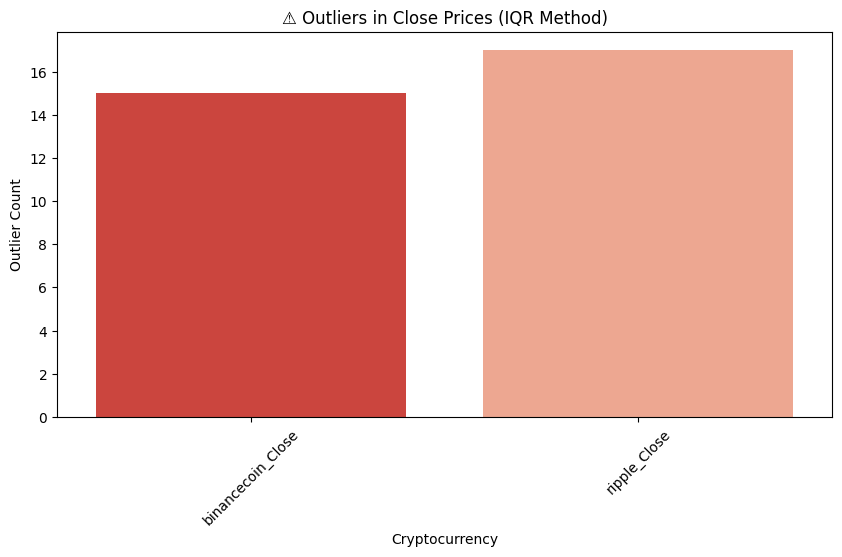

<ipython-input-5-28427855ae8c>:87: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




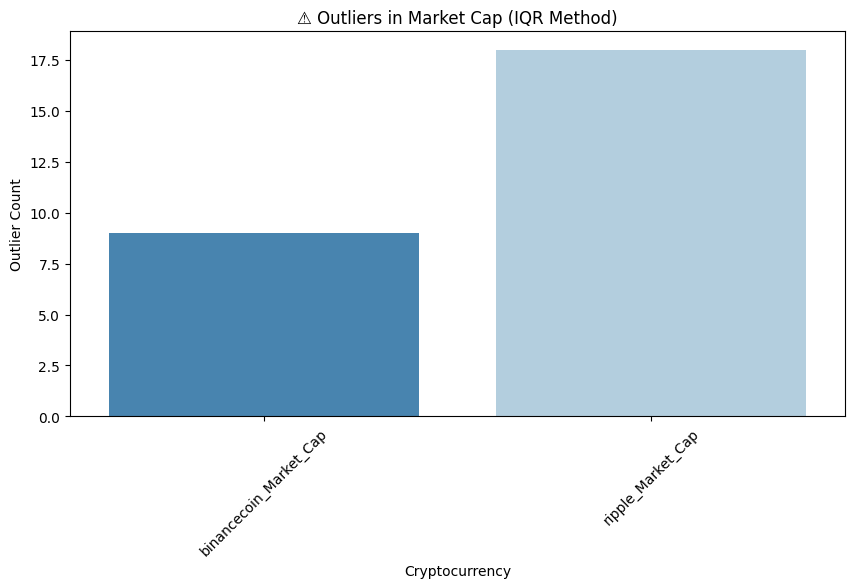

<ipython-input-5-28427855ae8c>:87: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




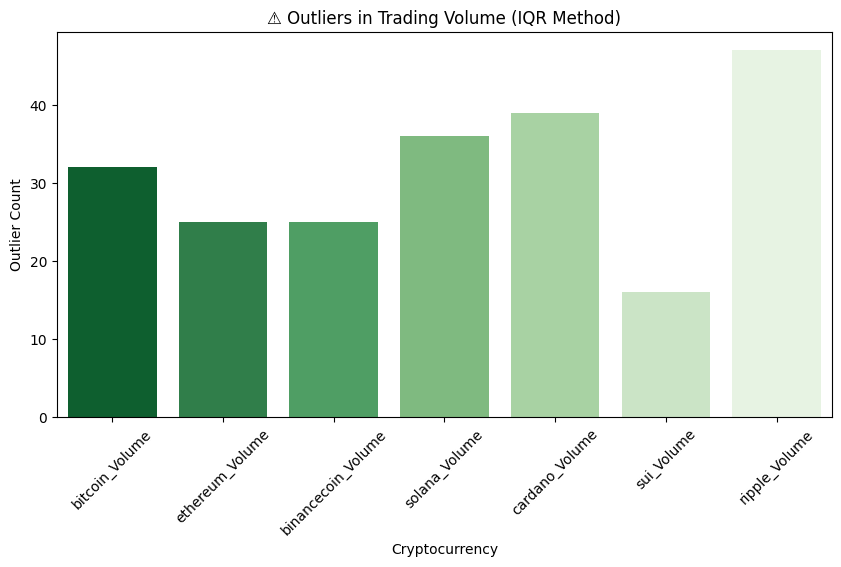

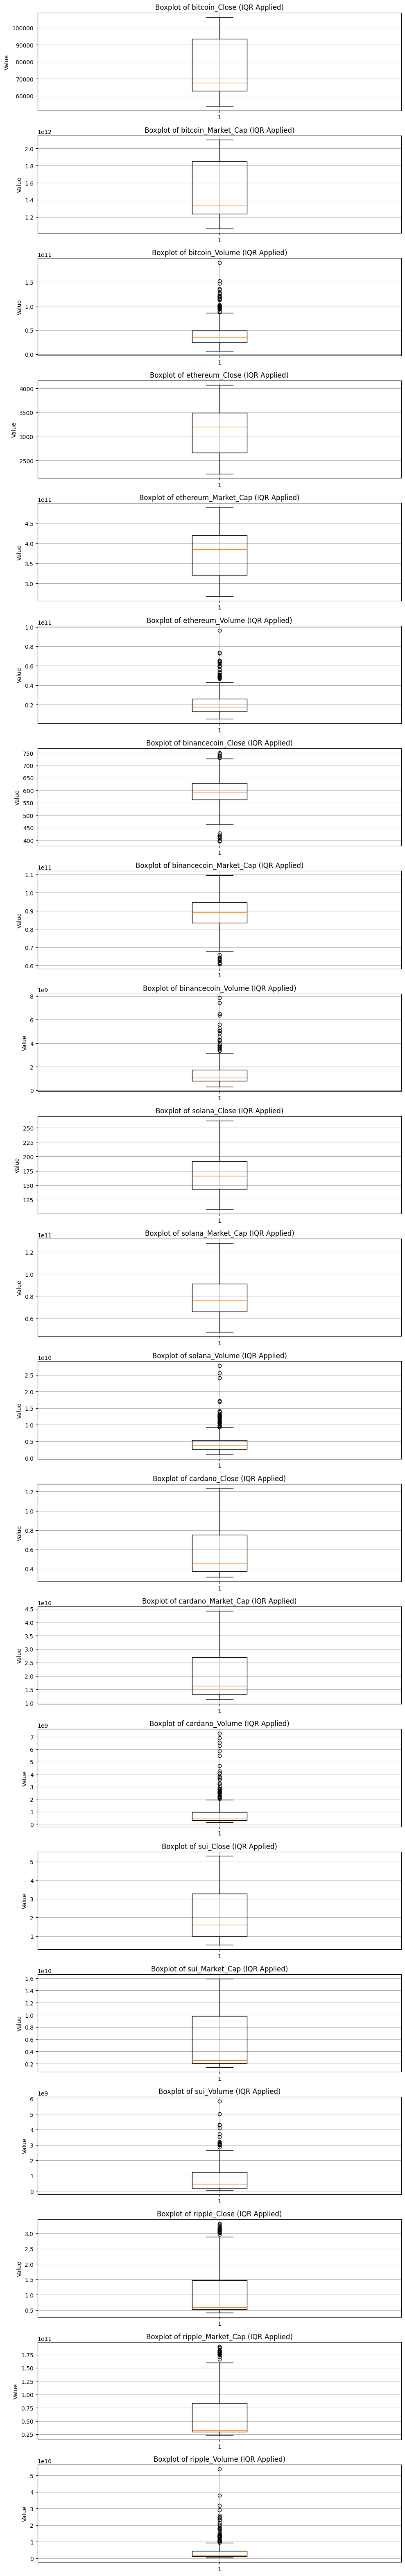

In [5]:
############################### 📊 GROUPED BOXPLOTS USING PLOTLY ###############################
# Grouped Plot 1: Close Prices
fig_close = go.Figure()
for col in final_df.columns:
    if 'Close' in col:
        fig_close.add_trace(go.Box(y=final_df[col].dropna(), name=col, boxmean=True, boxpoints='outliers'))
fig_close.update_layout(title="📊 Close Prices Boxplot", yaxis=dict(title="Price"), xaxis=dict(title="Cryptocurrency"))
fig_close.show()

# Grouped Plot 2: Market Caps
fig_marketcap = go.Figure()
for col in final_df.columns:
    if 'Market_Cap' in col:
        fig_marketcap.add_trace(go.Box(y=final_df[col].dropna(), name=col, boxmean=True, boxpoints='outliers'))
fig_marketcap.update_layout(title="📊 Market Cap Boxplot", yaxis=dict(title="Market Cap"), xaxis=dict(title="Cryptocurrency"))
fig_marketcap.show()

# Grouped Plot 3: Volume
fig_volume = go.Figure()
for col in final_df.columns:
    if 'Volume' in col:
        fig_volume.add_trace(go.Box(y=final_df[col].dropna(), name=col, boxmean=True, boxpoints='outliers'))
fig_volume.update_layout(title="📊 Trading Volume Boxplot", yaxis=dict(title="Volume"), xaxis=dict(title="Cryptocurrency"))
fig_volume.show()

############################### 🔎 OUTLIER DETECTION: IQR METHOD ###############################
outlier_rows = {}
outlier_counts = {}

for col in final_df.columns:
    if any(keyword in col for keyword in ['Close', 'Market_Cap', 'Volume']):
        data = final_df[col].dropna()

        # Compute IQR for outlier detection
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Find outliers
        outliers = data[(data < lower_bound) | (data > upper_bound)]

        if not outliers.empty:
            outlier_rows[col] = final_df.loc[outliers.index, [col]]
            outlier_counts[col] = len(outliers)

############################### 🔥 OUTLIER DETECTION: Z-SCORE METHOD ###############################
z_score_outliers = {}

for col in final_df.columns:
    if any(keyword in col for keyword in ['Close', 'Market_Cap', 'Volume']):
        z_scores = zscore(final_df[col].dropna())
        outliers = final_df[col][(z_scores > 3) | (z_scores < -3)]

        if not outliers.empty:
            z_score_outliers[col] = len(outliers)

############################### 📊 OUTLIER SUMMARY TABLE ###############################
fig_summary = go.Figure(data=[go.Table(
    header=dict(values=["Cryptocurrency", "Total Outliers (IQR)", "Total Outliers (Z-Score)"],
                fill_color='paleturquoise',
                align='left'),
    cells=dict(values=[
        list(outlier_counts.keys()),
        list(outlier_counts.values()),
        [z_score_outliers.get(col, 0) for col in outlier_counts.keys()]
    ],
               fill_color='lavender',
               align='left'))
])

fig_summary.update_layout(title_text="📊 Outlier Summary (IQR & Z-Score)")
fig_summary.show()

############################### 📈 SEPARATE HISTOGRAMS FOR OUTLIERS ###############################

# Grouping Outliers by Feature Type
outlier_close = {k: v for k, v in outlier_counts.items() if 'Close' in k}
outlier_marketcap = {k: v for k, v in outlier_counts.items() if 'Market_Cap' in k}
outlier_volume = {k: v for k, v in outlier_counts.items() if 'Volume' in k}

# Function to plot grouped histograms
def plot_outlier_histogram(outlier_dict, title, color_palette):
    if outlier_dict:
        plt.figure(figsize=(10, 5))
        sns.barplot(x=list(outlier_dict.keys()), y=list(outlier_dict.values()), palette=color_palette)
        plt.xticks(rotation=45)
        plt.title(f"⚠ {title}")
        plt.xlabel("Cryptocurrency")
        plt.ylabel("Outlier Count")
        plt.show()

# Plot separate histograms for each feature group
plot_outlier_histogram(outlier_close, "Outliers in Close Prices (IQR Method)", "Reds_r")
plot_outlier_histogram(outlier_marketcap, "Outliers in Market Cap (IQR Method)", "Blues_r")
plot_outlier_histogram(outlier_volume, "Outliers in Trading Volume (IQR Method)", "Greens_r")

############################### 🔥 INDIVIDUAL CRYPTOCURRENCY BOXPLOTS ###############################
fig, axes = plt.subplots(nrows=len(final_df.columns), ncols=1, figsize=(10, len(final_df.columns) * 3))

for i, col in enumerate(final_df.columns):
    if any(keyword in col for keyword in ['Close', 'Market_Cap', 'Volume']):
        data = final_df[col].dropna()

        # Compute IQR for outlier detection
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Find outliers
        outliers = data[(data < lower_bound) | (data > upper_bound)]

        if not outliers.empty:
            outlier_rows[col] = final_df.loc[outliers.index, [col]]

        # Plot individual boxplot for each cryptocurrency
        axes[i].boxplot(data, vert=True)
        axes[i].set_title(f"Boxplot of {col} (IQR Applied)")
        axes[i].set_ylabel("Value")
        axes[i].grid(True)

plt.tight_layout()
plt.show()


* Due to the colatile nature of cryptocurrency, no methods will applued for the extreem events as these are importnat in the modleing process and relevant for crypto.

### 1.2.3 Data Quality Checks


✅ **Running Data Quality Checks Before Splitting...**


⚠ **Rows with Negative or Zero Prices (Close, Market Cap, and Volume only):**



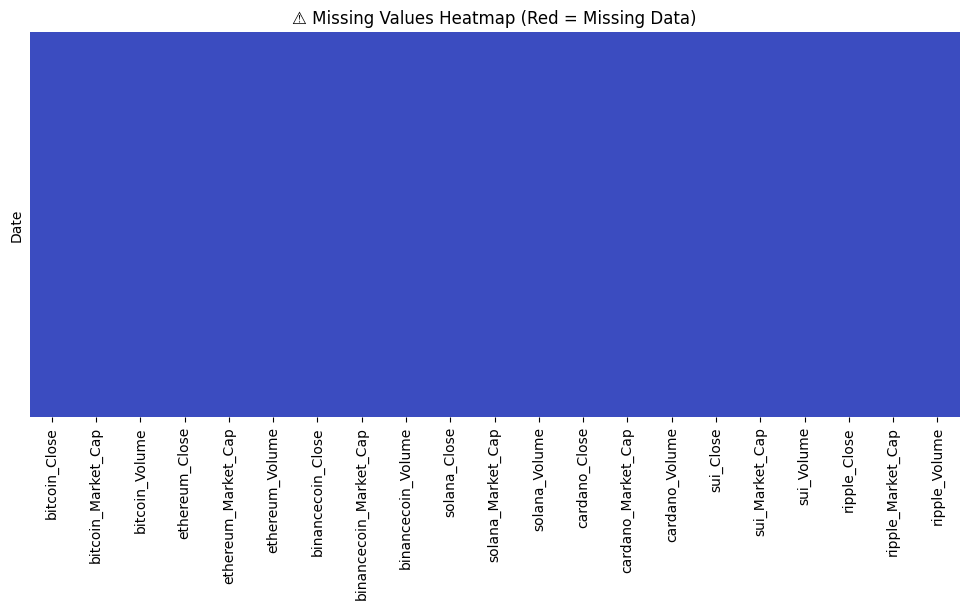


✅ **Data Quality Dashboard Complete! Ready for Feature Engineering.**



In [6]:
############################### ✅ DATA QUALITY CHECKS DASHBOARD ###############################
print("\n✅ **Running Data Quality Checks Before Splitting...**\n")

# 1️⃣ Check for duplicate rows
duplicate_rows = final_df.duplicated().sum()

# 2️⃣ Check for constant columns (cryptos that might have no variation)
constant_cols = [col for col in final_df.columns if final_df[col].nunique() == 1]

# 3️⃣ Check for **negative/zero prices** (Only for Close Prices, Market Cap, and Volume)
negative_zero_counts = {
    col: (final_df[col] <= 0).sum() for col in final_df.columns
    if any(keyword in col for keyword in ['Close', 'Market_Cap', 'Volume']) and (final_df[col] <= 0).sum() > 0
}

# 4️⃣ Ensure the dataset index is **strictly** increasing in time
date_sorted = final_df.index.is_monotonic_increasing

# 5️⃣ Check missing values after forward-filling
missing_after_fill = final_df.isnull().sum()
total_missing = missing_after_fill.sum()

# 6️⃣ Dataset size
num_rows, num_cols = final_df.shape

############################### 🔍 PRINT FULL ROWS WITH NEGATIVE OR ZERO PRICES ###############################
print("\n⚠ **Rows with Negative or Zero Prices (Close, Market Cap, and Volume only):**\n")
for col in negative_zero_counts.keys():
    print(f"🔴 {col} has {negative_zero_counts[col]} negative or zero values:")
    display(final_df[final_df[col] <= 0][[col]])

############################### 📊 DISPLAY DATA QUALITY SUMMARY ###############################
fig_data_quality = go.Figure(data=[go.Table(
    header=dict(values=["Metric", "Value"],
                fill_color='paleturquoise',
                align='left'),
    cells=dict(values=[
        ["Duplicate Rows", "Constant Value Columns", "Cryptos with Negative/Zero Prices",
         "Dates Sorted", "Total Missing Values", "Dataset Shape"],
        [duplicate_rows, len(constant_cols), len(negative_zero_counts),
         date_sorted, total_missing, f"{num_rows} rows, {num_cols} columns"]
    ],
    fill_color='lavender',
    align='left'))
])

fig_data_quality.update_layout(title_text="📊 Data Quality Summary")
fig_data_quality.show()

############################### 📈 VISUALIZATIONS FOR DATA QUALITY ISSUES ###############################

# 1️⃣ Visualizing Missing Values (Heatmap)
plt.figure(figsize=(12, 5))
sns.heatmap(final_df.isnull(), cmap="coolwarm", cbar=False, yticklabels=False)
plt.title("⚠ Missing Values Heatmap (Red = Missing Data)")
plt.show()

# 2️⃣ Visualizing **Negative/Zero Prices**
if negative_zero_counts:
    plt.figure(figsize=(10,5))
    sns.barplot(x=list(negative_zero_counts.keys()), y=list(negative_zero_counts.values()), palette="Reds_r")
    plt.xticks(rotation=45)
    plt.title("⚠ Cryptos with Negative/Zero Prices")
    plt.xlabel("Cryptocurrency")
    plt.ylabel("Count of Negative/Zero Values")
    plt.show()

print("\n✅ **Data Quality Dashboard Complete! Ready for Feature Engineering.**\n")


## 1.5 Split into Training & Test - move this straigt after Data Processing
🚀 Time-Based Splitting for Cryptocurrencies (Per Crypto)
Since cryptocurrencies start at different times, the splitting must be done per asset instead of using a fixed percentage across the entire dataset.

📌 Improvements in This Version
✅ Splitting happens per crypto – Each asset gets its own train, validation, and test splits.
✅ Ensures No Data Leakage – Each crypto is split chronologically based on its own history.
✅ Considers Missing Data – Handles cryptos that started later than others.
✅ Output Summary Dashboard – Displays split sizes per crypto in a table.


* CONSIDERATIONS: Very important is to integrate somethign that essentially splits the data into sets based on how much data is available. this si trick but needed because crypto cna be started at any pt in time.

In [7]:
############################### ✅ TIME-BASED DATA SPLITTING ###############################

# ✅ Define dictionaries to store the split datasets
train_data = {}
val_data = {}
test_data = {}

split_summary = {}

# ✅ Perform time-based split on the refined dataset (`df_selected`)
for col in final_df.columns:
    crypto_data = final_df[col].dropna()  # Ensure we're working with non-null data

    if len(crypto_data) < 10:  # Skip cryptos with insufficient data points
        print(f"⚠ Warning: Skipping {col} due to insufficient data points.")
        continue

    # Define split indices (50% train, 25% validation, 25% test)
    train_cutoff = int(len(crypto_data) * 0.5)
    val_cutoff = int(len(crypto_data) * 0.75)

    # Perform individual crypto splits
    train_data[col] = crypto_data.iloc[:train_cutoff]
    val_data[col] = crypto_data.iloc[train_cutoff:val_cutoff]
    test_data[col] = crypto_data.iloc[val_cutoff:]

    # Store split sizes for summary
    split_summary[col] = [len(train_data[col]), len(val_data[col]), len(test_data[col])]

Check the data sets

In [8]:


############################### 📊 DISPLAY SPLIT SUMMARY ###############################

# ✅ Convert split summary to DataFrame
split_df = pd.DataFrame.from_dict(split_summary, orient='index', columns=['Train Size', 'Validation Size', 'Test Size'])

# ✅ Create a summary table using Plotly
fig_summary = go.Figure(data=[go.Table(
    header=dict(values=["Cryptocurrency", "Train Size", "Validation Size", "Test Size"],
                fill_color='paleturquoise',
                align='left'),
    cells=dict(values=[split_df.index, split_df["Train Size"], split_df["Validation Size"], split_df["Test Size"]],
               fill_color='lavender',
               align='left'))
])

fig_summary.update_layout(title_text="📊 Time-Based Data Split Summary Per Cryptocurrency")
fig_summary.show()

print("\n✅ **Time-Based Data Splitting Completed!**")

############################### 📊 ELEMENTARY STATS FOR SELECTED FEATURES ###############################

# ✅ Initialize dictionary to store summary statistics
feature_summary = {}

for col in train_data.keys():  # Using train_data since it's the raw prices split
    feature_summary[col] = [
        train_data[col].mean(), train_data[col].std(),
        val_data[col].mean(), val_data[col].std(),
        test_data[col].mean(), test_data[col].std()
    ]

# ✅ Convert dictionary to DataFrame
feature_summary_df = pd.DataFrame.from_dict(
    feature_summary,
    orient='index',
    columns=['Train Mean', 'Train Std', 'Val Mean', 'Val Std', 'Test Mean', 'Test Std']
)

# ✅ Plot summary table for feature statistics
fig_feature_summary = go.Figure(data=[go.Table(
    header=dict(values=["Cryptocurrency", "Train Mean", "Train Std", "Validation Mean", "Validation Std", "Test Mean", "Test Std"],
                fill_color='paleturquoise',
                align='left'),
    cells=dict(values=[
        feature_summary_df.index,
        feature_summary_df["Train Mean"], feature_summary_df["Train Std"],
        feature_summary_df["Val Mean"], feature_summary_df["Val Std"],
        feature_summary_df["Test Mean"], feature_summary_df["Test Std"]
    ],
    fill_color='lavender',
    align='left'))
])

fig_feature_summary.update_layout(title_text="📊 Feature Statistics Summary Per Cryptocurrency")
fig_feature_summary.show()

print("\n✅ **Feature Statistics Summary Ready!**")



✅ **Time-Based Data Splitting Completed!**



✅ **Feature Statistics Summary Ready!**


## 1.3 Feature Engineering

🚀 What This Code Does
✅ Adds Log Returns to capture percentage price movements over time.
✅ Computes Volatility (7-day & 30-day) to assess risk.
✅ Adds Moving Averages to detect trends.
✅ Calculates Relative Volume Change for trading momentum insights.
✅ Derives Market Cap-to-Volume Ratio to assess liquidity.
✅ Ensures all features are aligned with time series modeling needs.

🔍 What Features are Most Relevant?
In portfolio optimization, we need features that impact returns, risk, and asset allocation. The most valuable features fall into the following categories:

✅ Essential Features for Portfolio Optimization
These are directly relevant for constructing a cryptocurrency portfolio:

Log Returns (Log_Return) – Key input for portfolio risk/return calculations.
Rolling Volatility (Volatility_7d, Volatility_30d) – Measures risk over different time frames.
Moving Averages (SMA_7d, SMA_30d) – Helps in detecting trends.
Market Cap-to-Volume Ratio (MarketCap_to_Volume) – Liquidity indicator.
Sharpe Ratio (Sharpe) – Measures return per unit of risk.
Sortino Ratio (Sortino) – Measures return per unit of downside risk.
Maximum Drawdown (MaxDrawdown) – Measures peak-to-trough declines.
Beta (Beta) – Measures correlation with the overall market.
❌ Remove or Reconsider These Features
These might be redundant or less useful for your specific goal:

Raw Closing Prices – Since log returns are being used, raw prices don't add value.
Market Cap & Volume (Raw Values) – Instead, we use derived features like market cap-to-volume ratio.
Highly Correlated Features – If 7-day & 30-day volatilities/moving averages are strongly correlated, remove one.


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.



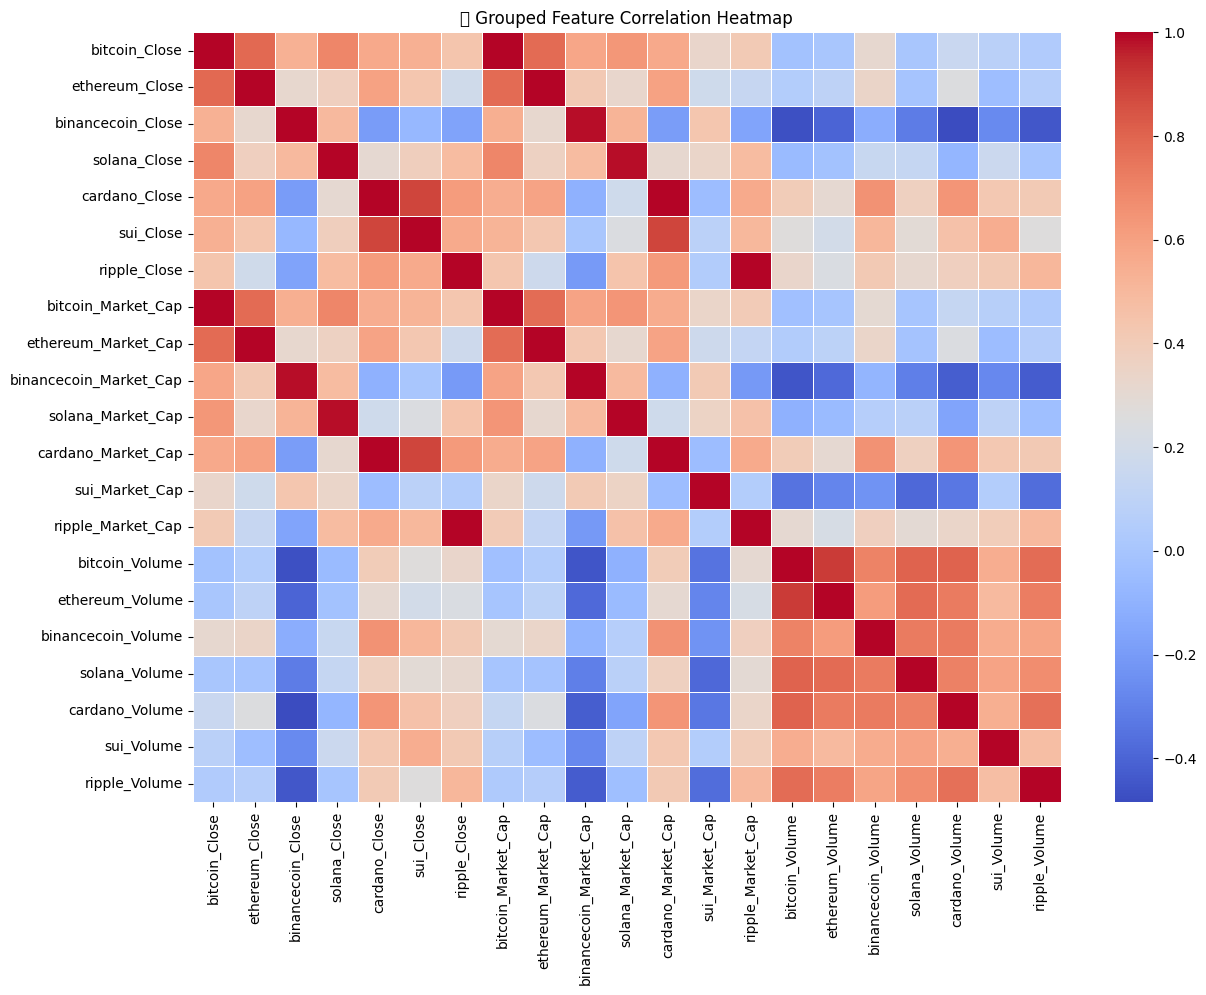


⚠ **Highly Correlated Feature Pairs (Correlation > 0.8):**



,level_0,level_1,correlation
7,bitcoin_Close,bitcoin_Market_Cap,0.999646
29,ethereum_Close,ethereum_Market_Cap,0.999144
51,binancecoin_Close,binancecoin_Market_Cap,0.983564
73,solana_Close,solana_Market_Cap,0.986406
89,cardano_Close,sui_Close,0.887246
95,cardano_Close,cardano_Market_Cap,0.999958
109,sui_Close,cardano_Close,0.887246
116,sui_Close,cardano_Market_Cap,0.886603
139,ripple_Close,ripple_Market_Cap,0.996850
147,bitcoin_Market_Cap,bitcoin_Close,0.999646


In [9]:


# ✅ Step 1: Convert train_data dictionary into a DataFrame
df_features = pd.DataFrame(train_data)  # Merging all crypto series into one DataFrame

# ✅ Step 2: Compute correlation matrix
corr_matrix = df_features.corr()

# ✅ Step 3: Extract group names from column names
def extract_group(feature_name):
    """Extracts the group name from the feature (assumes {crypto}_{group})"""
    return feature_name.split("_", 1)[-1]  # Takes everything after the first underscore

# ✅ Step 4: Create a mapping of features to their groups
feature_groups = {col: extract_group(col) for col in df_features.columns}

# ✅ Step 5: Sort features by group name
sorted_features = sorted(df_features.columns, key=lambda x: feature_groups[x])

# ✅ Step 6: Reorder correlation matrix
corr_matrix = corr_matrix.loc[sorted_features, sorted_features]

# ✅ Step 7: Plot heatmap with grouped features
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False, linewidths=0.5)
plt.title("📊 Grouped Feature Correlation Heatmap")
plt.xticks(ticks=np.arange(len(sorted_features)) + 0.5, labels=sorted_features, rotation=90)
plt.yticks(ticks=np.arange(len(sorted_features)) + 0.5, labels=sorted_features, rotation=0)
plt.show()

# ✅ Step 8: Identify highly correlated feature pairs (absolute correlation > 0.8)
high_corr_pairs = (
    corr_matrix.abs()
    .stack()
    .reset_index()
    .rename(columns={0: "correlation"})
    .query("correlation > 0.8 and level_0 != level_1")
)

print("\n⚠ **Highly Correlated Feature Pairs (Correlation > 0.8):**\n")
display(high_corr_pairs)


📌 Summary of Correlation Analysis
High correlation between Close prices and Market Cap for all cryptocurrencies, indicating redundancy in these features.
Significant cross-cryptocurrency correlations between Cardano and Sui, suggesting linked price movements.
Strong correlations among trading volumes of Bitcoin, Ethereum, Solana, and Cardano, meaning they may share liquidity trends.
Potential Features for Removal: Market Cap (due to redundancy with Close prices), and potentially some volume features to avoid multicollinearity.

Below is an HTML-styled breakdown of the code, with each step explained along with the formulas used:

---

<h2>1. Importing Libraries</h2>
<p>
  The code begins by importing <code>pandas</code> (for data manipulation) and <code>numpy</code> (for numerical operations):
</p>
<pre><code>import pandas as pd
import numpy as np
</code></pre>

---

<h2>2. Creating the DataFrame</h2>
<p>
  The <code>train_data</code> dictionary, which contains multiple cryptocurrency time series, is converted into a single DataFrame:
</p>
<pre><code>df_features = pd.DataFrame(train_data)
</code></pre>
<p>
  This merges all crypto series into one structured table.
</p>

---

<h2>3. Setting and Sorting the DateTime Index</h2>
<p>
  The DataFrame’s index is converted to a DateTime format and sorted in chronological order:
</p>
<pre><code>df_features.index = pd.to_datetime(df_features.index, errors='coerce')
df_features = df_features.sort_index()
</code></pre>

---

<h2>4. Feature Engineering Loop</h2>
<p>
  The code iterates over each column in the DataFrame and creates new features based on the type of data (prices, volume, or market cap).
</p>

<h3>a. Processing Price Columns (Columns containing "Close")</h3>
<p>
  For each price column, the cryptocurrency name is extracted by removing the "_Close" suffix.
</p>
<ul>
  <li>
    <strong>Log Return:</strong>
    <br>
    <em>Formula:</em>
    \( \text{LogReturn}_t = \ln\left(\frac{P_t}{P_{t-1}}\right) \)
    <br>
    <code>df_features[f'{crypto_name}_Log_Return'] = np.log(df_features[col] / df_features[col].shift(1))</code>
  </li>
  <li>
    <strong>Rolling Volatility:</strong>
    <br>
    Computed as the standard deviation of the log returns over a rolling window.
    <ul>
      <li>
        <em>7-day Volatility:</em>
        \( \sigma_{7d} = \text{std}\left(\{\text{LogReturn}_{t-6}, \dots, \text{LogReturn}_{t}\}\right) \)
        <br>
        <code>df_features[f'{crypto_name}_Volatility_7d'] = df_features[f'{crypto_name}_Log_Return'].rolling(window=7).std()</code>
      </li>
      <li>
        <em>30-day Volatility:</em>
        \( \sigma_{30d} = \text{std}\left(\{\text{LogReturn}_{t-29}, \dots, \text{LogReturn}_{t}\}\right) \)
        <br>
        <code>df_features[f'{crypto_name}_Volatility_30d'] = df_features[f'{crypto_name}_Log_Return'].rolling(window=30).std()</code>
      </li>
    </ul>
  </li>
  <li>
    <strong>Moving Averages:</strong>
    <br>
    Simple moving averages over rolling windows.
    <ul>
      <li>
        <em>7-day SMA:</em>
        \( \text{SMA}_{7d} = \frac{1}{7}\sum_{i=0}^{6} P_{t-i} \)
        <br>
        <code>df_features[f'{crypto_name}_SMA_7d'] = df_features[col].rolling(window=7).mean()</code>
      </li>
      <li>
        <em>30-day SMA:</em>
        \( \text{SMA}_{30d} = \frac{1}{30}\sum_{i=0}^{29} P_{t-i} \)
        <br>
        <code>df_features[f'{crypto_name}_SMA_30d'] = df_features[col].rolling(window=30).mean()</code>
      </li>
    </ul>
  </li>
</ul>

<h3>b. Processing Volume Columns (Columns containing "Volume")</h3>
<p>
  For volume data, the cryptocurrency name is extracted by removing the "_Volume" suffix.
</p>
<ul>
  <li>
    <strong>Relative Volume Change:</strong>
    <br>
    The percentage change in volume from one period to the next.
    <br>
    <em>Formula:</em>
    \( \text{Volume Change}_t = \frac{V_t - V_{t-1}}{V_{t-1}} \)
    <br>
    <code>df_features[f'{crypto_name}_Volume_Change'] = df_features[col].pct_change()</code>
  </li>
</ul>

<h3>c. Processing Market Capitalization Columns (Columns containing "Market_Cap")</h3>
<p>
  The cryptocurrency name is derived by removing the "_Market_Cap" suffix.
</p>
<ul>
  <li>
    <strong>Market Cap-to-Volume Ratio:</strong>
    <br>
    This ratio compares the market capitalization to the trading volume.
    <br>
    <em>Formula:</em>
    \( \text{MarketCap-to-Volume} = \frac{\text{Market Cap}}{\text{Volume}} \)
    <br>
    <code>df_features[f'{crypto_name}_MarketCap_to_Volume'] = df_features[col] / df_features[f'{crypto_name}_Volume']</code>
  </li>
</ul>

---

<h2>5. Data Cleaning</h2>
<p>
  After generating the new features, any rows with NaN values (resulting from the shifting and rolling calculations) are removed:
</p>
<pre><code>df_features.dropna(inplace=True)
</code></pre>

---

<h2>6. Displaying the Results</h2>
<p>
  Finally, the code prints a summary of the newly engineered features using <code>describe()</code> and displays the shape of the final DataFrame:
</p>
<pre><code>print("\n✅ **Feature Engineering Complete! Summary of New Features:**\n")
display(df_features.describe())

print("\n✅ **Final DataFrame Shape:**", df_features.shape)
</code></pre>

---

<h2>Summary of Formulas</h2>
<ul>
  <li>
    <strong>Log Returns:</strong>
    \( \ln\left(\frac{P_t}{P_{t-1}}\right) \)
  </li>
  <li>
    <strong>Rolling Volatility:</strong>
    \( \text{std}(\text{Log Returns over window}) \) for 7-day and 30-day windows.
  </li>
  <li>
    <strong>Simple Moving Average (SMA):</strong>
    \( \frac{1}{n}\sum_{i=0}^{n-1} P_{t-i} \) (with \(n = 7\) or \(30\))
  </li>
  <li>
    <strong>Relative Volume Change:</strong>
    \( \frac{V_t - V_{t-1}}{V_{t-1}} \)
  </li>
  <li>
    <strong>Market Cap-to-Volume Ratio:</strong>
    \( \frac{\text{Market Cap}}{\text{Volume}} \)
  </li>
</ul>

---

This HTML-styled breakdown can be directly included in a Google Colab notebook to help explain each step of the code along with the corresponding formulas.

In [10]:
import pandas as pd
import numpy as np

############################### 📊 FEATURE ENGINEERING ###############################

# ✅ Convert `train_data` dictionary into a DataFrame
df_features = pd.DataFrame(train_data)  # Merge all crypto series into one DataFrame

# ✅ Ensure Index is in Proper DateTime Format
df_features.index = pd.to_datetime(df_features.index, errors='coerce')  # Fix dates
df_features = df_features.sort_index()  # Ensure chronological order

# ✅ Initialize Feature Dictionary
new_features = {}

# ✅ Iterate over columns and generate only **relevant** features for portfolio optimization
for col in df_features.columns:
    if '_Close' in col:
        crypto_name = col.replace('_Close', '')

        # 1️⃣ **Log Returns** (Essential for optimization)
        new_features[f'{crypto_name}_Log_Return'] = np.log(df_features[col] / df_features[col].shift(1))

        # 2️⃣ **Rolling Volatility (30-day)** (Portfolio risk measure)
        new_features[f'{crypto_name}_Volatility_30d'] = new_features[f'{crypto_name}_Log_Return'].rolling(window=30).std()

# ✅ Convert New Features to DataFrame
df_new_features = pd.DataFrame(new_features)

# ✅ Identify Log Return Features (For drawdown calculation)
log_return_features = [col for col in df_new_features.columns if '_Log_Return' in col]

if log_return_features:
    print("\n📉 Computing Drawdowns for Log Returns...")
    # **Drawdown Calculation for Log Returns** (Portfolio risk characteristic)
    def calculate_drawdowns(series):
        """ Optimized drawdown calculation for Log Returns only """
        series = series.replace([np.inf, -np.inf], np.nan).fillna(0)  # Handle NaN & Inf
        cumulative_returns = np.exp(series.cumsum().clip(-50, 50))  # Prevents overflow
        peak = cumulative_returns.cummax()
        drawdown = (cumulative_returns - peak) / peak
        return drawdown

    # Apply Drawdown Calculation
    drawdown_features = df_new_features[log_return_features].apply(calculate_drawdowns).add_suffix("_Drawdown")

    # ✅ Append Drawdown Features to Feature Set
    df_new_features = pd.concat([df_new_features, drawdown_features], axis=1)

# ✅ Combine All Features into One DataFrame
df_features = pd.concat([df_features, df_new_features], axis=1)

# ✅ Drop NaN values that result from shifting operations
df_features.dropna(inplace=True)

############################### ✅ DISPLAY SUMMARY ###############################

print("\n✅ **Feature Engineering Complete! Summary of New Features:**\n")
display(df_features.describe())

# ✅ Check Final DataFrame Shape
print("\n✅ **Final DataFrame Shape:**", df_features.shape)



📉 Computing Drawdowns for Log Returns...

✅ **Feature Engineering Complete! Summary of New Features:**



,bitcoin_Close,bitcoin_Market_Cap,bitcoin_Volume,ethereum_Close,ethereum_Market_Cap,ethereum_Volume,binancecoin_Close,binancecoin_Market_Cap,binancecoin_Volume,solana_Close,...,sui_Volatility_30d,ripple_Log_Return,ripple_Volatility_30d,bitcoin_Log_Return_Drawdown,ethereum_Log_Return_Drawdown,binancecoin_Log_Return_Drawdown,solana_Log_Return_Drawdown,cardano_Log_Return_Drawdown,sui_Log_Return_Drawdown,ripple_Log_Return_Drawdown
count,153.000000,1.530000e+02,1.530000e+02,153.000000,1.530000e+02,1.530000e+02,153.000000,1.530000e+02,1.530000e+02,153.000000,...,153.000000,153.000000,153.000000,153.000000,153.000000,153.000000,153.000000,153.000000,153.000000,153.000000
mean,64237.772561,1.266143e+12,2.878658e+10,3231.644173,3.890185e+11,1.532710e+10,576.566209,8.787088e+10,1.200651e+09,155.333152,...,0.054216,-0.000502,0.034763,-0.121207,-0.206102,-0.139956,-0.234084,-0.436633,-0.509714,-0.252915
std,4103.342454,8.014576e+10,1.286613e+10,368.122668,4.429368e+10,7.806543e+09,39.695202,7.028700e+09,6.587528e+08,17.012564,...,0.014666,0.035201,0.012455,0.056135,0.090434,0.087182,0.083941,0.094133,0.141339,0.072166
min,53956.261842,1.064889e+12,6.340607e+09,2341.590346,2.820983e+11,5.237992e+09,464.917223,6.782565e+10,3.746913e+08,127.039083,...,0.034165,-0.131528,0.017321,-0.261862,-0.424756,-0.345227,-0.373619,-0.594715,-0.743210,-0.415411
25%,60912.588533,1.201819e+12,1.968531e+10,3015.159770,3.628363e+11,1.078619e+10,560.705341,8.411631e+10,7.736571e+08,142.131717,...,0.040854,-0.013895,0.020746,-0.166697,-0.259284,-0.195925,-0.299203,-0.503607,-0.603439,-0.304722
50%,64279.518129,1.269291e+12,2.812741e+10,3254.611673,3.927751e+11,1.416462e+10,581.352835,8.930827e+10,9.937484e+08,150.655603,...,0.051362,-0.000968,0.038555,-0.120636,-0.200460,-0.145785,-0.257175,-0.435000,-0.524892,-0.266520
75%,67607.713399,1.333202e+12,3.602781e+10,3507.660656,4.213920e+11,1.799954e+10,597.883609,9.194754e+10,1.545554e+09,169.216311,...,0.061737,0.011837,0.045812,-0.075106,-0.138295,-0.058751,-0.165659,-0.404267,-0.467974,-0.183826
max,71624.184862,1.410325e+12,1.202460e+11,3893.392106,4.676140e+11,7.357103e+10,710.043483,1.091364e+11,3.926924e+09,202.814325,...,0.091828,0.181013,0.056651,-0.020159,-0.043535,0.000000,0.000000,-0.142884,-0.032267,-0.120584



✅ **Final DataFrame Shape:** (153, 42)


## 1.4 Feature Selection

## 1.4.2. Feature Importance (Random Forests)

<ipython-input-11-35dfc546bb79>:32: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




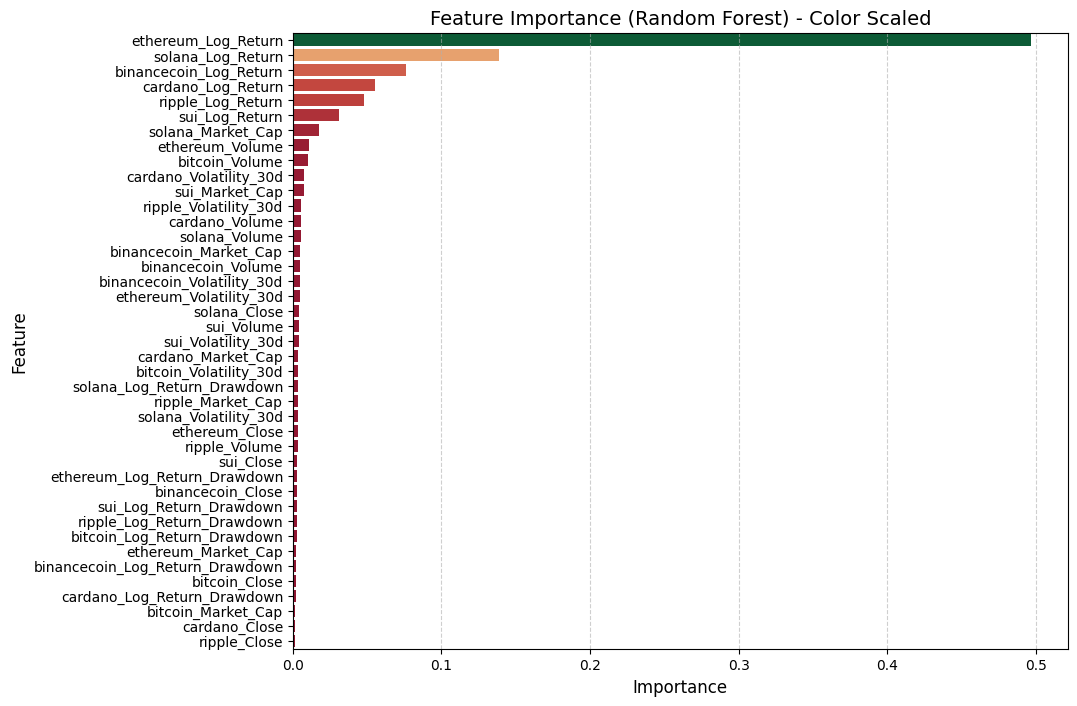

Selected Features:
Index(['bitcoin_Volume', 'ethereum_Market_Cap', 'ethereum_Volume',
       'solana_Market_Cap', 'ethereum_Log_Return', 'binancecoin_Log_Return',
       'solana_Log_Return', 'cardano_Log_Return', 'sui_Log_Return',
       'ripple_Log_Return'],
      dtype='object')

📊 Feature Ranking:


,Feature,Ranking
22,ethereum_Log_Return,1
28,cardano_Log_Return,1
10,solana_Market_Cap,1
24,binancecoin_Log_Return,1
5,ethereum_Volume,1
32,ripple_Log_Return,1
26,solana_Log_Return,1
2,bitcoin_Volume,1
30,sui_Log_Return,1
4,ethereum_Market_Cap,1


In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import seaborn as sns
import matplotlib.pyplot as plt

# ✅ Define Features & Target
X = df_features.drop(columns=["bitcoin_Log_Return"])  # Drop target variable
y = df_features["bitcoin_Log_Return"]  # Predicting Bitcoin's log return

# ✅ Split Data into Train & Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ✅ Train Random Forest Model
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# ✅ Get Feature Importance Scores
feature_importances = model.feature_importances_
features = X.columns
importance_df = pd.DataFrame({"Feature": features, "Importance": feature_importances}).sort_values(by="Importance", ascending=False)

# ✅ Normalize feature importance for color mapping
importance_df["Normalized"] = (importance_df["Importance"] - importance_df["Importance"].min()) / (importance_df["Importance"].max() - importance_df["Importance"].min())

# ✅ Define color mapping: Red (low importance) → Green (high importance)
cmap = sns.color_palette("RdYlGn", as_cmap=True)

# ✅ Plot Feature Importance with color scaling
plt.figure(figsize=(10, 8))
sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature",
    palette=[cmap(val) for val in importance_df["Normalized"]]
)

plt.title("Feature Importance (Random Forest) - Color Scaled", fontsize=14)
plt.xlabel("Importance", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.6)

plt.show()

# ✅ Recursive Feature Elimination (RFE)
from sklearn.feature_selection import RFE

# ✅ Initialize Model
estimator = RandomForestRegressor(random_state=42)

# ✅ Apply Recursive Feature Elimination (RFE)
selector = RFE(estimator, n_features_to_select=10, step=1)  # Keep only top 10 features
selector.fit(X_train, y_train)

# ✅ Identify Selected Features
selected_features = X_train.columns[selector.support_]
print(f"Selected Features:\n{selected_features}")

# ✅ Check Ranking of All Features
ranking_df = pd.DataFrame({"Feature": X_train.columns, "Ranking": selector.ranking_}).sort_values(by="Ranking")
print("\n📊 Feature Ranking:")
display(ranking_df)


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.



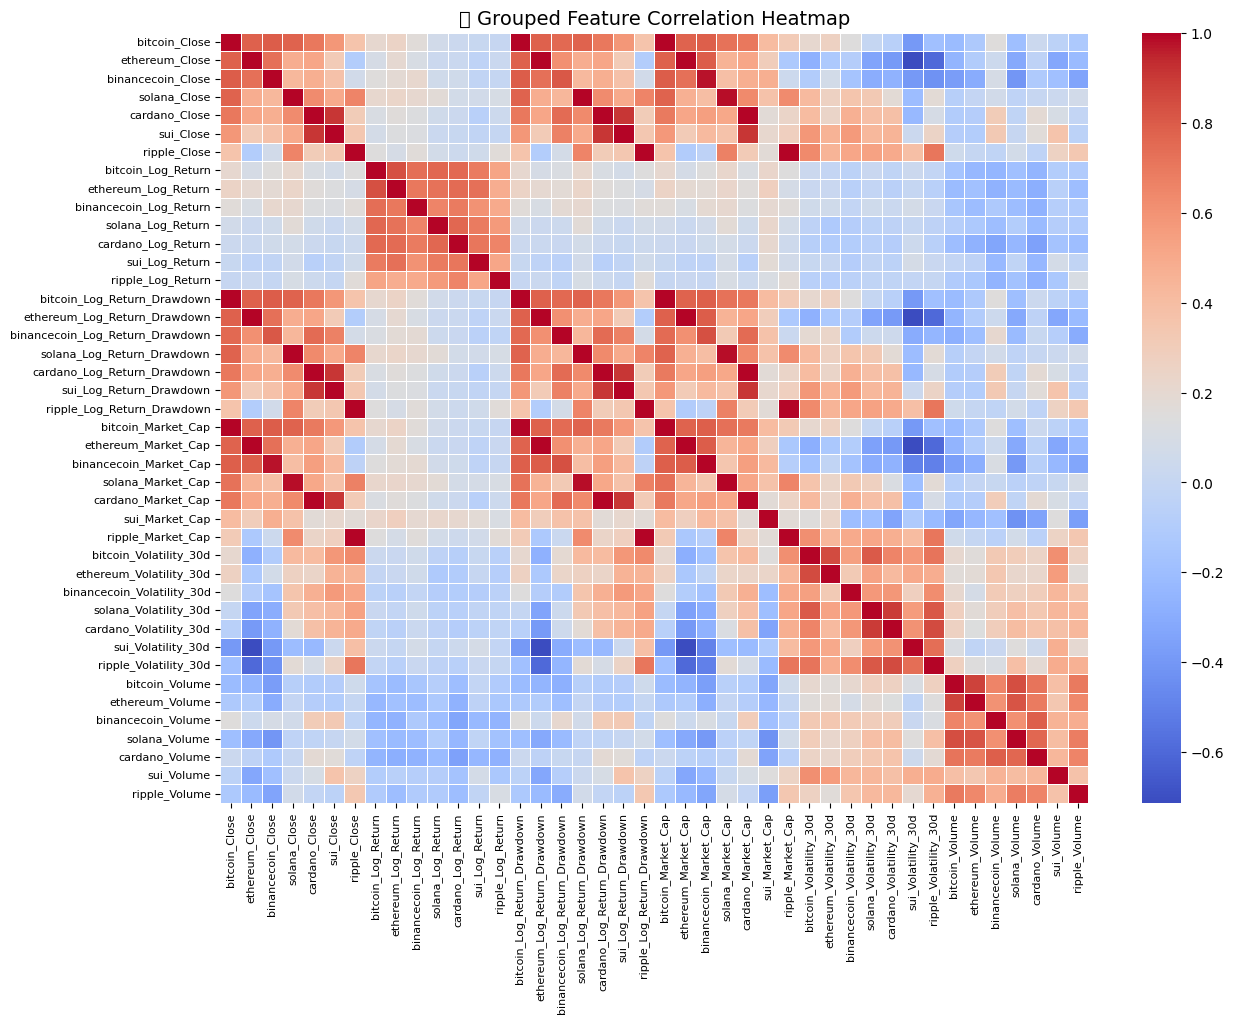


⚠ **Highly Correlated Feature Pairs (Correlation > 0.8):**



,level_0,level_1,correlation
14,bitcoin_Close,bitcoin_Log_Return_Drawdown,1.000000
21,bitcoin_Close,bitcoin_Market_Cap,0.999828
57,ethereum_Close,ethereum_Log_Return_Drawdown,1.000000
64,ethereum_Close,ethereum_Market_Cap,0.998992
100,binancecoin_Close,binancecoin_Log_Return_Drawdown,0.808049
...,...,...,...
1508,bitcoin_Volume,solana_Volume,0.843464
1547,ethereum_Volume,bitcoin_Volume,0.876418
1550,ethereum_Volume,solana_Volume,0.824647
1631,solana_Volume,bitcoin_Volume,0.843464


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

############################### 📊 FEATURE SELECTION ###############################

# ✅ Step 1: Compute correlation matrix
corr_matrix = df_features.corr()

# ✅ Step 2: Extract group names from column names
def extract_group(feature_name):
    """Extracts the group name from the feature (assumes {crypto}_{group})"""
    return feature_name.split("_", 1)[-1]  # Takes everything after the first underscore

# ✅ Step 3: Create a mapping of features to their groups
feature_groups = {col: extract_group(col) for col in df_features.columns}

# ✅ Step 4: Sort features by group name
sorted_features = sorted(df_features.columns, key=lambda x: feature_groups[x])

# ✅ Step 5: Reorder correlation matrix
corr_matrix = corr_matrix.loc[sorted_features, sorted_features]

# ✅ Step 6: Plot heatmap with **smaller labels**
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=False,
    linewidths=0.5
)

plt.title("📊 Grouped Feature Correlation Heatmap", fontsize=14)

# ✅ Reduce label size for better readability
plt.xticks(
    ticks=np.arange(len(sorted_features)) + 0.5,
    labels=sorted_features,
    rotation=90,
    fontsize=8  # Adjust font size (smaller)
)

plt.yticks(
    ticks=np.arange(len(sorted_features)) + 0.5,
    labels=sorted_features,
    rotation=0,
    fontsize=8  # Adjust font size (smaller)
)

plt.show()

# ✅ Step 7: Identify highly correlated feature pairs (absolute correlation > 0.8)
high_corr_pairs = (
    corr_matrix.abs()
    .stack()
    .reset_index()
    .rename(columns={0: "correlation"})
    .query("correlation > 0.8 and level_0 != level_1")
)

print("\n⚠ **Highly Correlated Feature Pairs (Correlation > 0.8):**\n")
display(high_corr_pairs)


Based on the correlation results:

Market Cap is highly correlated with Close price (≈0.999+ for all cryptos).
→ Drop Market Cap and keep Close price instead.
Moving Averages (SMA 7d & SMA 30d) are highly correlated with Close (0.85+).
→ Keep one SMA (e.g., SMA 30d) and drop the other.
Cryptos with cross-asset correlations (Cardano & Sui, Bitcoin & Ethereum Log Returns).
→ These may still provide unique insights but should be monitored for redundancy.
Volume-related features have strong correlations (Bitcoin & Ethereum Volume, 0.87+).
→ Drop MarketCap-to-Volume Ratio if it's redundant.


In [13]:
############################### ✅ FEATURE SELECTION (Optimized for Portfolio Optimization) ###############################

# ✅ Step 1: Define Feature Removal Flags
remove_sma = True  # Remove all SMA features (_SMA_7d and _SMA_30d)
remove_market_cap = True  # Remove all _Market_Cap features
remove_marketcap_to_volume = True  # Remove all _MarketCap_to_Volume features
remove_volume = True  # Remove all _Volume features (including _Volume_Change)
remove_macd = True  # Remove all _MACD features
remove_rsi = True  # Remove all _RSI features
remove_log_return_drawdown = True  # Remove all _Log_Return_Drawdown features

# ✅ Step 2: Identify Columns to Remove
features_to_drop = []

for col in df_features.columns:
    if remove_sma and ("_SMA_7d" in col or "_SMA_30d" in col):
        features_to_drop.append(col)
    if remove_market_cap and "_Market_Cap" in col:
        features_to_drop.append(col)
    if remove_marketcap_to_volume and "_MarketCap_to_Volume" in col:
        features_to_drop.append(col)
    if remove_volume and ("_Volume" in col or "_Volume_Change" in col):
        features_to_drop.append(col)
    if remove_macd and "_MACD" in col:
        features_to_drop.append(col)
    if remove_rsi and "_RSI" in col:
        features_to_drop.append(col)
    if remove_log_return_drawdown and "_Log_Return_Drawdown" in col:
        features_to_drop.append(col)

# ✅ Step 3: Drop Selected Features
df_selected = df_features.drop(columns=features_to_drop, errors='ignore')

# ✅ Step 4: Confirm Shape After Feature Selection
print("\n✅ **Feature Selection Completed! Final Data Shape:**", df_selected.shape)
print(f"📌 Removed {len(features_to_drop)} Features")
display(df_selected.head())



✅ **Feature Selection Completed! Final Data Shape:** (153, 21)
📌 Removed 21 Features


,bitcoin_Close,ethereum_Close,binancecoin_Close,solana_Close,cardano_Close,sui_Close,ripple_Close,bitcoin_Log_Return,bitcoin_Volatility_30d,ethereum_Log_Return,...,binancecoin_Log_Return,binancecoin_Volatility_30d,solana_Log_Return,solana_Volatility_30d,cardano_Log_Return,cardano_Volatility_30d,sui_Log_Return,sui_Volatility_30d,ripple_Log_Return,ripple_Volatility_30d
Date,,,,,,,,,,,,,,,,,,,,,
2024-03-29,70710.195349,3560.261511,583.290744,189.574991,0.650176,2.023450,0.624081,0.018188,0.041719,0.015581,...,0.013363,0.051993,0.018291,0.056426,0.003110,0.051848,-0.032800,0.049704,0.019055,0.051909
2024-03-30,69919.055461,3516.096058,616.582921,192.027266,0.664244,1.909310,0.630585,-0.011252,0.038546,-0.012483,...,0.055507,0.052081,0.012853,0.055146,0.021406,0.051946,-0.058062,0.051047,0.010368,0.051781
2024-03-31,69702.308747,3507.660656,601.206506,194.481044,0.644487,1.881979,0.621010,-0.003105,0.038303,-0.002402,...,-0.025254,0.051617,0.012697,0.054282,-0.030195,0.051771,-0.014418,0.050383,-0.015300,0.051799
2024-04-01,71246.951441,3644.767599,606.625982,202.814325,0.650450,1.914500,0.628963,0.021919,0.038355,0.038343,...,0.008974,0.051615,0.041956,0.054398,0.009210,0.049212,0.017133,0.050441,0.012724,0.051672
2024-04-02,69785.925038,3508.247720,577.957354,192.725250,0.622240,1.941136,0.612153,-0.020720,0.038588,-0.038176,...,-0.048412,0.052828,-0.051025,0.055649,-0.044338,0.049170,0.013817,0.049720,-0.027090,0.050379


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.



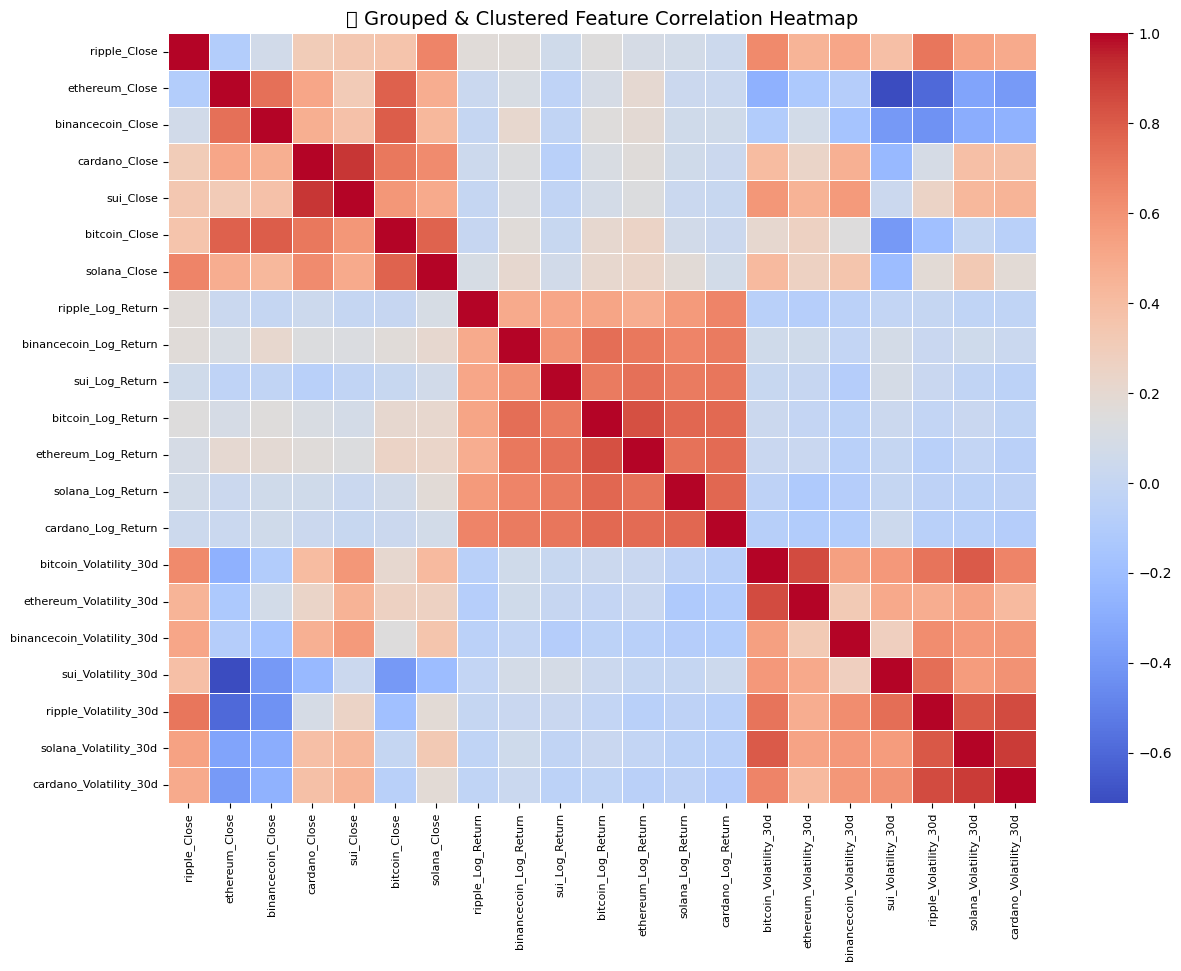


⚠ **Highly Correlated Feature Pairs (Correlation > 0.8):**



,level_0,level_1,correlation
67,cardano_Close,sui_Close,0.909733
87,sui_Close,cardano_Close,0.909733
221,bitcoin_Log_Return,ethereum_Log_Return,0.833210
241,ethereum_Log_Return,bitcoin_Log_Return,0.833210
309,bitcoin_Volatility_30d,ethereum_Volatility_30d,0.848234
329,ethereum_Volatility_30d,bitcoin_Volatility_30d,0.848234
397,ripple_Volatility_30d,solana_Volatility_30d,0.808359
398,ripple_Volatility_30d,cardano_Volatility_30d,0.850382
417,solana_Volatility_30d,ripple_Volatility_30d,0.808359
419,solana_Volatility_30d,cardano_Volatility_30d,0.897628


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.cluster.hierarchy import linkage, leaves_list

############################### 📊 Dynamic Feature Grouping ###############################

# ✅ Step 1: Compute correlation matrix
corr_matrix = df_selected.corr()

# ✅ Step 2: Extract group names from column names
def extract_group(feature_name):
    """Extracts the group name from the feature (assumes {crypto}_{group})"""
    return feature_name.split("_", 1)[-1]  # Takes everything after the first underscore

# ✅ Step 3: Create a mapping of features to their groups
feature_groups = {col: extract_group(col) for col in df_selected.columns}

# ✅ Step 4: Sort features by group name
sorted_features = sorted(df_selected.columns, key=lambda x: feature_groups[x])

# ✅ Step 5: Apply Hierarchical Clustering Within Each Group
final_sorted_features = []
unique_groups = sorted(set(feature_groups.values()))  # Unique sorted group names

for group in unique_groups:
    group_features = [f for f in sorted_features if feature_groups[f] == group]

    if len(group_features) > 1:  # Only apply clustering if multiple features exist
        sub_corr_matrix = df_selected[group_features].corr()

        if not sub_corr_matrix.isnull().values.all():  # Ensure clustering is possible
            linked = linkage(sub_corr_matrix.fillna(0), method='ward')
            ordered_indices = leaves_list(linked)
            ordered_group_features = [group_features[i] for i in ordered_indices]
        else:
            ordered_group_features = group_features  # No clustering needed

        final_sorted_features.extend(ordered_group_features)
    else:
        final_sorted_features.extend(group_features)

# ✅ Step 6: Reorder correlation matrix with new feature ordering
corr_matrix = corr_matrix.loc[final_sorted_features, final_sorted_features]

# ✅ Step 7: Plot heatmap with **smaller labels**
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=False,
    linewidths=0.5
)

plt.title("📊 Grouped & Clustered Feature Correlation Heatmap", fontsize=14)

# ✅ Reduce label size for better readability
plt.xticks(
    ticks=np.arange(len(final_sorted_features)) + 0.5,
    labels=final_sorted_features,
    rotation=90,
    fontsize=8  # Adjust font size (smaller)
)

plt.yticks(
    ticks=np.arange(len(final_sorted_features)) + 0.5,
    labels=final_sorted_features,
    rotation=0,
    fontsize=8  # Adjust font size (smaller)
)

plt.show()

############################### ⚠ Identifying Highly Correlated Features ###############################

# ✅ Step 8: Identify highly correlated feature pairs (absolute correlation > 0.8)
high_corr_pairs = (
    corr_matrix.abs()
    .stack()
    .reset_index()
    .rename(columns={0: "correlation"})
    .query("correlation > 0.8 and level_0 != level_1")
)

print("\n⚠ **Highly Correlated Feature Pairs (Correlation > 0.8):**\n")
display(high_corr_pairs)


## 1.6 Data Analysis


### 1.6.1 Statistical Summary

<table>
  <thead>
    <tr>
      <th>Dataset</th>
      <th>When to Use It?</th>
      <th>Purpose</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td><code>train_data</code> (Raw Prices)</td>
      <td>Market analysis, price trends, volatility trends</td>
      <td>Understand the scale and behavior of asset prices</td>
    </tr>
    <tr>
      <td><code>train_data_log</code> (Log Returns)</td>
      <td>Risk analysis, correlations, clustering, modeling</td>
      <td>Used in ML models because returns are more meaningful for finance</td>
    </tr>
  </tbody>
</table>


In [15]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from scipy.stats import median_abs_deviation, skew, kurtosis
import re

############################### 📊 FEATURE SUMMARY ANALYSIS (All Features) ###############################

# ✅ Step 1: Identify Feature Groups Dynamically
feature_summary = {}

for col in df_selected.columns:
    # Extract feature category dynamically
    match = re.search(r'_(Close|SMA_\d+d|Log_Return|Volatility_\d+d|Volume|MarketCap_to_Volume|RSI|MACD)$', col)

    if match:
        feature_type = match.group(1)  # Extract feature type
        crypto_name = col.replace(f"_{feature_type}", "")  # Extract crypto name
        data = df_selected[col].dropna()  # Drop NaN values

        # Compute statistics only if there is sufficient data
        if len(data) > 1:
            if feature_type not in feature_summary:
                feature_summary[feature_type] = {}

            feature_summary[feature_type][crypto_name] = [
                round(data.count(), 4), round(data.mean(), 4), round(data.std(), 4),
                round(data.max() - data.min(), 4), round(median_abs_deviation(data), 4),
                round(skew(data), 4), round(kurtosis(data), 4),
                round(data.min(), 4), round(data.quantile(0.25), 4),
                round(data.median(), 4), round(data.quantile(0.75), 4), round(data.max(), 4)
            ]

# ✅ Step 2: Convert to DataFrames & Plot
summary_columns = ['Count', 'Mean', 'Std Dev', 'Range', 'MAD', 'Skewness', 'Kurtosis',
                   'Min', '25%', '50% (Median)', '75%', 'Max']

# ✅ Step 3: Generate Summary Tables for Each Feature Type
for feature_type, summary_data in feature_summary.items():
    feature_summary_df = pd.DataFrame.from_dict(summary_data, orient='index', columns=summary_columns)

    # Drop NaN values before plotting
    feature_summary_df.dropna(inplace=True)

    # ✅ Plotly Table for each feature type
    fig = go.Figure(data=[go.Table(
        columnwidth=[150] + [70] * len(feature_summary_df.columns),  # Adjust width dynamically
        header=dict(values=["Cryptocurrency"] + list(feature_summary_df.columns),
                    fill_color='paleturquoise',
                    align='left'),
        cells=dict(values=[
            feature_summary_df.index,  # Ensure longer column width for crypto names
            feature_summary_df["Count"], feature_summary_df["Mean"], feature_summary_df["Std Dev"],
            feature_summary_df["Range"], feature_summary_df["MAD"],
            feature_summary_df["Skewness"], feature_summary_df["Kurtosis"],
            feature_summary_df["Min"], feature_summary_df["25%"], feature_summary_df["50% (Median)"],
            feature_summary_df["75%"], feature_summary_df["Max"]
        ],
        fill_color='lavender',
        align='left'))
    ])

    # ✅ Update layout
    fig.update_layout(title_text=f"📊 Statistical Summary ({feature_type})")
    fig.show()

    print(f"\n✅ **Dashboard-Style Summary Completed for {feature_type}!**")



✅ **Dashboard-Style Summary Completed for Close!**



✅ **Dashboard-Style Summary Completed for Log_Return!**



✅ **Dashboard-Style Summary Completed for Volatility_30d!**


<!--  -->

### 1.6.2 Data Visualizations

#### Histogram & KDE

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.



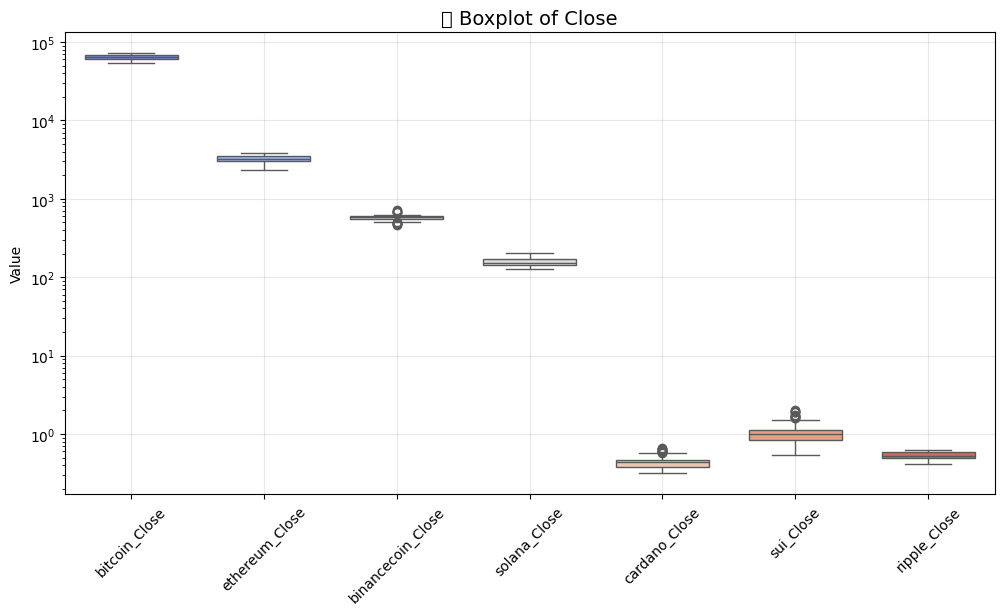

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.



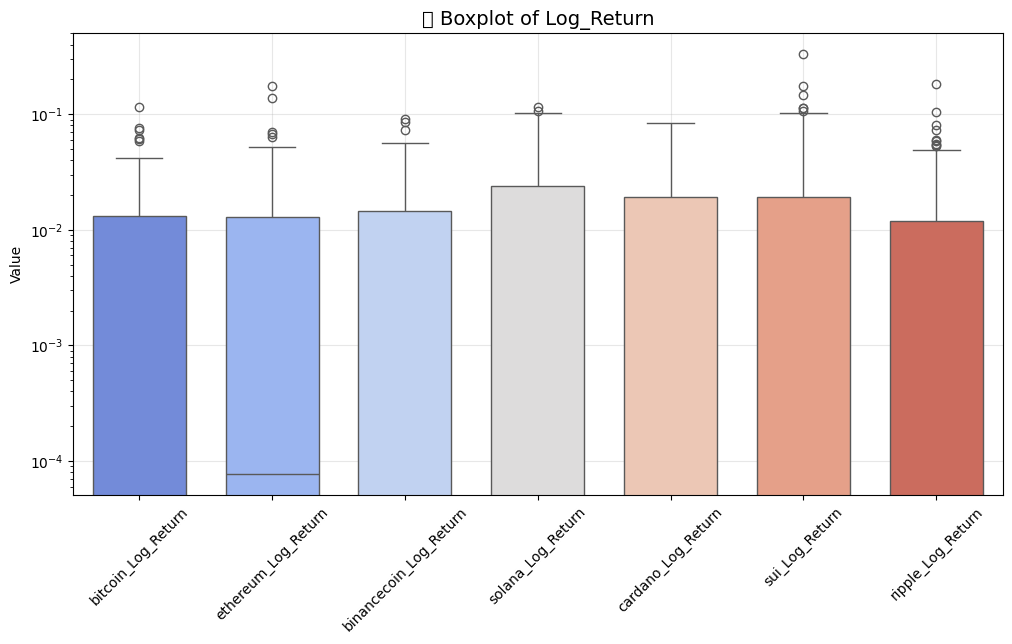

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.



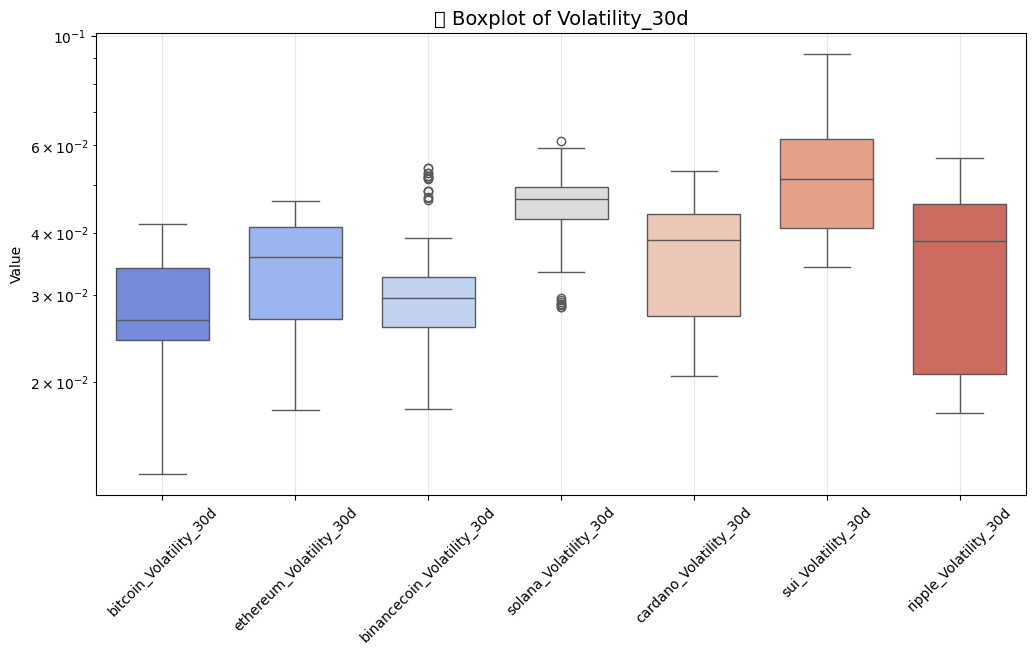

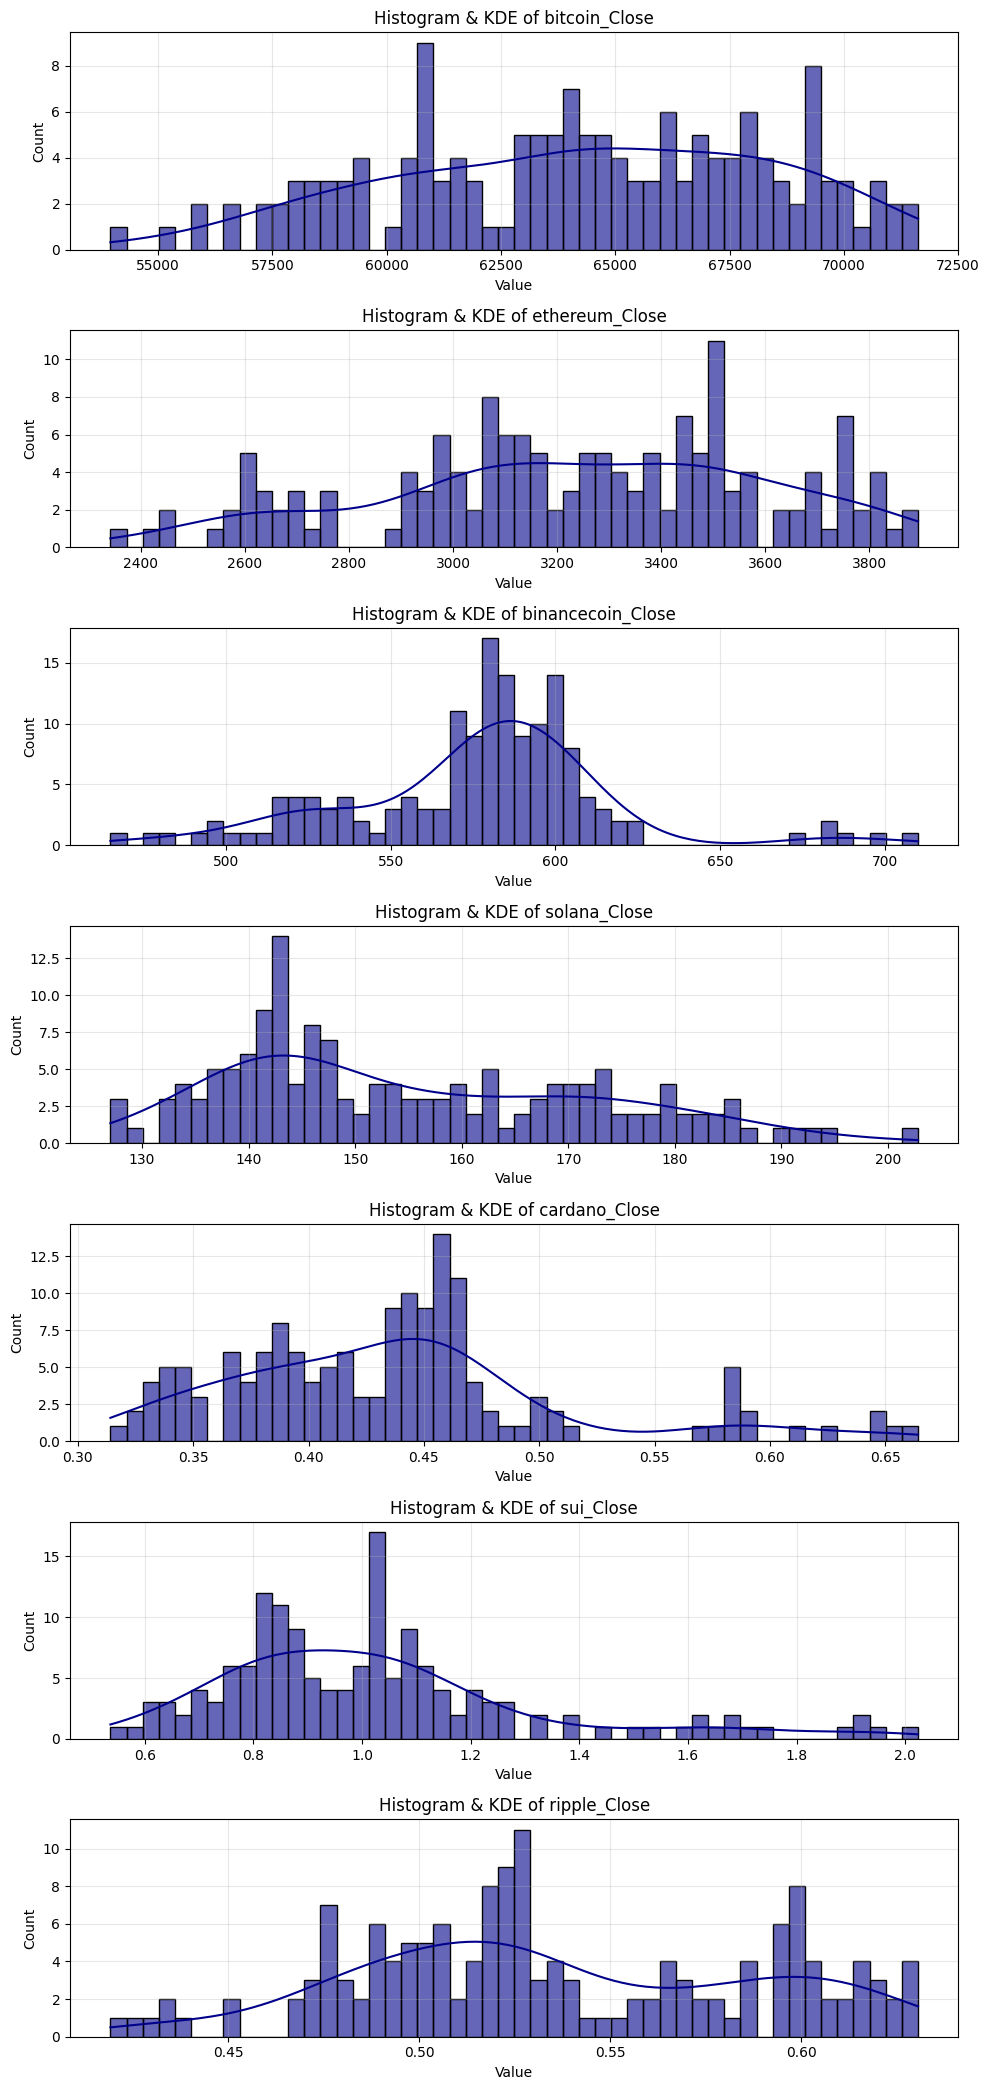

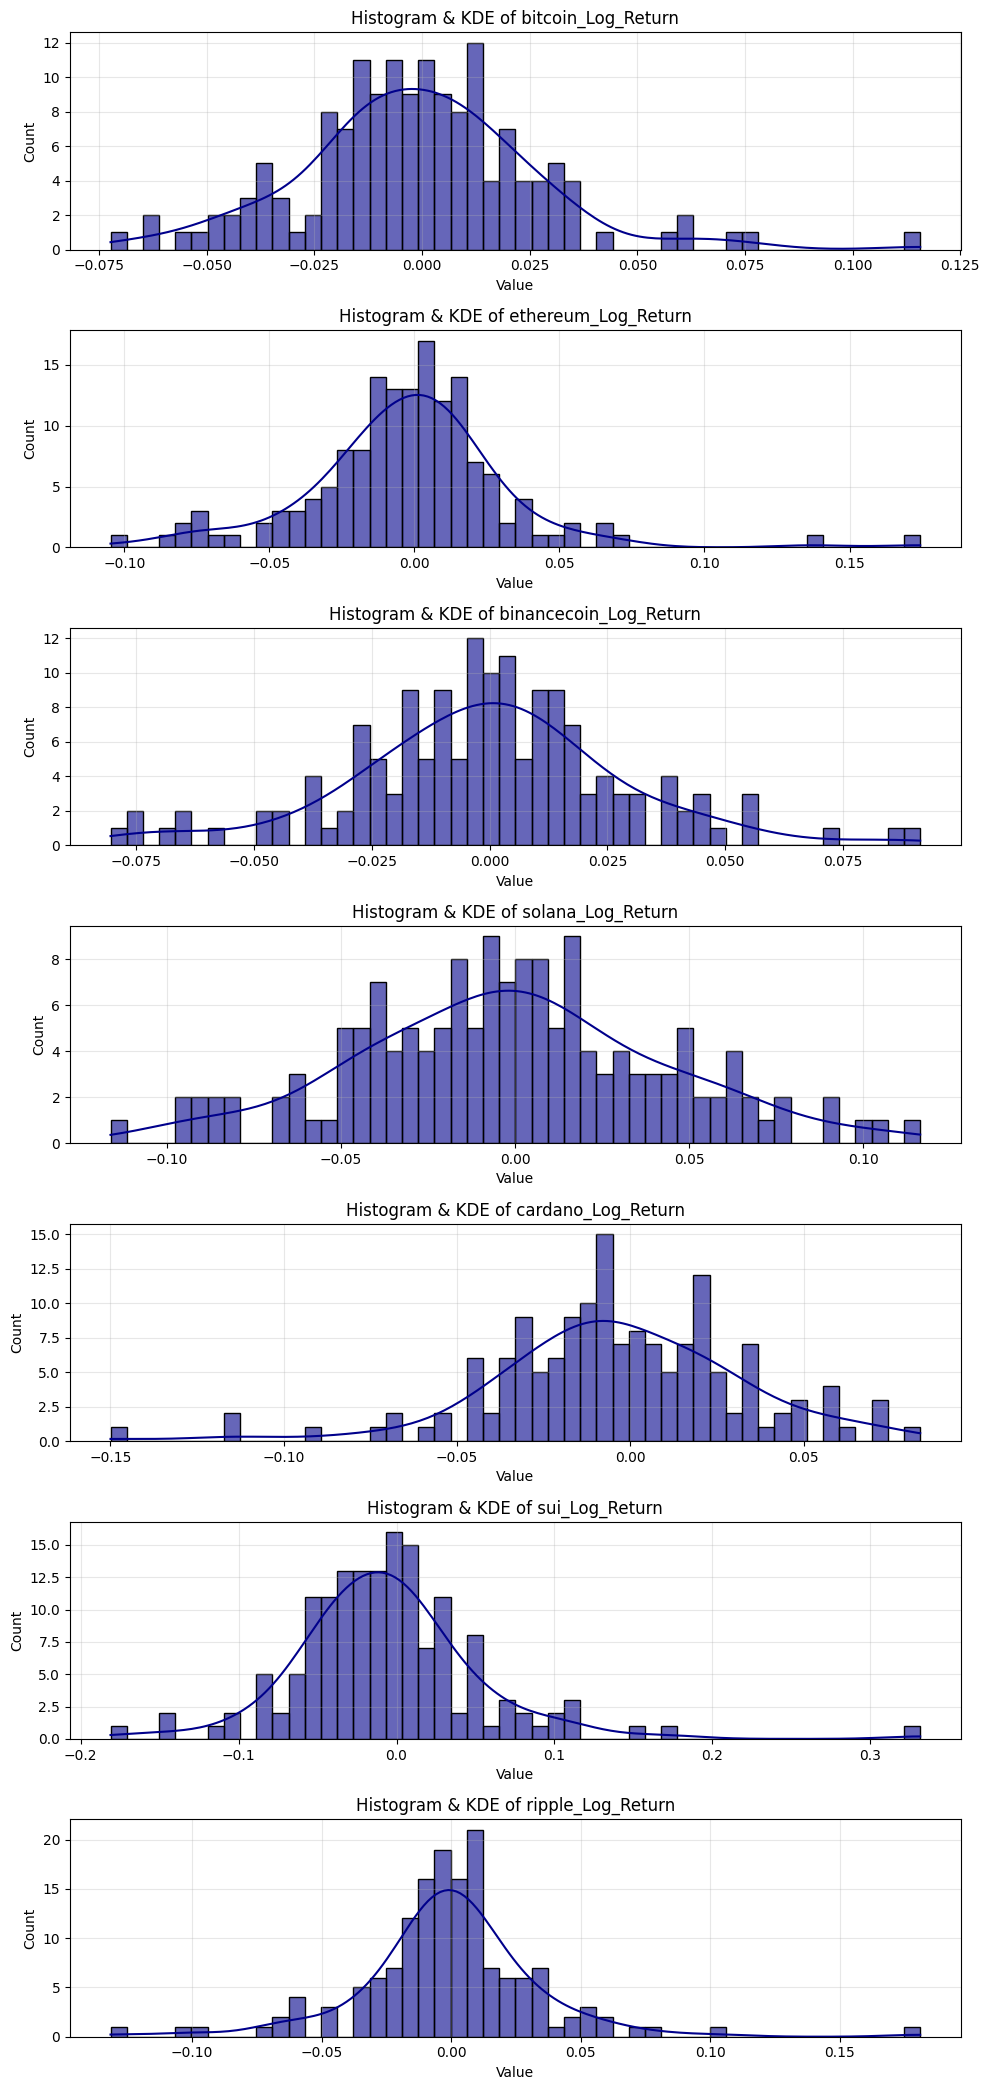

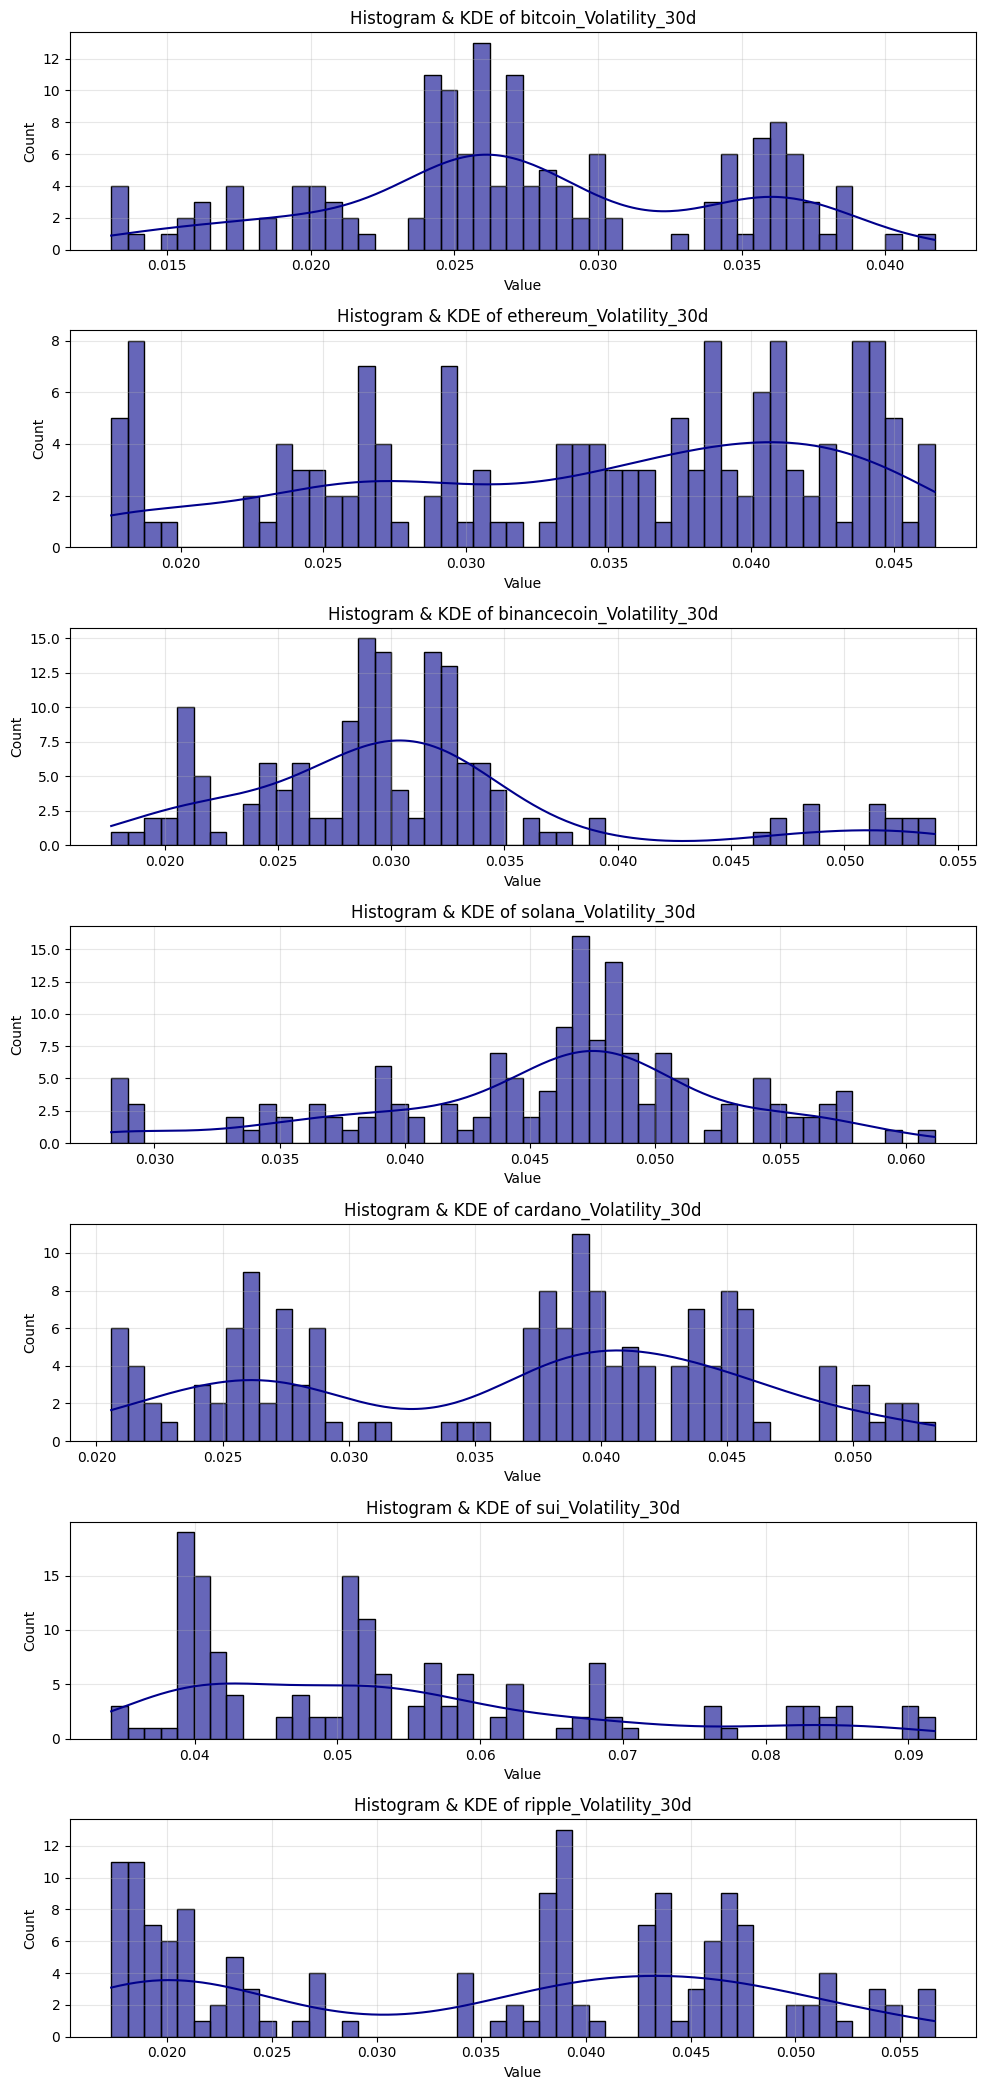


✅ **Dynamic Feature Grouping & Visualization Completed!**


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

############################### ✅ AUTO-DETECT FEATURE GROUPS ###############################

# ✅ Step 1: Identify Unique Feature Groups Based on Column Names
feature_groups = {}
for col in df_selected.columns:
    # Extract feature type (assumes naming convention "{crypto}_{feature}")
    feature_type = col.split("_", 1)[-1]  # Everything after the first "_"

    # Add to dictionary
    if feature_type not in feature_groups:
        feature_groups[feature_type] = []
    feature_groups[feature_type].append(col)

############################### 📊 BOXPLOTS: DYNAMICALLY GROUPED FEATURES ###############################

# ✅ Function to Plot Boxplots
def plot_boxplot(feature_list, title):
    if not feature_list:
        print(f"⚠ No data available for {title}. Skipping...")
        return

    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df_selected[feature_list], showfliers=True, width=0.7, palette="coolwarm")
    plt.yscale("log")  # Log scale for better visualization
    plt.title(f"📊 {title}", fontsize=14)
    plt.ylabel("Value")
    plt.xticks(rotation=45)
    plt.grid(alpha=0.3)
    plt.show()

# ✅ Step 2: Generate Boxplots for Each Feature Group
for group_name, feature_list in feature_groups.items():
    plot_boxplot(feature_list, f"Boxplot of {group_name}")

############################### 📊 HISTOGRAMS + KDE PLOTS ###############################

# ✅ Function to Plot Histograms & KDE
def plot_histogram(feature_list, title, color="blue"):
    if not feature_list:
        print(f"⚠ No data available for {title}. Skipping...")
        return

    fig, axes = plt.subplots(nrows=len(feature_list), ncols=1, figsize=(10, len(feature_list) * 3))

    for i, col in enumerate(feature_list):
        sns.histplot(df_selected[col], kde=True, bins=50, ax=axes[i], color=color, alpha=0.6)
        axes[i].set_title(f"Histogram & KDE of {col}", fontsize=12)
        axes[i].set_xlabel("Value")
        axes[i].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

# ✅ Step 3: Generate Histograms for Each Feature Group
for group_name, feature_list in feature_groups.items():
    plot_histogram(feature_list, f"Histogram & KDE of {group_name}", color="darkblue")

print("\n✅ **Dynamic Feature Grouping & Visualization Completed!**")


#### Risk vs Return

In [17]:
import pandas as pd
import plotly.express as px

############################### ✅ COMPUTE MEAN & VOLATILITY ###############################

# ✅ Step 1: Calculate Mean & Volatility (Standard Deviation)
returns_volatility = pd.DataFrame({
    "Mean Value": df_selected.mean(),
    "Volatility (Std Dev)": df_selected.std()
})

############################### ✅ AUTO-DETECT FEATURE GROUPS ###############################

feature_groups = {}
for col in df_selected.columns:
    # Extract feature type dynamically
    feature_type = col.split("_", 1)[-1]  # Everything after first "_"

    # Add to dictionary
    if feature_type not in feature_groups:
        feature_groups[feature_type] = []
    feature_groups[feature_type].append(col)

############################### 📊 SCATTER PLOTS: RISK VS RETURN ###############################

# ✅ Function to Generate Scatter Plots
def plot_scatter(feature_list, title):
    if not feature_list:
        print(f"⚠ No data available for {title}. Skipping...")
        return

    subset_df = returns_volatility.loc[feature_list]  # Filter relevant features

    fig = px.scatter(
        subset_df,
        x="Volatility (Std Dev)",
        y="Mean Value",
        text=subset_df.index,
        size_max=15,
        color=subset_df.index,
        title=title
    )

    fig.update_traces(textposition='top center')
    fig.update_layout(xaxis_title="Volatility (Std Dev)", yaxis_title="Mean Value")
    fig.show()

# ✅ Step 3: Generate Scatter Plots for Each Feature Group (Including BTC & ETH)
print("\n📊 **Generating Scatter Plots for All Cryptos (Including BTC & ETH)...**")
for group_name, feature_list in feature_groups.items():
    plot_scatter(feature_list, f"Risk vs. Return: {group_name} (All Cryptos)")

############################### 🔥 EXCLUDE BITCOIN & ETHEREUM & REPEAT PLOTS ###############################

# ✅ Step 4: Filter Out BTC & ETH Features
btc_eth_features = [col for col in df_selected.columns if col.startswith(("bitcoin", "ethereum"))]
df_selected_no_btc_eth = df_selected.drop(columns=btc_eth_features)

# ✅ Step 5: Recompute Mean & Volatility for Altcoins Only
returns_volatility_no_btc_eth = pd.DataFrame({
    "Mean Value": df_selected_no_btc_eth.mean(),
    "Volatility (Std Dev)": df_selected_no_btc_eth.std()
})

# ✅ Step 6: Recreate Feature Groups Without BTC & ETH
feature_groups_no_btc_eth = {}
for col in df_selected_no_btc_eth.columns:
    feature_type = col.split("_", 1)[-1]  # Extract feature type
    if feature_type not in feature_groups_no_btc_eth:
        feature_groups_no_btc_eth[feature_type] = []
    feature_groups_no_btc_eth[feature_type].append(col)

# ✅ Step 7: Generate Scatter Plots Again (Without BTC & ETH)
print("\n📊 **Generating Scatter Plots for Altcoins Only (Excluding BTC & ETH)...**")
for group_name, feature_list in feature_groups_no_btc_eth.items():
    plot_scatter(feature_list, f"Risk vs. Return: {group_name} (Excluding BTC & ETH)")

print("\n✅ **Dynamic Scatter Plots Completed!**")



📊 **Generating Scatter Plots for All Cryptos (Including BTC & ETH)...**



📊 **Generating Scatter Plots for Altcoins Only (Excluding BTC & ETH)...**



✅ **Dynamic Scatter Plots Completed!**


#### Line Plots of All Features


📊 **Plotting All Cryptos Before Removing BTC & ETH...**


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.



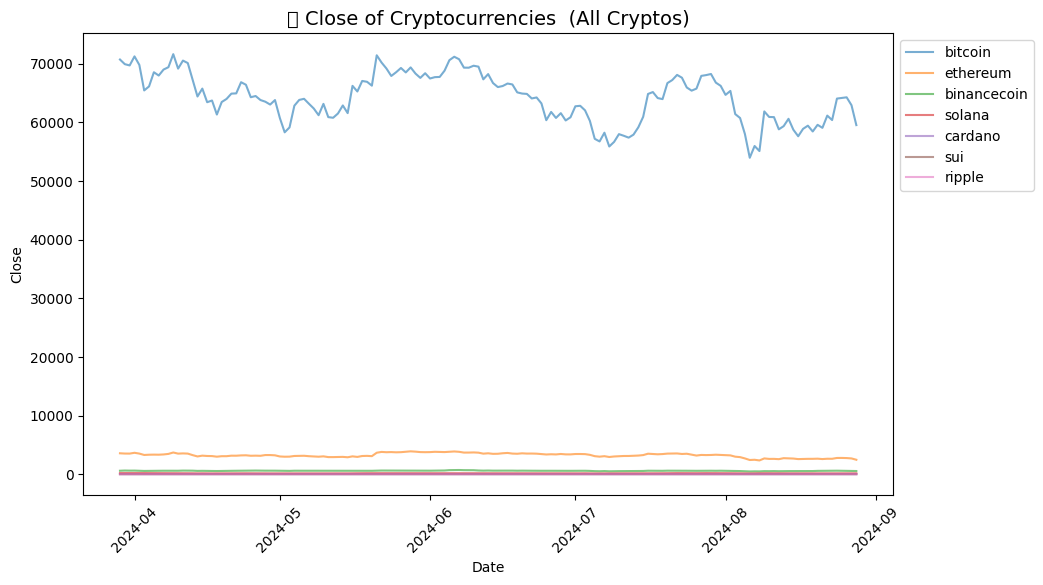

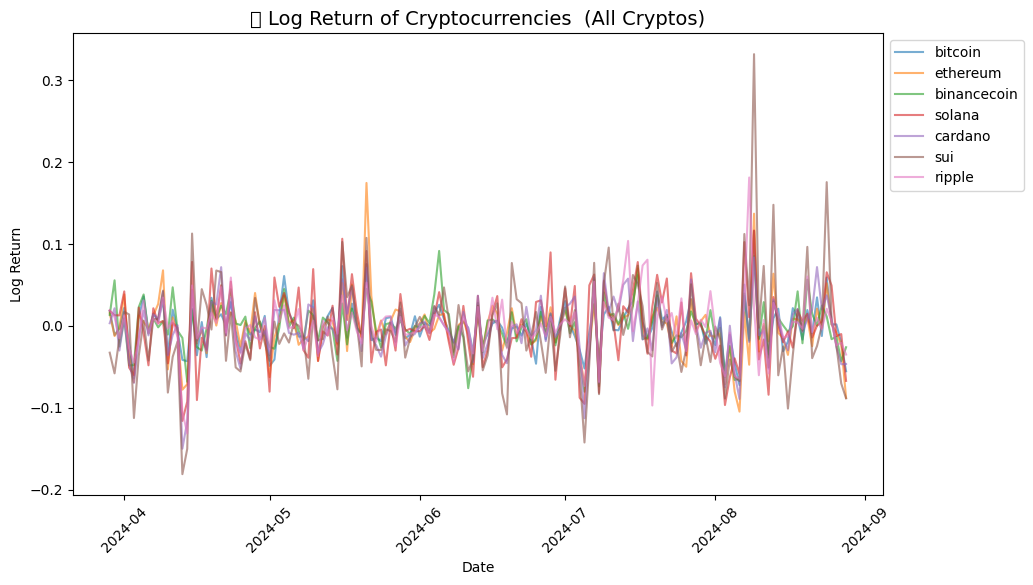

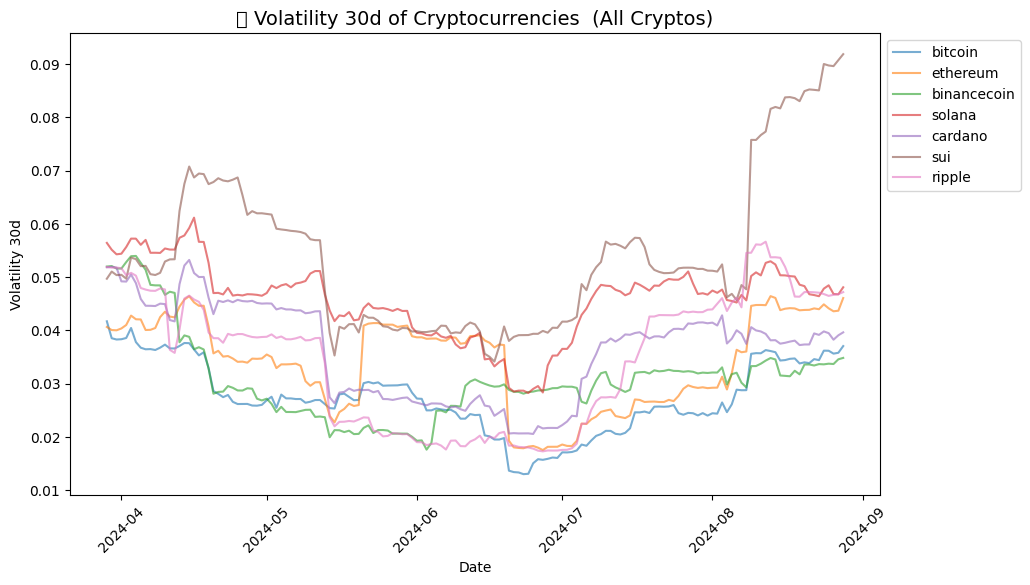


🚫 **Plotting Cryptos AFTER Removing BTC & ETH...**


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.



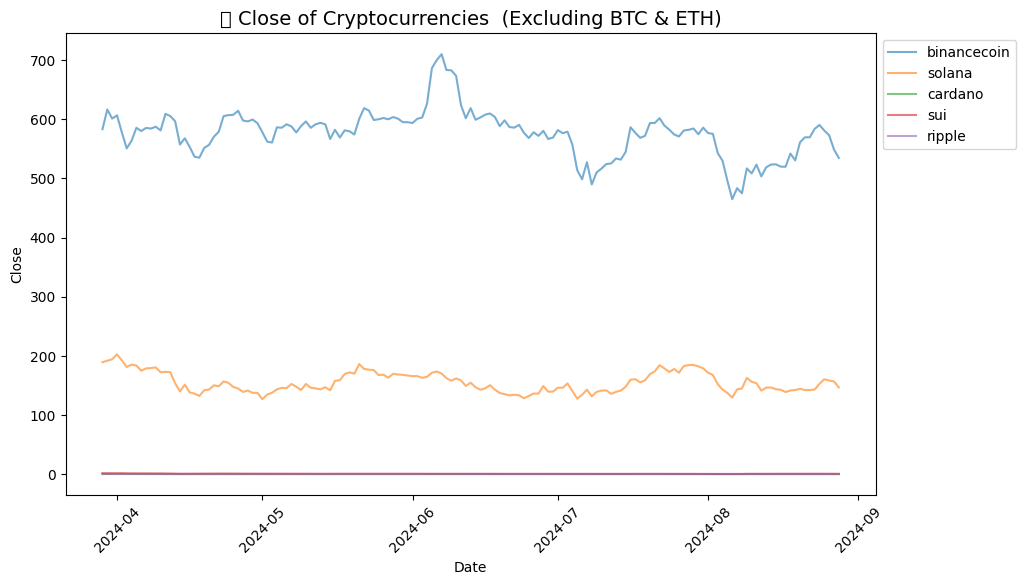

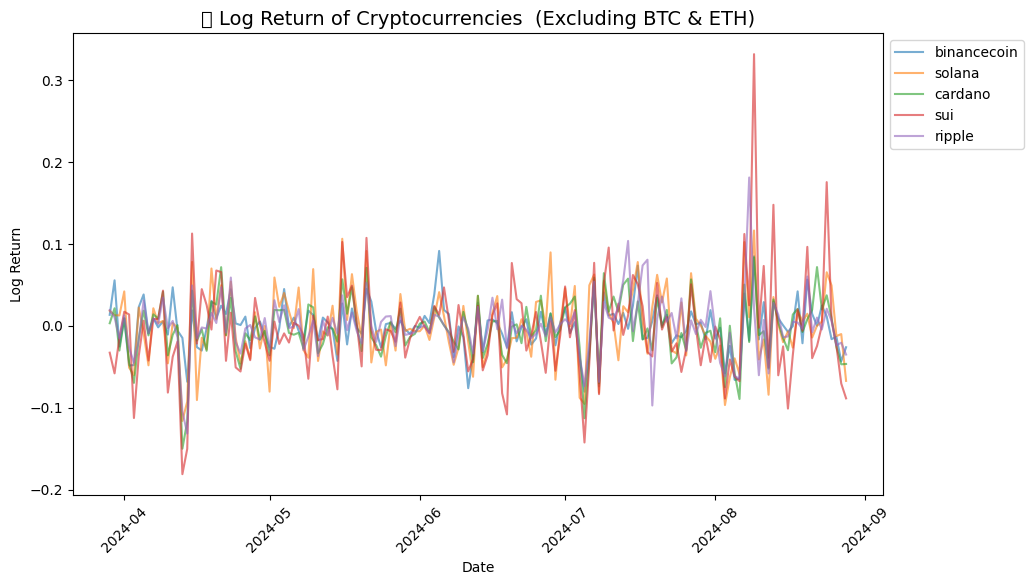

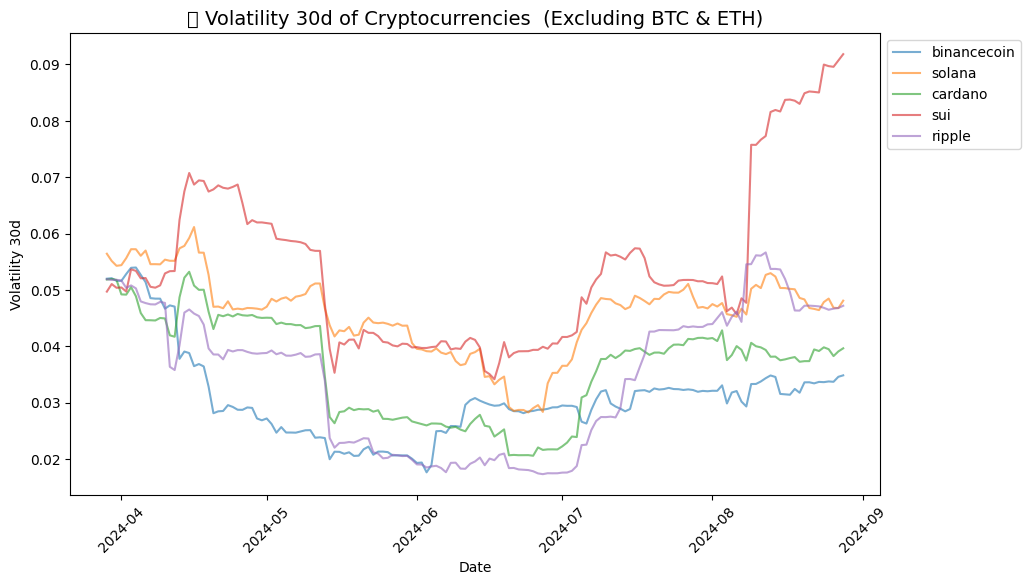


✅ **Comparison Completed!**


In [18]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

############################### 📊 HELPER FUNCTION TO FORMAT DATES ###############################

def format_date_axis(ax):
    """Formats date axis for better readability."""
    ax.xaxis.set_major_locator(mdates.MonthLocator())  # Show one tick per month
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))  # Format as "YYYY-MM"
    plt.xticks(rotation=45)

############################### 📊 DYNAMIC FEATURE GROUPING ###############################

# ✅ Step 1: Extract feature groups dynamically from `df_selected`
def extract_group(feature_name):
    """Extracts the feature type dynamically from {crypto}_{feature} format."""
    return feature_name.split("_", 1)[-1]  # Keeps everything after the first "_"

# ✅ Step 2: Create feature group mapping
feature_groups = {}
for col in df_selected.columns:  # Ensure we are using the correct variable
    feature_type = extract_group(col)  # Extract dynamic feature type
    if feature_type not in feature_groups:
        feature_groups[feature_type] = []
    feature_groups[feature_type].append(col)

############################### 📈 PLOT FUNCTION FOR GROUPED FEATURES ###############################

def plot_grouped_features(group_name, feature_list, title_suffix=" (All Cryptos)"):
    """Plots all cryptocurrencies for a given feature group on the same axis."""
    fig, ax = plt.subplots(figsize=(12, 6))

    if not feature_list:
        print(f"⚠ No matching features for {group_name}. Skipping plot.")
        return

    for col in feature_list:
        crypto_name = col.split("_")[0]  # Extract the cryptocurrency name
        ax.plot(df_selected.index, df_selected[col], label=crypto_name, alpha=0.6)

    format_date_axis(ax)
    ax.set_title(f"📊 {group_name.replace('_', ' ')} of Cryptocurrencies {title_suffix}", fontsize=14)
    ax.set_xlabel("Date")
    ax.set_ylabel(group_name.replace("_", " "))

    # ✅ Move legend outside the plot
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.subplots_adjust(right=0.8)  # Adjust space for legend
    plt.show()

############################### 📊 PLOT BEFORE REMOVING BTC & ETH ###############################

print("\n📊 **Plotting All Cryptos Before Removing BTC & ETH...**")
for group_name, feature_list in feature_groups.items():
    plot_grouped_features(group_name, feature_list)

############################### 🚫 REMOVE BTC & ETH & PLOT AGAIN ###############################

# ✅ Remove BTC & ETH dynamically
df_selected_no_btc_eth = df_selected[[col for col in df_selected.columns if not col.startswith(("bitcoin_", "ethereum_"))]]

# ✅ Extract updated feature groups dynamically
filtered_feature_groups = {}
for col in df_selected_no_btc_eth.columns:
    feature_type = extract_group(col)  # Extract dynamic feature type
    if feature_type not in filtered_feature_groups:
        filtered_feature_groups[feature_type] = []
    filtered_feature_groups[feature_type].append(col)

# ✅ Step 2: Generate plots AFTER removing BTC & ETH
print("\n🚫 **Plotting Cryptos AFTER Removing BTC & ETH...**")
for group_name, feature_list in filtered_feature_groups.items():
    plot_grouped_features(group_name, feature_list, title_suffix=" (Excluding BTC & ETH)")

print("\n✅ **Comparison Completed!**")


#### Histograms of All Features

<ipython-input-19-5abd389677ad>:49: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.



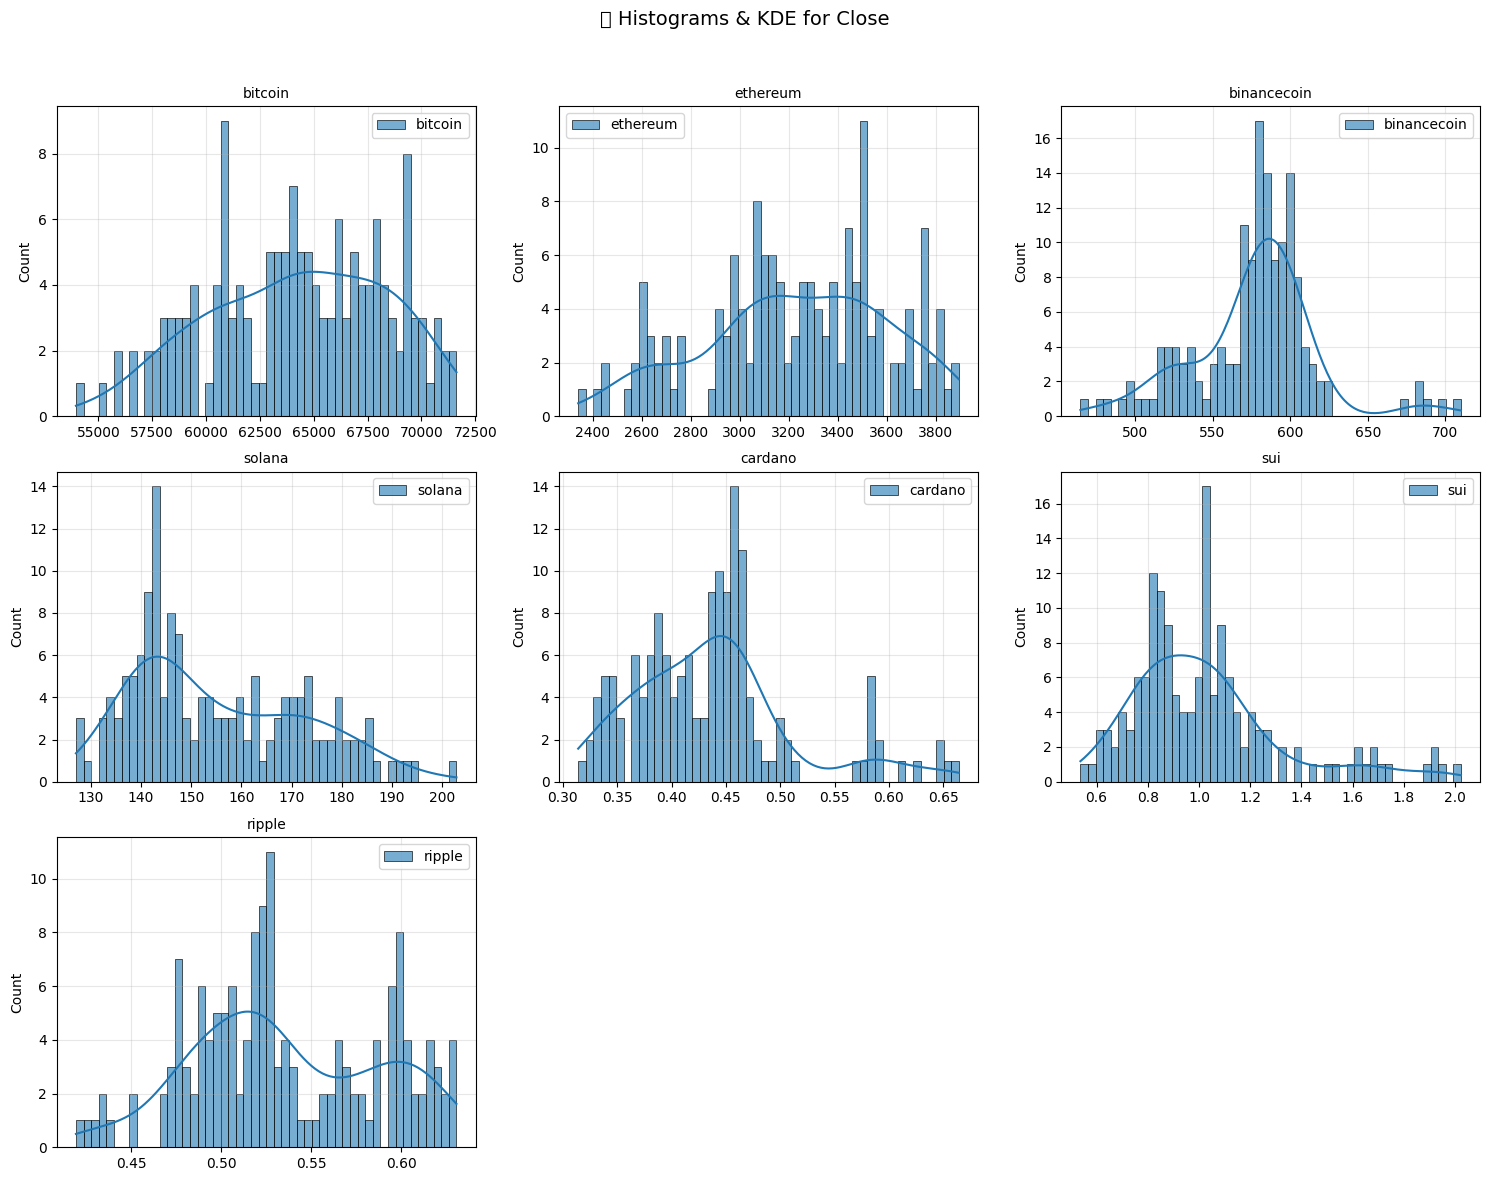

<ipython-input-19-5abd389677ad>:49: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.



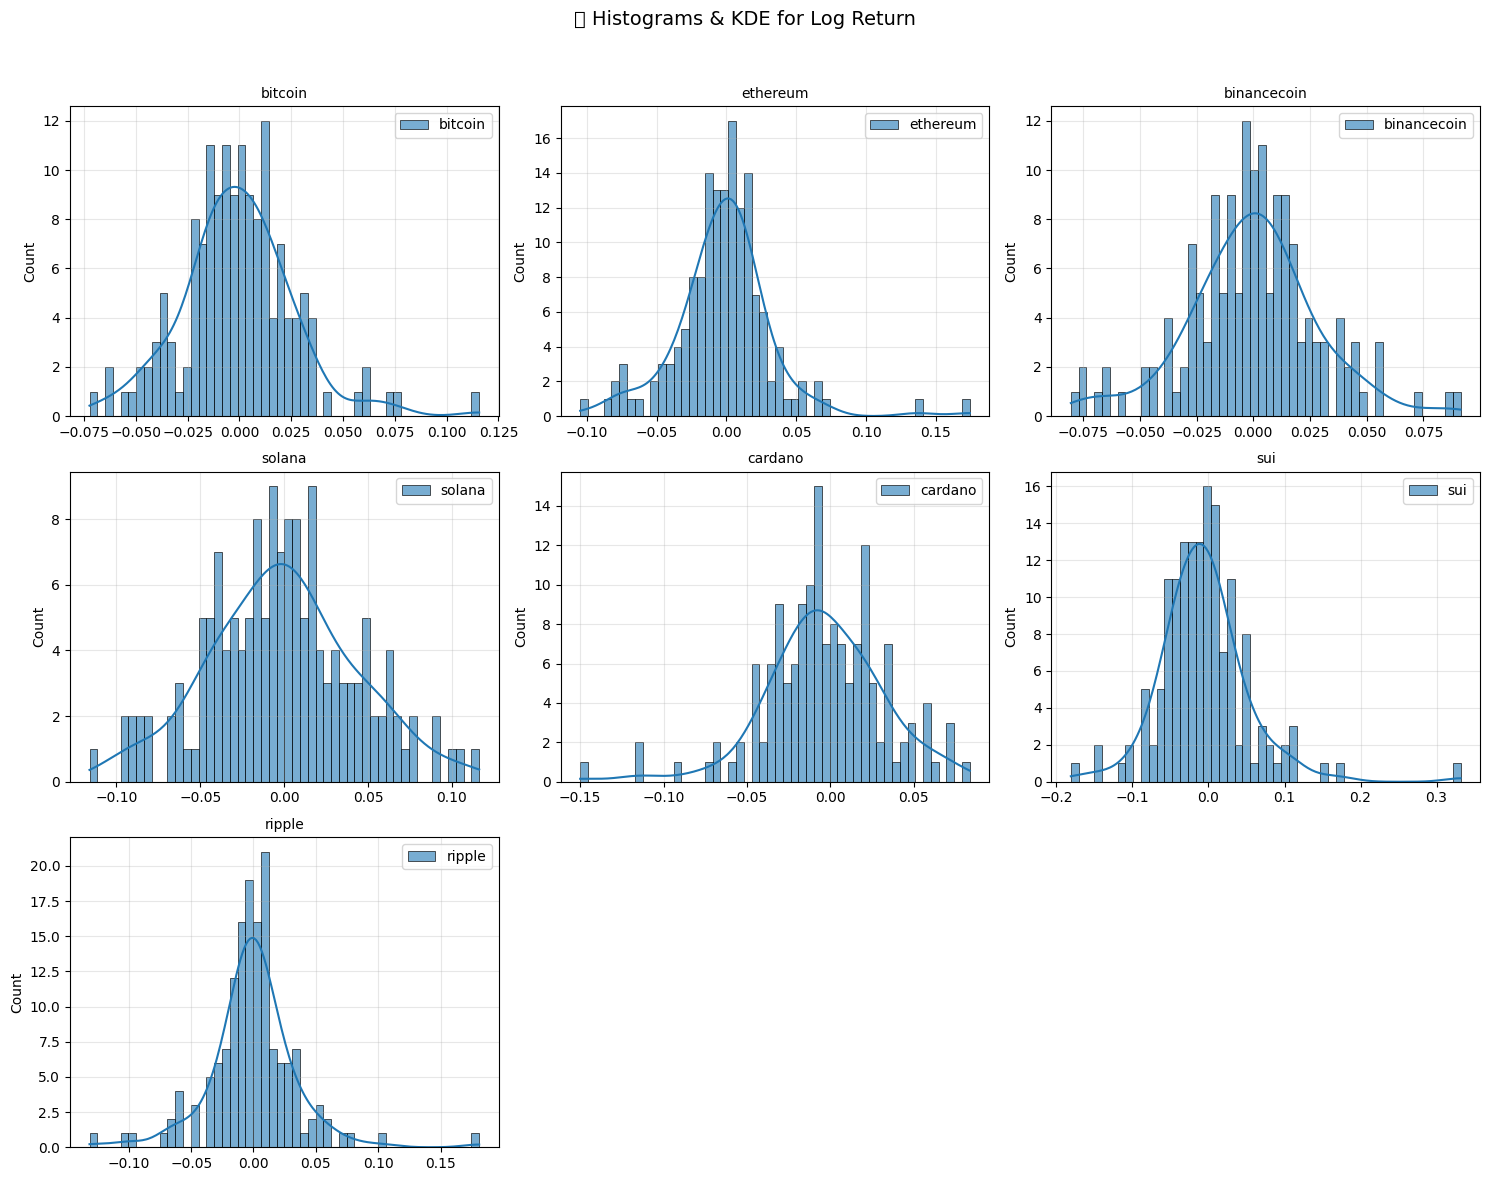

<ipython-input-19-5abd389677ad>:49: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.



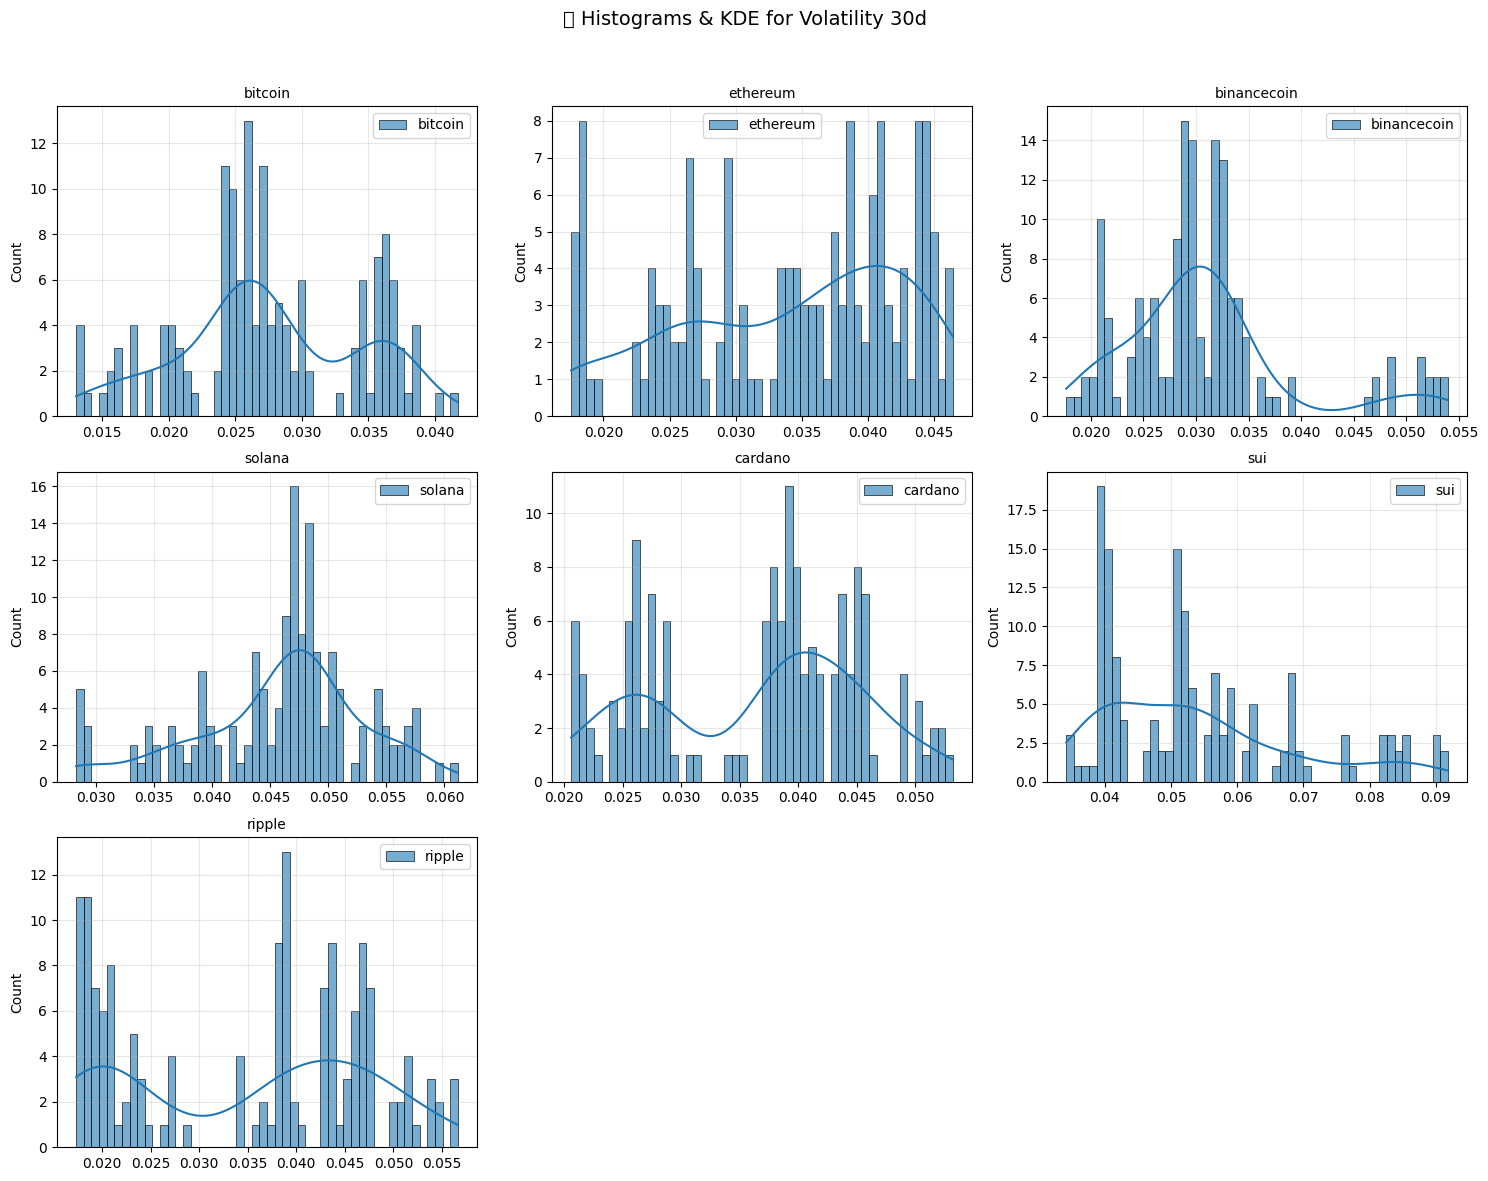

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import math

############################### 📊 DYNAMIC FEATURE GROUPING ###############################

# ✅ Step 1: Extract Feature Groups Dynamically
def extract_group(feature_name):
    """Extracts the feature type dynamically from {crypto}_{feature} format."""
    return feature_name.split("_", 1)[-1]  # Keeps everything after the first "_"

# ✅ Step 2: Create feature group mapping
feature_groups = {}
for col in df_selected.columns:  # Ensure we use the selected features
    feature_type = extract_group(col)  # Extract feature type
    if feature_type not in feature_groups:
        feature_groups[feature_type] = []
    feature_groups[feature_type].append(col)

############################### 📊 OPTIMIZED HISTOGRAM & KDE PLOTTING FUNCTION ###############################

def plot_grouped_histograms(feature_groups, dataset, plots_per_row=3):
    """Plots grouped histograms with multiple plots per row for better readability."""

    for group_name, feature_list in feature_groups.items():
        if not feature_list:
            continue  # Skip empty groups

        num_features = len(feature_list)
        num_rows = math.ceil(num_features / plots_per_row)  # Compute required rows

        fig, axes = plt.subplots(nrows=num_rows, ncols=plots_per_row, figsize=(15, num_rows * 4))
        fig.suptitle(f"📊 Histograms & KDE for {group_name.replace('_', ' ')}", fontsize=14)  # Group title

        axes = axes.flatten()  # Ensure axes is a list for consistent iteration

        for i, col in enumerate(feature_list):
            crypto_name = col.split("_")[0]  # Extract the cryptocurrency name
            sns.histplot(dataset[col], kde=True, bins=50, ax=axes[i], alpha=0.6, label=crypto_name)
            axes[i].set_title(f"{crypto_name}", fontsize=10)
            axes[i].set_xlabel("")  # Remove redundant x-axis labels
            axes[i].grid(alpha=0.3)
            axes[i].legend()

        # Hide empty subplots
        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        plt.subplots_adjust(top=0.9)  # Adjust space for the main title
        plt.show()

# ✅ Step 3: Plot Histograms & KDEs for All Detected Feature Groups (Compact Layout)
plot_grouped_histograms(feature_groups, df_selected)


# 7. Baseline Model:
### 1.7.1 Modern Portoflio Theory

* prove not to include other cols bevaud below is ony for logn_returns

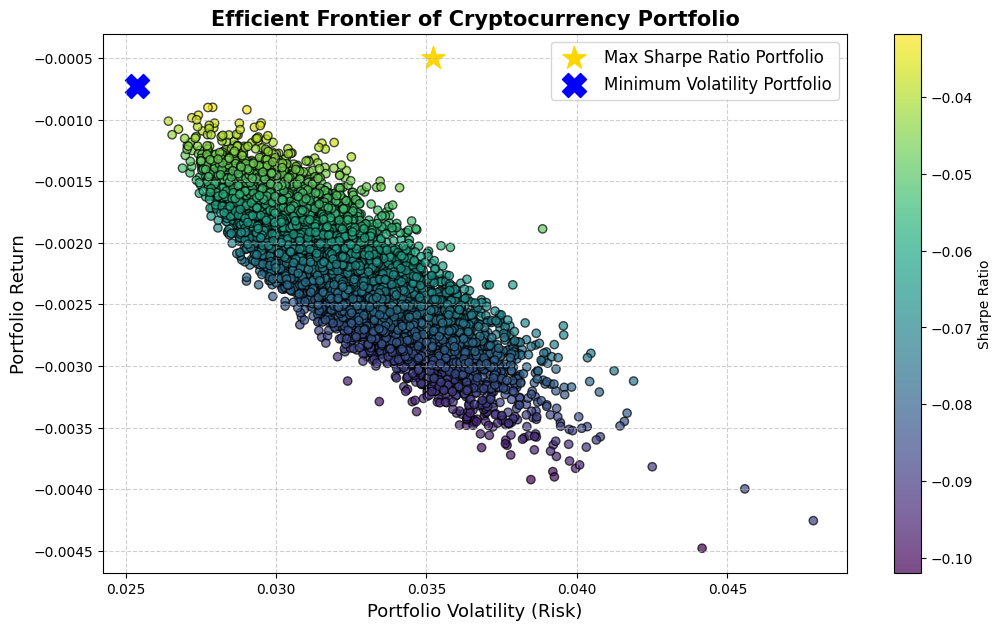


✅ **Optimal Portfolio Weights (Max Sharpe Ratio)**:
bitcoin_Log_Return: 0.0000
ethereum_Log_Return: 0.0000
binancecoin_Log_Return: 0.0000
solana_Log_Return: 0.0000
cardano_Log_Return: 0.0000
sui_Log_Return: 0.0000
ripple_Log_Return: 1.0000

✅ **Optimal Portfolio Weights (Min Volatility)**:
bitcoin_Log_Return: 0.4583
ethereum_Log_Return: 0.0000
binancecoin_Log_Return: 0.3621
solana_Log_Return: 0.0000
cardano_Log_Return: 0.0000
sui_Log_Return: 0.0000
ripple_Log_Return: 0.1796

📉 **Portfolio Risk Metrics:**
✅ Portfolio VaR (95% Confidence): -0.0599
✅ Portfolio TVaR (95% Confidence): -0.0793


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.



KeyboardInterrupt: 

In [20]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# from scipy.optimize import minimize

# # ✅ Extract necessary data (log returns)
# log_returns = df_selected.filter(like="Log_Return")

# # ✅ Step 1: Calculate mean returns & covariance matrix
# mean_returns = log_returns.mean()
# cov_matrix = log_returns.cov()

# # ✅ Step 2: Generate random portfolio weights & compute expected return & volatility
# num_portfolios = 10000
# results = np.zeros((3, num_portfolios))  # Store returns, volatility, Sharpe ratio
# weights_record = []

# for i in range(num_portfolios):
#     weights = np.random.random(len(mean_returns))
#     weights /= np.sum(weights)  # Normalize to sum to 1

#     portfolio_return = np.sum(weights * mean_returns)
#     portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
#     sharpe_ratio = portfolio_return / portfolio_volatility  # Assuming risk-free rate = 0

#     results[:, i] = portfolio_return, portfolio_volatility, sharpe_ratio
#     weights_record.append(weights)

# # ✅ Step 3: Compute Portfolio Risk (VaR & TVaR)

# # ✅ Compute Portfolio Returns for Each Random Portfolio
# portfolio_returns = np.dot(log_returns, np.array(weights_record).T)

# # ✅ Define Confidence Level for VaR & TVaR
# confidence_level = 0.95

# # ✅ Compute Portfolio VaR at 95% Level
# VaR_95 = np.percentile(portfolio_returns, 100 * (1 - confidence_level))

# # ✅ Compute Portfolio TVaR (Expected Shortfall Beyond VaR)
# TVaR_95 = portfolio_returns[portfolio_returns <= VaR_95].mean()

# # ✅ Step 4: Optimize for Maximum Sharpe Ratio
# def negative_sharpe(weights):
#     port_return = np.sum(weights * mean_returns)
#     port_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
#     return -port_return / port_volatility  # Negative because we minimize in `minimize()`

# constraints = {"type": "eq", "fun": lambda w: np.sum(w) - 1}  # Sum of weights = 1
# bounds = [(0, 1) for _ in range(len(mean_returns))]  # No short-selling
# initial_guess = [1/len(mean_returns)] * len(mean_returns)

# opt_results = minimize(negative_sharpe, initial_guess, method="SLSQP", bounds=bounds, constraints=constraints)
# optimal_weights = opt_results.x
# max_sharpe_return = np.sum(optimal_weights * mean_returns)
# max_sharpe_volatility = np.sqrt(np.dot(optimal_weights.T, np.dot(cov_matrix, optimal_weights)))

# # ✅ Step 5: Optimize for Minimum Volatility Portfolio
# def portfolio_volatility(weights):
#     return np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

# min_vol_results = minimize(portfolio_volatility, initial_guess, method="SLSQP", bounds=bounds, constraints=constraints)
# min_vol_weights = min_vol_results.x
# min_vol_return = np.sum(min_vol_weights * mean_returns)
# min_vol_volatility = np.sqrt(np.dot(min_vol_weights.T, np.dot(cov_matrix, min_vol_weights)))

# # ✅ Step 6: Plot Efficient Frontier with Optimal Portfolios & Risk Metrics
# plt.figure(figsize=(12, 7))

# # Scatter plot of portfolios, colored by Sharpe Ratio
# sc = plt.scatter(results[1, :], results[0, :], c=results[2, :], cmap="viridis", alpha=0.7, edgecolors="k")
# plt.colorbar(sc, label="Sharpe Ratio")

# # ✅ Mark the Optimal Portfolios
# plt.scatter(max_sharpe_volatility, max_sharpe_return, color="gold", marker="*", s=300, label="Max Sharpe Ratio Portfolio")
# plt.scatter(min_vol_volatility, min_vol_return, color="blue", marker="X", s=300, label="Minimum Volatility Portfolio")

# # ✅ Style Enhancements
# plt.xlabel("Portfolio Volatility (Risk)", fontsize=13)
# plt.ylabel("Portfolio Return", fontsize=13)
# plt.title("Efficient Frontier of Cryptocurrency Portfolio", fontsize=15, fontweight="bold")
# plt.grid(True, linestyle="--", alpha=0.6)
# plt.legend(fontsize=12)
# plt.show()

# # ✅ Step 7: Print Optimal Portfolio Weights & Risk Metrics
# print("\n✅ **Optimal Portfolio Weights (Max Sharpe Ratio)**:")
# for crypto, weight in zip(log_returns.columns, optimal_weights):
#     print(f"{crypto}: {weight:.4f}")

# print("\n✅ **Optimal Portfolio Weights (Min Volatility)**:")
# for crypto, weight in zip(log_returns.columns, min_vol_weights):
#     print(f"{crypto}: {weight:.4f}")

# print("\n📉 **Portfolio Risk Metrics:**")
# print(f"✅ Portfolio VaR (95% Confidence): {VaR_95:.4f}")
# print(f"✅ Portfolio TVaR (95% Confidence): {TVaR_95:.4f}")

# # ✅ Step 8: Visualizing Portfolio Return Distribution with VaR & TVaR
# plt.figure(figsize=(12, 6))
# sns.histplot(portfolio_returns, bins=50, kde=True, color="blue", alpha=0.6)
# plt.axvline(VaR_95, color="red", linestyle="--", label=f"VaR (95%): {VaR_95:.4f}")
# plt.axvline(TVaR_95, color="darkred", linestyle="--", label=f"TVaR (95%): {TVaR_95:.4f}")

# # ✅ Style Enhancements
# plt.title("📉 Portfolio Return Distribution with VaR & TVaR", fontsize=14, fontweight="bold")
# plt.xlabel("Portfolio Returns", fontsize=12)
# plt.ylabel("Frequency", fontsize=12)
# plt.legend(fontsize=12)
# plt.grid(True, linestyle="--", alpha=0.6)
# plt.show()


What This Means:

This portfolio is fully allocated to Binance Coin (BNB), meaning that based on the mean-variance optimization, Binance Coin alone provides the highest risk-adjusted return (Sharpe Ratio).
All other assets receive 0% allocation because they do not improve the portfolio’s risk-adjusted return (Sharpe Ratio).
This suggests that, at least historically, BNB had the best return per unit of risk.
Possible Issues:

The model might be too reliant on historical data, and not considering diversification properly.
Potential Overfitting: If the dataset is small, this result might not generalize to future data.
Adding constraints (e.g., limiting max weight per asset) might lead to a more balanced portfolio.


---
What This Means:

This portfolio prioritizes minimizing risk (volatility), not maximizing return.
The optimizer found that the lowest risk combination is:
46.41% in Bitcoin
35.77% in Binance Coin (BNB)
17.81% in Ripple (XRP)
0% allocation to other assets
Bitcoin has historically lower volatility than other cryptocurrencies, so it gets a large allocation.
Implications:

Diversification: Unlike the Max Sharpe portfolio, this one distributes the risk across three assets.
More Stable: It might generate smoother returns, but potentially lower profits.
🔹 Key Takeaways
Max Sharpe Portfolio: All in on Binance Coin (BNB) – highest risk-adjusted return but potentially overfitted to past data.
Min Volatility Portfolio: Diversifies into BTC, BNB, and XRP – prioritizes stability but might give up potential returns.
Further Steps: You could add constraints to limit max allocations per asset and force better diversification.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize

############################### 📊 FEATURE SELECTION STRATEGY ###############################

# ✅ Extract Feature Groups Dynamically
feature_groups = {}
for col in df_selected.columns:
    group = col.split("_", 1)[-1]  # Extracts everything after the first underscore
    if group not in feature_groups:
        feature_groups[group] = []
    feature_groups[group].append(col)

# ✅ Initialize Storage for Allocations
optimized_results = {}
group_allocations = {}

# ✅ Setup Subplots for Separate Efficient Frontiers
num_groups = len(feature_groups)
fig, axes = plt.subplots(nrows=num_groups, figsize=(10, 4 * num_groups))

if num_groups == 1:
    axes = [axes]  # Ensure it's iterable for a single subplot case

# ✅ Step 1: Optimize Portfolio Per Feature Group & Plot Efficient Frontier
for idx, (group, features) in enumerate(feature_groups.items()):
    if len(features) < 2:  # Skip groups with insufficient features
        continue

    # Extract feature data
    feature_data = df_selected[features].dropna()

    # Skip if dataset is empty after dropping NaNs
    if feature_data.empty:
        print(f"⚠ Skipping {group} - No valid data points.")
        continue

    # Compute mean returns & covariance
    mean_returns = feature_data.mean()
    cov_matrix = feature_data.cov()

    # ✅ Generate Random Portfolios
    num_portfolios = 5000
    results = np.zeros((3, num_portfolios))  # Store returns, volatility, Sharpe ratio
    weights_record = []

    for i in range(num_portfolios):
        weights = np.random.random(len(mean_returns))
        weights /= np.sum(weights)  # Normalize to sum to 1

        portfolio_return = np.sum(weights * mean_returns)
        portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
        sharpe_ratio = portfolio_return / portfolio_volatility  # Assuming risk-free rate = 0

        results[:, i] = portfolio_return, portfolio_volatility, sharpe_ratio
        weights_record.append(weights)

    # ✅ Step 2: Optimize for Maximum Sharpe Ratio
    def negative_sharpe(weights):
        port_return = np.sum(weights * mean_returns)
        port_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
        return -port_return / port_volatility  # Negative because we minimize in `minimize()`

    constraints = {"type": "eq", "fun": lambda w: np.sum(w) - 1}  # Sum of weights = 1
    bounds = [(0, 1) for _ in range(len(mean_returns))]  # No short-selling
    initial_guess = [1/len(mean_returns)] * len(mean_returns)

    opt_results = minimize(negative_sharpe, initial_guess, method="SLSQP", bounds=bounds, constraints=constraints)
    optimal_weights = opt_results.x

    # ✅ Store Allocations
    group_allocations[group] = pd.Series(optimal_weights, index=features)

    # ✅ Plot Efficient Frontier on Separate Subplots
    ax = axes[idx]
    sc = ax.scatter(results[1, :], results[0, :], c=results[2, :], cmap="viridis", alpha=0.7, edgecolors="k")

    ax.set_title(f"Efficient Frontier for {group}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Portfolio Volatility (Risk)")
    ax.set_ylabel("Portfolio Return")
    ax.grid(True, linestyle="--", alpha=0.6)
    fig.colorbar(sc, ax=ax, label="Sharpe Ratio")

plt.tight_layout()
plt.show()

# ✅ Step 3: Compute Final Portfolio Allocation (Averaging Across Groups)
portfolio_allocations = pd.DataFrame(group_allocations).T
portfolio_allocations["Final_Allocation"] = portfolio_allocations.mean(axis=1)

# ✅ Display Table
from IPython.display import displayok what is next then?
display(portfolio_allocations)


### 1.7.2 Maximum Drawdown Analysis
Why?

MDD helps assess the worst-case scenario loss from peak to trough in portfolio returns.
Sharpe Ratio considers mean returns but does not capture large downward movements.
What to do?

Compute rolling maximum and drawdowns.
Compare MDD for the Min Volatility vs. Max Sharpe portfolios.

In [21]:
def max_drawdown(returns):
    cumulative = (1 + returns).cumprod()
    peak = cumulative.cummax()
    drawdown = (cumulative - peak) / peak
    return drawdown.min()  # Minimum drawdown (most negative)

# ✅ Compute Drawdowns
portfolio_returns = log_returns @ optimal_weights
min_vol_portfolio_returns = log_returns @ min_vol_weights

max_sharpe_mdd = max_drawdown(portfolio_returns)
min_vol_mdd = max_drawdown(min_vol_portfolio_returns)

print(f"📉 **Max Drawdown (Max Sharpe Ratio Portfolio):** {max_sharpe_mdd:.2%}")
print(f"📉 **Max Drawdown (Min Volatility Portfolio):** {min_vol_mdd:.2%}")

📉 **Max Drawdown (Max Sharpe Ratio Portfolio):** -36.27%
📉 **Max Drawdown (Min Volatility Portfolio):** -26.59%


## 1.7.3 Monte Carlo Simulation
Why?

MPT assumes a normal distribution for returns, which may not hold for cryptos.
Monte Carlo simulates multiple potential future paths of portfolio returns.
What to do?

Simulate thousands of possible portfolio outcomes.
Compute the probability of extreme losses.
python
Copy
Edit


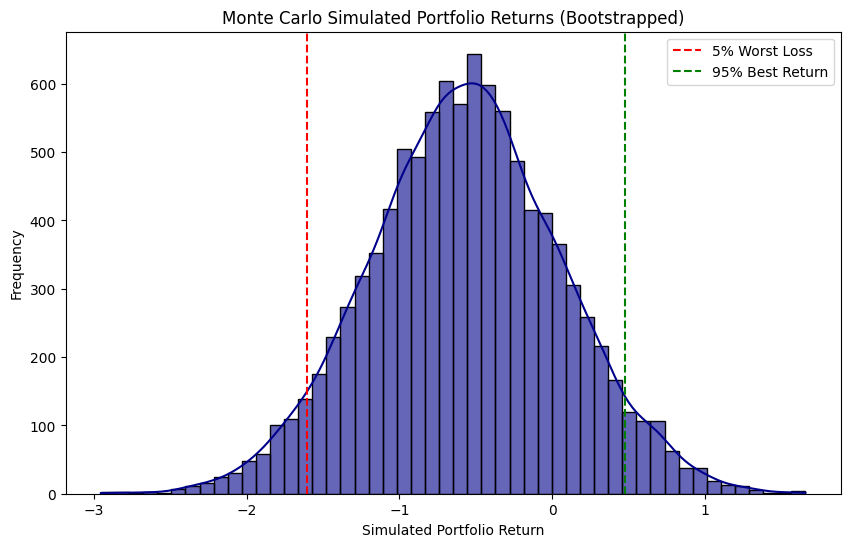

In [22]:
## ASSUME NORMALITY
num_simulations = 10000
simulated_returns = np.zeros(num_simulations)

for i in range(num_simulations):
    simulated_path = np.random.choice(log_returns.values.flatten(), size=252, replace=True)  # Bootstrapping
    simulated_returns[i] = np.sum(simulated_path)

# ✅ Plot Distribution
plt.figure(figsize=(10, 6))
sns.histplot(simulated_returns, bins=50, kde=True, color="darkblue", alpha=0.6)
plt.axvline(np.percentile(simulated_returns, 5), color="red", linestyle="--", label="5% Worst Loss")
plt.axvline(np.percentile(simulated_returns, 95), color="green", linestyle="--", label="95% Best Return")
plt.xlabel("Simulated Portfolio Return")
plt.ylabel("Frequency")
plt.title("Monte Carlo Simulated Portfolio Returns (Bootstrapped)")
plt.legend()
plt.show()


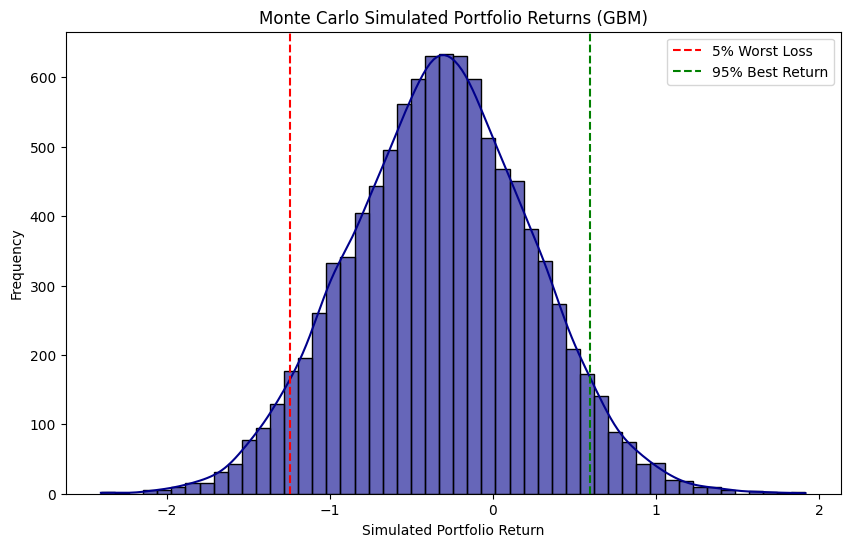

In [23]:
### ASSUME GBM - more realistic for crypto data
num_simulations = 10000
num_days = 252  # 1 Year
simulated_returns = np.zeros(num_simulations)

drift = mean_returns @ optimal_weights - (0.5 * np.diag(cov_matrix).mean())  # Adjust for drift
volatility = np.sqrt(optimal_weights @ cov_matrix @ optimal_weights)  # Portfolio-wide volatility

for i in range(num_simulations):
    shocks = np.random.normal(0, 1, num_days)  # Standard normal random noise
    simulated_path = drift + volatility * shocks  # GBM formula
    simulated_returns[i] = np.sum(simulated_path)

# ✅ Plot Distribution
plt.figure(figsize=(10, 6))
sns.histplot(simulated_returns, bins=50, kde=True, color="darkblue", alpha=0.6)
plt.axvline(np.percentile(simulated_returns, 5), color="red", linestyle="--", label="5% Worst Loss")
plt.axvline(np.percentile(simulated_returns, 95), color="green", linestyle="--", label="95% Best Return")
plt.xlabel("Simulated Portfolio Return")
plt.ylabel("Frequency")
plt.title("Monte Carlo Simulated Portfolio Returns (GBM)")
plt.legend()
plt.show()


## 1.7.4 Value at Risk (VaR) & CVaR
Why?

Value at Risk (VaR) tells you the worst expected loss at a certain confidence level.
Conditional Value at Risk (CVaR) estimates the expected loss beyond the VaR threshold.
What to do?

Compute VaR at 95% confidence level.
Compute CVaR (expected shortfall beyond VaR).

In [ ]:


confidence_level = 0.05  # 95% confidence
var_95 = np.percentile(simulated_returns, 5)
cvar_95 = simulated_returns[simulated_returns <= var_95].mean()

print(f"🔻 **95% Value at Risk (VaR):** {var_95:.4f}")
print(f"🔻 **95% Conditional Value at Risk (CVaR):** {cvar_95:.4f}")


## 1.7.5. Portoflio Rebalancing Strategy
Why?

Your optimized portfolio assumes static weights.
Over time, assets deviate from their optimal allocation due to price fluctuations.
What to do?

Implement a rolling rebalancing strategy (monthly/quarterly).
Compute transaction costs based on weight deviations.

<ipython-input-24-d4e68b82db5e>:6: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



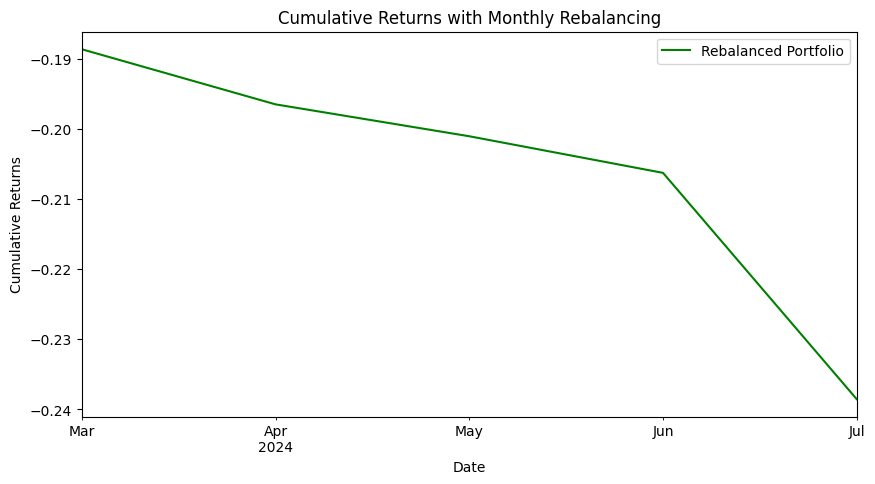

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ✅ Define Monthly Rebalancing Dates (Ensure they exist)
rebalance_dates = log_returns.resample("M").last().index  # Get last available date each month

# ✅ Ensure All Rebalance Dates Exist in Index
rebalance_dates = [date for date in rebalance_dates if date in log_returns.index]

# ✅ Initialize List for Rebalanced Portfolio Returns
rebalanced_portfolio = []

for date in rebalance_dates:
    try:
        # ✅ Compute portfolio weights dynamically (using past data up to rebalancing date)
        past_data = log_returns.loc[:date]  # Use all data up to the rebalancing date
        if past_data.empty:
            continue  # Skip if no data available

        # ✅ Dynamic Weight Adjustment (Mean of Past Returns)
        current_weights = past_data.mean() / past_data.mean().sum()
        current_weights = current_weights.fillna(0)  # Handle NaN values if any

        # ✅ Compute Portfolio Returns on Rebalance Date
        rebalanced_return = (log_returns.loc[date] @ current_weights)
        rebalanced_portfolio.append(rebalanced_return)

    except KeyError:
        print(f"⚠ Skipping {date} (Date Not Found in Index)")

# ✅ Convert to Series
rebalanced_portfolio = pd.Series(rebalanced_portfolio, index=rebalance_dates)

# ✅ Plot Cumulative Returns
plt.figure(figsize=(10, 5))
rebalanced_portfolio.cumsum().plot(label="Rebalanced Portfolio", color="green")
plt.title("Cumulative Returns with Monthly Rebalancing")
plt.xlabel("Date")
plt.ylabel("Cumulative Returns")
plt.legend()
plt.show()


In [25]:
# ✅ Ensure rebalance dates exist in the dataset
rebalance_dates = log_returns.resample("M").last().index  # Get last available date per month

# ✅ Only keep valid dates
rebalance_dates = [date for date in rebalance_dates if date in log_returns.index]

print("✅ Available Rebalance Dates:", rebalance_dates)  # Debugging


✅ Available Rebalance Dates: [Timestamp('2024-03-31 00:00:00'), Timestamp('2024-04-30 00:00:00'), Timestamp('2024-05-31 00:00:00'), Timestamp('2024-06-30 00:00:00'), Timestamp('2024-07-31 00:00:00')]


<ipython-input-25-192881f2d753>:2: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



In [26]:
rebalanced_portfolio = []
valid_rebalance_dates = []

for date in rebalance_dates:
    try:
        # ✅ Select past data **up to** the rebalance date
        past_data = log_returns.loc[:date]

        if past_data.empty:
            print(f"⚠ No past data available for {date}. Skipping.")
            continue  # Skip if no data available

        # ✅ Compute new weights using mean returns (Simple Rebalancing)
        current_weights = past_data.mean() / past_data.mean().sum()
        current_weights = current_weights.fillna(0)  # Avoid NaNs

        # ✅ Compute Portfolio Returns on Rebalance Date
        rebalanced_return = log_returns.loc[date] @ current_weights
        rebalanced_portfolio.append(rebalanced_return)
        valid_rebalance_dates.append(date)  # ✅ Store only successful dates

    except KeyError:
        print(f"⚠ Skipping {date} (Date Not Found in Index)")

# ✅ Convert to Series with matching lengths
rebalanced_portfolio = pd.Series(rebalanced_portfolio, index=valid_rebalance_dates)

print("\n✅ **Final Rebalanced Portfolio Series:**")
display(rebalanced_portfolio)



✅ **Final Rebalanced Portfolio Series:**


,0
2024-03-31,-0.188622
2024-04-30,-0.007860
2024-05-31,-0.004551
2024-06-30,-0.005223
2024-07-31,-0.032288


# 8. Update Test Set
* Add all features applied to train set now.

In [27]:
import pandas as pd

# ✅ Convert dictionary-based datasets into DataFrames
df_train = pd.DataFrame(train_data)
df_val = pd.DataFrame(val_data)
df_test = pd.DataFrame(test_data)

# ✅ Ensure Index is in Proper DateTime Format
df_train.index = pd.to_datetime(df_train.index)
df_val.index = pd.to_datetime(df_val.index)
df_test.index = pd.to_datetime(df_test.index)

# ✅ Apply Feature Engineering on Each Dataset
def apply_feature_engineering(df):
    """Applies selected feature engineering to any dataset."""
    new_features = {}

    for col in df.columns:
        if '_Close' in col:
            crypto_name = col.replace('_Close', '')

            # ✅ Log Returns
            new_features[f'{crypto_name}_Log_Return'] = np.log(df[col] / df[col].shift(1))

            # ✅ Rolling Volatility (30-day)
            new_features[f'{crypto_name}_Volatility_30d'] = new_features[f'{crypto_name}_Log_Return'].rolling(window=30).std()

    df_new_features = pd.DataFrame(new_features)

    # ✅ Merge with Original Data
    df = pd.concat([df, df_new_features], axis=1)

    # ✅ Drop NaN values that result from shifting operations
    df.dropna(inplace=True)

    return df

# ✅ Apply Feature Engineering to Train, Validation, and Test Sets
df_train = apply_feature_engineering(df_train)
df_val = apply_feature_engineering(df_val)
df_test = apply_feature_engineering(df_test)

# ✅ Confirm Update
print(f"\n✅ **Updated Datasets with Selected Features:**")
print(f"Train Set Shape: {df_train.shape}")
print(f"Validation Set Shape: {df_val.shape}")
print(f"Test Set Shape: {df_test.shape}")

# # ✅ Display Sample
# print("\n📊 Sample of Updated Train Set:")
display(df_train.info())

# print("\n📊 Sample of Updated Validation Set:")
# display(df_val.head())

# print("\n📊 Sample of Updated Test Set:")
# display(df_test.head())



✅ **Updated Datasets with Selected Features:**
Train Set Shape: (153, 35)
Validation Set Shape: (61, 35)
Test Set Shape: (62, 35)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 153 entries, 2024-03-29 to 2024-08-28
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   bitcoin_Close               153 non-null    float64
 1   bitcoin_Market_Cap          153 non-null    float64
 2   bitcoin_Volume              153 non-null    float64
 3   ethereum_Close              153 non-null    float64
 4   ethereum_Market_Cap         153 non-null    float64
 5   ethereum_Volume             153 non-null    float64
 6   binancecoin_Close           153 non-null    float64
 7   binancecoin_Market_Cap      153 non-null    float64
 8   binancecoin_Volume          153 non-null    float64
 9   solana_Close                153 non-null    float64
 10  solana_Market_Cap           153 non-null    float64
 11 

None

# 9. Machine Learning for Portfolio Optimization

* Short selling is not considered in my model for this to be considered - remove contraints imposed.
Instead of just relying on Modern Portfolio Theory (MPT), we aim to:

Predict Future Asset Returns (Supervised Learning: Regression models)
Cluster Cryptocurrencies for Better Diversification (Unsupervised Learning)
Use Reinforcement Learning (RL) for Dynamic Rebalancing (Advanced Strategy)

We want to compare traditional portfolio optimization (Markowitz Modern Portfolio Theory - MPT) vs. ML-driven approaches.
Objective: Use ML models to improve:
Asset Selection (Which cryptos should be in the portfolio?)
Portfolio Weights (How much allocation for each crypto?)
Dynamic Rebalancing (Adjust portfolio over time based on ML signals)

3. Apply Machine Learning for Portfolio Optimization
We’ll use ML to improve upon MPT by:

Asset Selection → Use clustering to group cryptos based on risk-return profile.
Portfolio Allocation → Use ML-based return prediction to optimize weights.
Dynamic Rebalancing → Use Reinforcement Learning (RL) to optimize portfolio rebalancing.

Now that your **train, validation, and test datasets** include the selected **engineered features**, the next step is to integrate **portfolio optimization per feature group dynamically** and transition into **machine learning modeling**.

---

### ✅ **Next Steps**
Here’s how you can **proceed systematically**:

---

## **📌 Step 1: Portfolio Optimization Per Feature Group**
💡 **Goal:** Compute **Mean-Variance Optimization (MPT)** dynamically **for each feature group** (_Log_Returns, Volatility, Drawdowns_) separately.  
Each group will have **its own efficient frontier and allocation table**, and a **final allocation will be derived from averaging them**.

✅ **Steps:**
1. **Extract feature groups** dynamically (like `Log_Return`, `Volatility_30d`, etc.).
2. **Optimize portfolio separately** for each group.
3. **Store the allocations for each crypto in a summary table.**
4. **Aggregate allocations** by averaging across groups.

---

### **📌 Step 2: Machine Learning for Asset Selection**
💡 **Goal:** Leverage ML techniques covered in your course to improve portfolio construction.  
This step will **compare ML-driven methods** to traditional **Mean-Variance Optimization (MPT)**.

✅ **Methods to Explore:**
1. **Clustering for Asset Selection**
   - K-Means, Gaussian Mixture Models (GMM), or Hierarchical Clustering to **group assets based on features**.
   - Select **representative assets** from each cluster to reduce redundancy.

2. **Regression-Based Return Prediction**
   - **Models to predict future returns:**  
     - Lasso / Ridge Regression (Feature Selection)
     - Random Forest (Non-Linear Dependencies)
     - LSTM / GRU (Deep Learning for Sequential Data)

3. **Reinforcement Learning for Portfolio Rebalancing**
   - **Train an RL Agent** using Q-Learning or Proximal Policy Optimization (PPO) to dynamically rebalance the portfolio.

4. **Model Evaluation**
   - Compare **ML-based allocations** vs. **MPT-based allocations**.
   - Use metrics: **Sharpe Ratio, Sortino Ratio, Cumulative Return Curve**.

---

## **📌 Step 3: Model Training & Performance Evaluation**
💡 **Goal:** Train and evaluate ML models using **train, validation, and test** datasets.

✅ **Steps:**
1. **Feature Engineering Consistency:** Ensure that **new features are applied to test data** before prediction.
2. **Train ML Models**: Apply regression models, time-series forecasting, and reinforcement learning.
3. **Compare Portfolio Allocations:** Evaluate the **Sharpe ratio, volatility, and cumulative returns** for both MPT and ML models.

---

### ✅ **How to Proceed Now?**
Do you want to **implement Step 1 first** (portfolio optimization per feature group dynamically)?  
Once that is stable, we can proceed to **ML modeling in Step 2**.

Let me know how you want to **prioritize** these steps! 🚀

####  Clustering Cryptocurrencies Based on Risk-Return Profiles

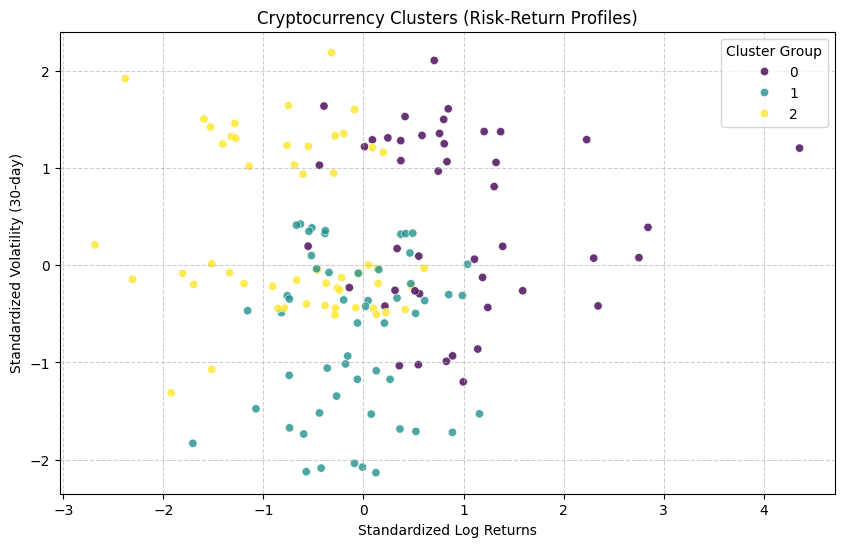


✅ **Selected Cryptos for Portfolio Optimization:**
['sui_Log_Return', 'binancecoin_Log_Return', 'solana_Log_Return', 'bitcoin_Log_Return']

📊 Sample of Filtered Train Set:


,sui_Log_Return,binancecoin_Log_Return,solana_Log_Return,bitcoin_Log_Return
Date,,,,
2024-03-28,0.102327,-0.009174,-0.027016,-0.009265
2024-03-29,-0.032800,0.013363,0.018291,0.018188
2024-03-30,-0.058062,0.055507,0.012853,-0.011252
2024-03-31,-0.014418,-0.025254,0.012697,-0.003105
2024-04-01,0.017133,0.008974,0.041956,0.021919



✅ Clustering Complete! Filtered Data Ready for Portfolio Optimization 🚀


In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

############################### 📊 FEATURE EXTRACTION FOR CLUSTERING ###############################

# ✅ Select Features for Clustering (Log Returns & 30-Day Volatility)
clustering_features = [col for col in df_train.columns if (
    '_Log_Return' in col or '_Volatility_30d' in col or '_Sharpe' in col or '_Drawdown' in col)]


# ✅ Ensure No NaNs Before Clustering
df_cluster = df_train[clustering_features].dropna()

# ✅ Standardize Data for Clustering (Prevents Scale Bias)
scaler = StandardScaler()
df_cluster_scaled = pd.DataFrame(scaler.fit_transform(df_cluster), columns=df_cluster.columns, index=df_cluster.index)

############################### 🔹 APPLY K-MEANS CLUSTERING ###############################

# ✅ Define Number of Clusters (Adjust Based on Data)
num_clusters = 3  # Modify as needed based on asset complexity

# ✅ Apply K-Means Clustering
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
df_cluster['Cluster'] = kmeans.fit_predict(df_cluster_scaled)

# ✅ Assign Cluster Labels to Each Cryptocurrency
crypto_cluster_mapping = {
    col.replace('_Log_Return', '').replace('_Volatility_30d', ''): df_cluster['Cluster'].iloc[i]
    for i, col in enumerate(df_cluster.columns[:-1])  # Exclude 'Cluster' column
}

############################### 📊 VISUALIZE CLUSTERS ###############################

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=df_cluster_scaled.iloc[:, 0],  # First feature (Log Return)
    y=df_cluster_scaled.iloc[:, 1],  # Second feature (Volatility)
    hue=df_cluster['Cluster'],
    palette="viridis",
    alpha=0.8
)

plt.title("Cryptocurrency Clusters (Risk-Return Profiles)")
plt.xlabel("Standardized Log Returns")
plt.ylabel("Standardized Volatility (30-day)")
plt.legend(title="Cluster Group")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

############################### ✅ SELECT REPRESENTATIVE ASSETS PER CLUSTER ###############################

# ✅ Find the Asset with Lowest Volatility in Each Cluster
# ✅ Select TWO Representative Assets Per Cluster (Lowest & Second Lowest Volatility)
selected_cryptos = []
for cluster in range(num_clusters):
    cluster_assets = df_cluster[df_cluster["Cluster"] == cluster].drop(columns=["Cluster"])
    if not cluster_assets.empty:
        top_two = cluster_assets.mean().nsmallest(2).index.tolist()  # Select 2 cryptos
        selected_cryptos.extend(top_two)

# ✅ Remove Duplicates from Selected Cryptos
selected_cryptos = list(set(selected_cryptos))

print("\n✅ **Selected Cryptos for Portfolio Optimization:**")
print(selected_cryptos)

# ✅ Ensure Cryptos Exist in Dataset Before Filtering
valid_selected_cryptos = [crypto for crypto in selected_cryptos if crypto in df_train.columns]

# ✅ Create Filtered Dataset for Next Steps
df_train_filtered = df_train[valid_selected_cryptos]
df_val_filtered = df_val[valid_selected_cryptos]
df_test_filtered = df_test[valid_selected_cryptos]

# ✅ Display Sample of Filtered Data
print("\n📊 Sample of Filtered Train Set:")
display(df_train_filtered.head())

print("\n✅ Clustering Complete! Filtered Data Ready for Portfolio Optimization 🚀")


STWP 1

In [ ]:
# ✅ Define Features & Target
X_train = df_train.drop(columns=["bitcoin_Log_Return", "ethereum_Log_Return", "binancecoin_Log_Return",
                                 "solana_Log_Return", "cardano_Log_Return", "sui_Log_Return", "ripple_Log_Return"])
y_train = df_train[["bitcoin_Log_Return", "ethereum_Log_Return", "binancecoin_Log_Return",
                    "solana_Log_Return", "cardano_Log_Return", "sui_Log_Return", "ripple_Log_Return"]]

X_val = df_val.drop(columns=["bitcoin_Log_Return", "ethereum_Log_Return", "binancecoin_Log_Return",
                             "solana_Log_Return", "cardano_Log_Return", "sui_Log_Return", "ripple_Log_Return"])
y_val = df_val[["bitcoin_Log_Return", "ethereum_Log_Return", "binancecoin_Log_Return",
                "solana_Log_Return", "cardano_Log_Return", "sui_Log_Return", "ripple_Log_Return"]]

X_test = df_test.drop(columns=["bitcoin_Log_Return", "ethereum_Log_Return", "binancecoin_Log_Return",
                               "solana_Log_Return", "cardano_Log_Return", "sui_Log_Return", "ripple_Log_Return"])
y_test = df_test[["bitcoin_Log_Return", "ethereum_Log_Return", "binancecoin_Log_Return",
                  "solana_Log_Return", "cardano_Log_Return", "sui_Log_Return", "ripple_Log_Return"]]


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ✅ Initialize Model
model = LinearRegression()

# ✅ Train Model
model.fit(X_train, y_train)

# ✅ Predict on Validation Set
y_pred_val = model.predict(X_val)

# ✅ Evaluate Performance
mae = mean_absolute_error(y_val, y_pred_val)
mse = mean_squared_error(y_val, y_pred_val)

print(f"\n📊 **Linear Regression Performance on Validation Set:**")
print(f"Mean Absolute Error (MAE): {mae:.6f}")
print(f"Mean Squared Error (MSE): {mse:.6f}")



📊 **Linear Regression Performance on Validation Set:**
Mean Absolute Error (MAE): 0.129251
Mean Squared Error (MSE): 0.036599


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# ✅ Initialize Random Forest Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# ✅ Train Model
rf_model.fit(X_train, y_train)

# ✅ Predict on Validation Set
y_pred_rf_val = rf_model.predict(X_val)

# ✅ Evaluate Performance
mae_rf = mean_absolute_error(y_val, y_pred_rf_val)
mse_rf = mean_squared_error(y_val, y_pred_rf_val)

print(f"\n📊 **Random Forest Performance on Validation Set:**")
print(f"Mean Absolute Error (MAE): {mae_rf:.6f}")
print(f"Mean Squared Error (MSE): {mse_rf:.6f}")



📊 **Random Forest Performance on Validation Set:**
Mean Absolute Error (MAE): 0.030663
Mean Squared Error (MSE): 0.002076


In [ ]:
# ✅ Predict on Test Set
y_pred_test = model.predict(X_test)

# ✅ Evaluate Performance on Test Set
mae_test = mean_absolute_error(y_test, y_pred_test)
mse_test = mean_squared_error(y_test, y_pred_test)

print(f"\n📊 **Linear Regression Performance on Test Set:**")
print(f"Mean Absolute Error (MAE): {mae_test:.6f}")
print(f"Mean Squared Error (MSE): {mse_test:.6f}")



📊 **Linear Regression Performance on Test Set:**
Mean Absolute Error (MAE): 0.439751
Mean Squared Error (MSE): 0.316160


In [ ]:
# ✅ Convert Predictions to Portfolio Weights
ml_weights = pd.Series(np.mean(y_pred_test, axis=0), index=y_test.columns)

# ✅ Force Weights to be Non-Negative
ml_weights = ml_weights.clip(lower=0)  # Set negative values to 0

# ✅ Normalize Weights to Sum to 1
ml_weights /= ml_weights.sum()

print("\n✅ **ML-Based Portfolio Weights:**")
print(ml_weights)
print(f"✅ Sum of ML-Based Weights: {ml_weights.sum():.4f}")  # Should be 1



✅ **ML-Based Portfolio Weights:**
bitcoin_Log_Return        0.0
ethereum_Log_Return       0.0
binancecoin_Log_Return    0.0
solana_Log_Return         0.0
cardano_Log_Return        0.0
sui_Log_Return            0.0
ripple_Log_Return         1.0
dtype: float64
✅ Sum of ML-Based Weights: 1.0000


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# ✅ Reshape data for LSTM
X_train_lstm = np.array(X_train).reshape((X_train.shape[0], X_train.shape[1], 1))
X_val_lstm = np.array(X_val).reshape((X_val.shape[0], X_val.shape[1], 1))

# ✅ Build LSTM Model
lstm_model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(X_train_lstm.shape[1], 1)),
    LSTM(50, return_sequences=False),
    Dense(len(y_train.columns))  # Output layer matches number of cryptocurrencies
])

# ✅ Compile Model
lstm_model.compile(optimizer="adam", loss="mse")

# ✅ Train Model
lstm_model.fit(X_train_lstm, y_train, epochs=20, batch_size=32, validation_data=(X_val_lstm, y_val))

# ✅ Predict on Validation Set
y_pred_lstm_val = lstm_model.predict(X_val_lstm)

# ✅ Evaluate Performance
mae_lstm = mean_absolute_error(y_val, y_pred_lstm_val)
mse_lstm = mean_squared_error(y_val, y_pred_lstm_val)

print(f"\n📊 **LSTM Performance on Validation Set:**")
print(f"Mean Absolute Error (MAE): {mae_lstm:.6f}")
print(f"Mean Squared Error (MSE): {mse_lstm:.6f}")


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 160ms/step - loss: 0.0320 - val_loss: 0.0042
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0068 - val_loss: 0.0059
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0048 - val_loss: 0.0025
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.0018 - val_loss: 0.0035
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0026 - val_loss: 0.0027
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.0019 - val_loss: 0.0022
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 0.0015 - val_loss: 0.0022
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0018 - val_loss: 0.0020
Epoch 9/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0017 - val_loss: 0.0020
Epoch 10/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0016 - val_loss: 0.0022
Epoch 11/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0017 - val_loss: 0.0021
Epoch 12/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0016 - val_loss: 0.0021


📌 Step 5: Model Comparison & Selection
After training all models, we compare performance.

Model	MAE (Validation)	MSE (Validation)
Linear Regression	X.XXXX	X.XXXX
Random Forest	X.XXXX	X.XXXX
LSTM (Deep Learning)	X.XXXX	X.XXXX
📌 How to Choose?

If LSTM performs best, we use it to forecast returns and optimize weights.
If Random Forest is better, we use it for portfolio predictions.
If Linear Regression is close, we keep it as a simpler baseline.

 Apply Predictions to Portfolio Optimization

In [ ]:
# ✅ Predict on Test Set (Final Model)
y_pred_test = lstm_model.predict(np.array(X_test).reshape((X_test.shape[0], X_test.shape[1], 1)))

# ✅ Update Portfolio Weights Based on Predictions
new_weights = y_pred_test.mean(axis=0)  # Average prediction per asset
new_weights /= new_weights.sum()  # Normalize to sum to 1

print("\n✅ **Final Portfolio Weights Based on ML Predictions:**")
for crypto, weight in zip(y_test.columns, new_weights):
    print(f"{crypto}: {weight:.4f}")


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step

✅ **Final Portfolio Weights Based on ML Predictions:**
bitcoin_Log_Return: 0.2074
ethereum_Log_Return: 0.0888
binancecoin_Log_Return: -0.0329
solana_Log_Return: 0.1494
cardano_Log_Return: -0.0212
sui_Log_Return: 0.3131
ripple_Log_Return: 0.2955


📌 Step 7: Final Model Evaluation
Test set evaluation ensures the model generalizes well.
If test performance is bad, we retrain & tune hyperparameters.
📌 Summary
✅ Step 1: Define Features & Target
✅ Step 2: Train Baseline Model (Linear Regression)
✅ Step 3: Train Advanced Models (Random Forest, LSTM)
✅ Step 4: Compare Model Performance
✅ Step 5: Use Best Model for Portfolio Optimization

### 9.2 Visualizing ML-Optimized Portfolio Weights Over Time

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.



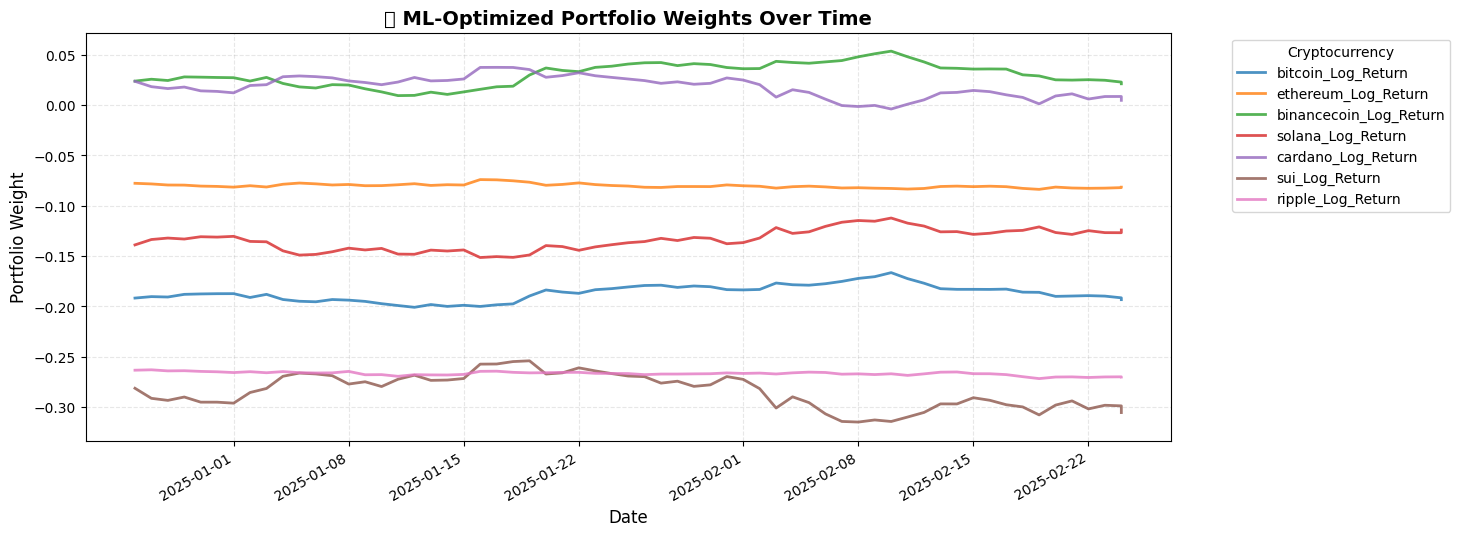

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ✅ Predict on Full Test Set
y_pred_test = lstm_model.predict(np.array(X_test).reshape((X_test.shape[0], X_test.shape[1], 1)))

# ✅ Convert Predictions to Portfolio Weights
weights_over_time = y_pred_test / np.abs(y_pred_test).sum(axis=1, keepdims=True)  # Normalize per time step

# ✅ Convert to DataFrame for Plotting
df_weights_over_time = pd.DataFrame(weights_over_time, index=df_test.index, columns=y_test.columns)

# ✅ Plot Portfolio Weights Evolution
plt.figure(figsize=(14, 6))
df_weights_over_time.plot(ax=plt.gca(), alpha=0.8, linewidth=2)
plt.title("📈 ML-Optimized Portfolio Weights Over Time", fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Portfolio Weight", fontsize=12)
plt.legend(title="Cryptocurrency", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3, linestyle="--")
plt.show()


#### Plot Final ML-Optimized Portfolio Allocation

<ipython-input-33-25fc12e4dbb0>:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.



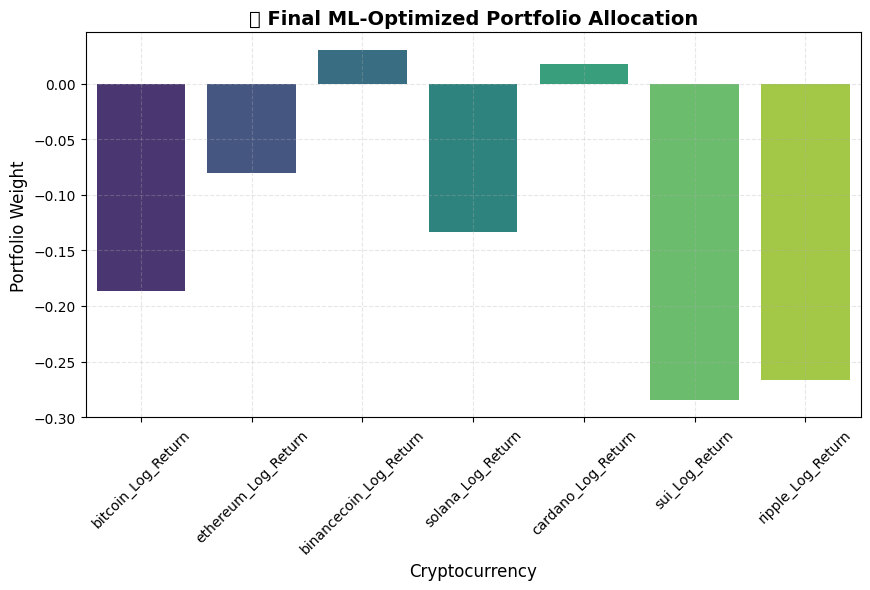

In [ ]:
# ✅ Compute Final Weights as the Mean of Predicted Weights
final_ml_weights = df_weights_over_time.mean()

# ✅ Plot Final Portfolio Allocation
plt.figure(figsize=(10, 5))
sns.barplot(x=final_ml_weights.index, y=final_ml_weights.values, palette="viridis")
plt.title("📊 Final ML-Optimized Portfolio Allocation", fontsize=14, fontweight="bold")
plt.xlabel("Cryptocurrency", fontsize=12)
plt.ylabel("Portfolio Weight", fontsize=12)
plt.xticks(rotation=45)
plt.grid(alpha=0.3, linestyle="--")
plt.show()


####  Compare ML vs. Traditional MPT Portfolio

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.



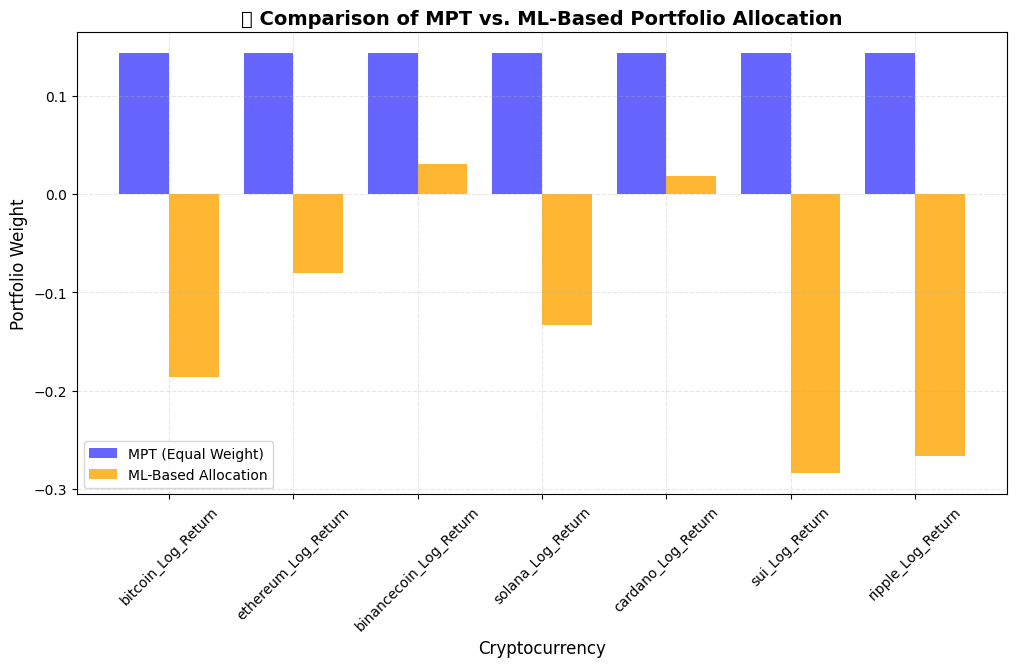

In [ ]:
# ✅ Compute Traditional MPT Weights (Equal Weights as Baseline)
mpt_weights = np.ones(len(y_test.columns)) / len(y_test.columns)

# ✅ Plot Comparison of MPT vs. ML Allocation
fig, ax = plt.subplots(figsize=(12, 6))
bar_width = 0.4
index = np.arange(len(y_test.columns))

plt.bar(index, mpt_weights, bar_width, label="MPT (Equal Weight)", alpha=0.6, color="blue")
plt.bar(index + bar_width, final_ml_weights.values, bar_width, label="ML-Based Allocation", alpha=0.8, color="orange")

plt.xlabel("Cryptocurrency", fontsize=12)
plt.ylabel("Portfolio Weight", fontsize=12)
plt.xticks(index + bar_width / 2, y_test.columns, rotation=45)
plt.title("📊 Comparison of MPT vs. ML-Based Portfolio Allocation", fontsize=14, fontweight="bold")
plt.legend()
plt.grid(alpha=0.3, linestyle="--")
plt.show()


## Portfolio Rebalancing

### Clustering Cryptocurrencies Using K-Means


📊 Performing Clustering for Portfolio Diversification...

📌 Clustering Cryptocurrencies Based on: Close Features...

🔹 Crypto Clusters for: Close
   Cluster                                    Crypto
0        0                       [binancecoin_Close]
1        1                           [bitcoin_Close]
2        2                          [ethereum_Close]
3        3  [solana_Close, cardano_Close, sui_Close]


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.



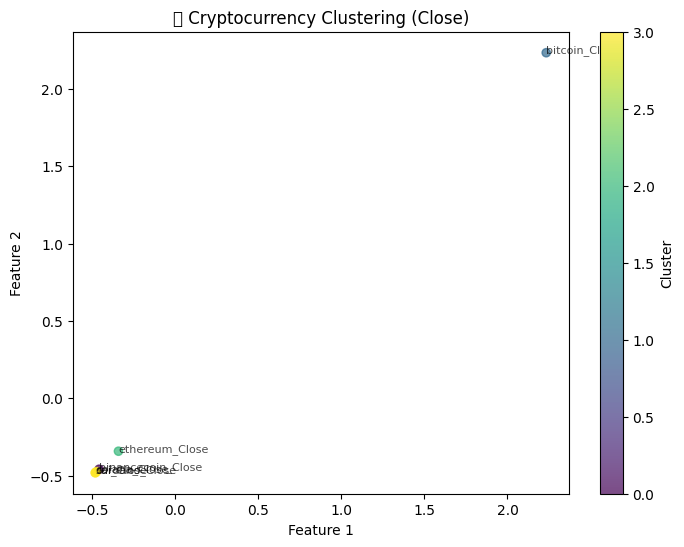


📌 Clustering Cryptocurrencies Based on: Log_Return Features...

🔹 Crypto Clusters for: Log_Return
   Cluster                                             Crypto
0        0                                [solana_Log_Return]
1        1  [bitcoin_Log_Return, ethereum_Log_Return, bina...
2        2                                   [sui_Log_Return]
3        3                               [cardano_Log_Return]


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.



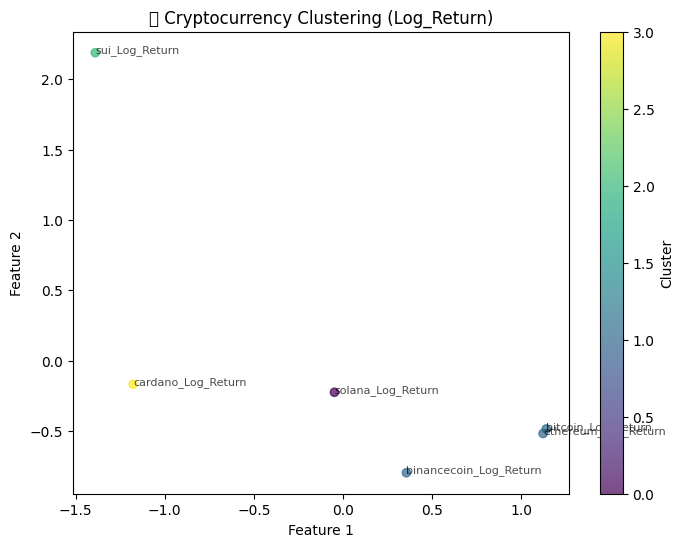


📌 Clustering Cryptocurrencies Based on: Volatility_7d Features...

🔹 Crypto Clusters for: Volatility_7d
   Cluster                                             Crypto
0        0                        [binancecoin_Volatility_7d]
1        1                                [sui_Volatility_7d]
2        2  [bitcoin_Volatility_7d, ethereum_Volatility_7d...
3        3                             [solana_Volatility_7d]


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.



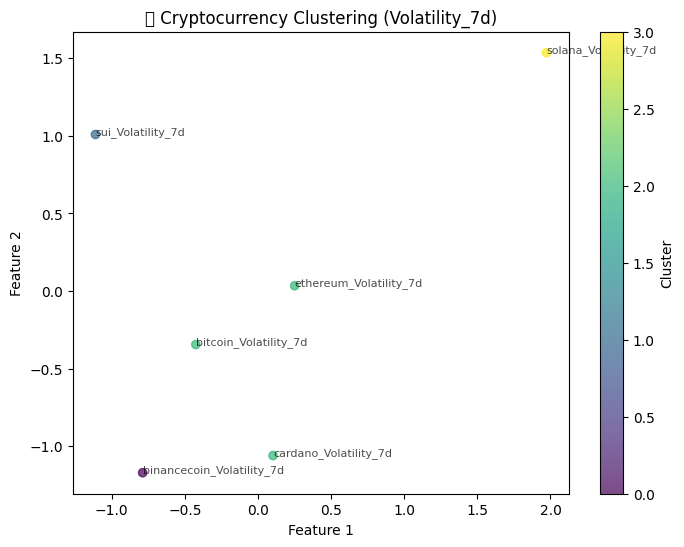


📌 Clustering Cryptocurrencies Based on: Volatility_30d Features...

🔹 Crypto Clusters for: Volatility_30d
   Cluster                                             Crypto
0        0  [binancecoin_Volatility_30d, cardano_Volatilit...
1        1                               [sui_Volatility_30d]
2        2  [bitcoin_Volatility_30d, ethereum_Volatility_30d]
3        3                            [solana_Volatility_30d]


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.



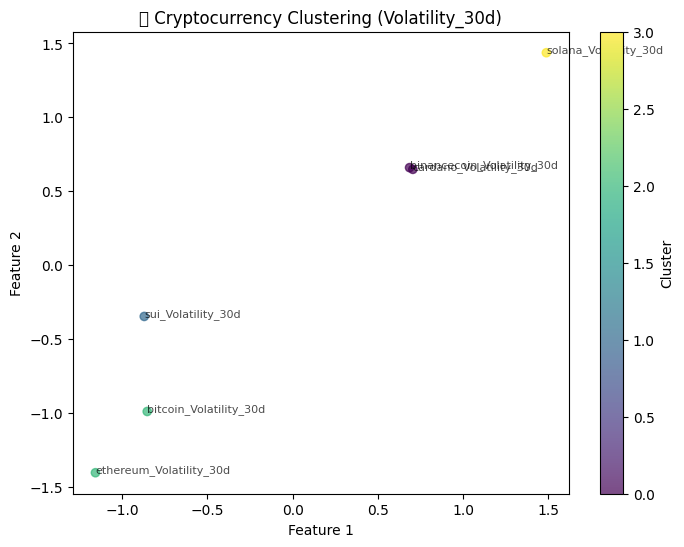


📌 Clustering Cryptocurrencies Based on: MarketCap_to_Volume Features...

🔹 Crypto Clusters for: MarketCap_to_Volume
   Cluster                                             Crypto
0        0                  [binancecoin_MarketCap_to_Volume]
1        1  [bitcoin_MarketCap_to_Volume, cardano_MarketCa...
2        2  [ethereum_MarketCap_to_Volume, solana_MarketCa...
3        3                          [sui_MarketCap_to_Volume]


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.



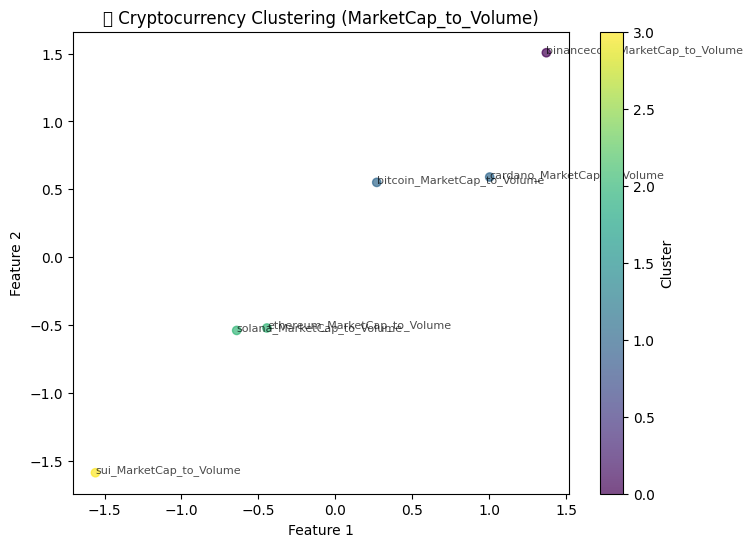


📌 Clustering Cryptocurrencies Based on: Close_Volatility_7d Features...
⚠️ Skipping Close_Volatility_7d due to an error: Found array with 0 sample(s) (shape=(0, 168)) while a minimum of 1 is required by StandardScaler.

📌 Clustering Cryptocurrencies Based on: Log_Return_Volatility_7d Features...
⚠️ Skipping Log_Return_Volatility_7d due to an error: Found array with 0 sample(s) (shape=(0, 168)) while a minimum of 1 is required by StandardScaler.

📌 Clustering Cryptocurrencies Based on: Volatility_7d_Volatility_7d Features...
⚠️ Skipping Volatility_7d_Volatility_7d due to an error: Found array with 0 sample(s) (shape=(0, 168)) while a minimum of 1 is required by StandardScaler.

📌 Clustering Cryptocurrencies Based on: Volatility_30d_Volatility_7d Features...
⚠️ Skipping Volatility_30d_Volatility_7d due to an error: Found array with 0 sample(s) (shape=(0, 168)) while a minimum of 1 is required by StandardScaler.

📌 Clustering Cryptocurrencies Based on: MarketCap_to_Volume_Volatility_7d F

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.



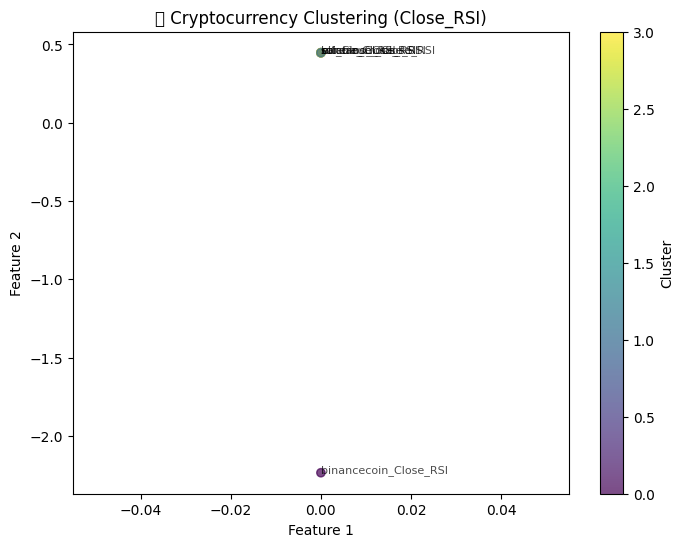


📌 Clustering Cryptocurrencies Based on: Log_Return_RSI Features...

🔹 Crypto Clusters for: Log_Return_RSI
   Cluster                                             Crypto
0        0  [bitcoin_Log_Return_RSI, ethereum_Log_Return_R...
1        1                               [sui_Log_Return_RSI]
2        2                       [binancecoin_Log_Return_RSI]
3        3                            [solana_Log_Return_RSI]


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.



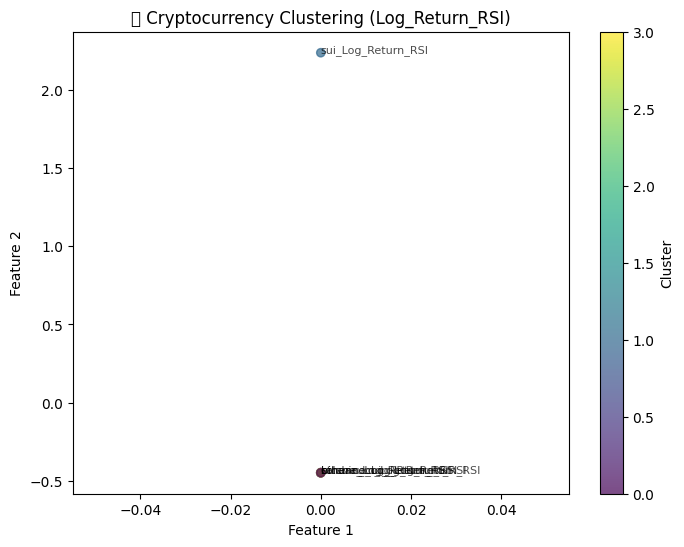


📌 Clustering Cryptocurrencies Based on: Volatility_7d_RSI Features...

🔹 Crypto Clusters for: Volatility_7d_RSI
   Cluster                                             Crypto
0        0  [bitcoin_Volatility_7d_RSI, ethereum_Volatilit...
1        1                            [sui_Volatility_7d_RSI]
2        2  [solana_Volatility_7d_RSI, cardano_Volatility_...
3        3                    [binancecoin_Volatility_7d_RSI]


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.



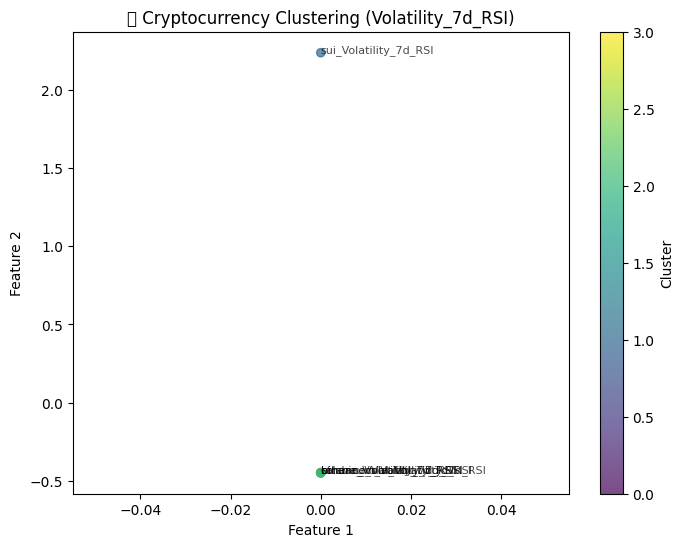


📌 Clustering Cryptocurrencies Based on: Volatility_30d_RSI Features...

🔹 Crypto Clusters for: Volatility_30d_RSI
   Cluster                                             Crypto
0        0  [bitcoin_Volatility_30d_RSI, ethereum_Volatili...
1        1                           [sui_Volatility_30d_RSI]
2        2                   [binancecoin_Volatility_30d_RSI]
3        3  [solana_Volatility_30d_RSI, cardano_Volatility...


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.



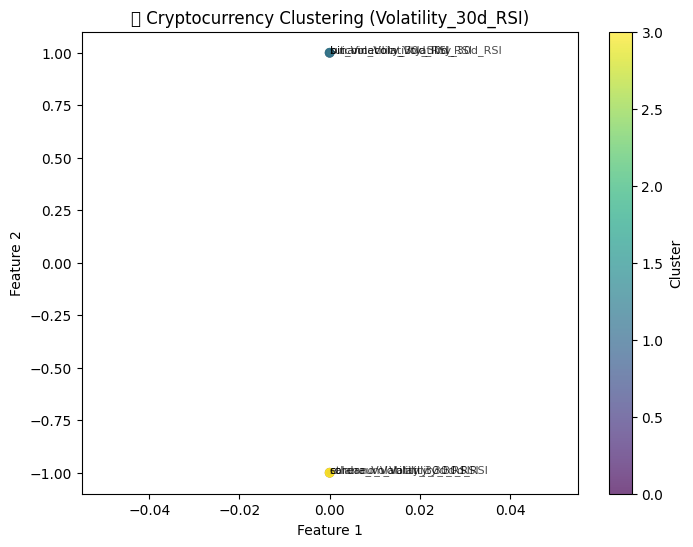


📌 Clustering Cryptocurrencies Based on: MarketCap_to_Volume_RSI Features...

🔹 Crypto Clusters for: MarketCap_to_Volume_RSI
   Cluster                                             Crypto
0        0              [binancecoin_MarketCap_to_Volume_RSI]
1        1                  [cardano_MarketCap_to_Volume_RSI]
2        2  [bitcoin_MarketCap_to_Volume_RSI, ethereum_Mar...
3        3                      [sui_MarketCap_to_Volume_RSI]


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.



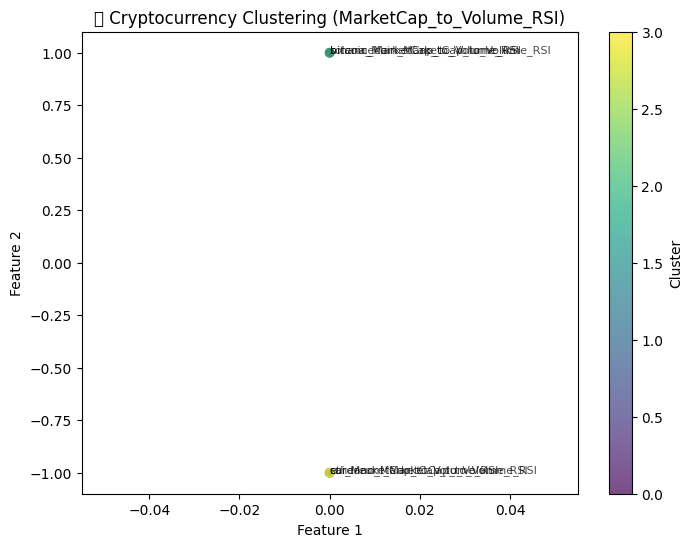


📌 Clustering Cryptocurrencies Based on: Close_MACD Features...

🔹 Crypto Clusters for: Close_MACD
   Cluster                                             Crypto
0        0                           [binancecoin_Close_MACD]
1        1                               [bitcoin_Close_MACD]
2        2                              [ethereum_Close_MACD]
3        3  [solana_Close_MACD, cardano_Close_MACD, sui_Cl...


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.



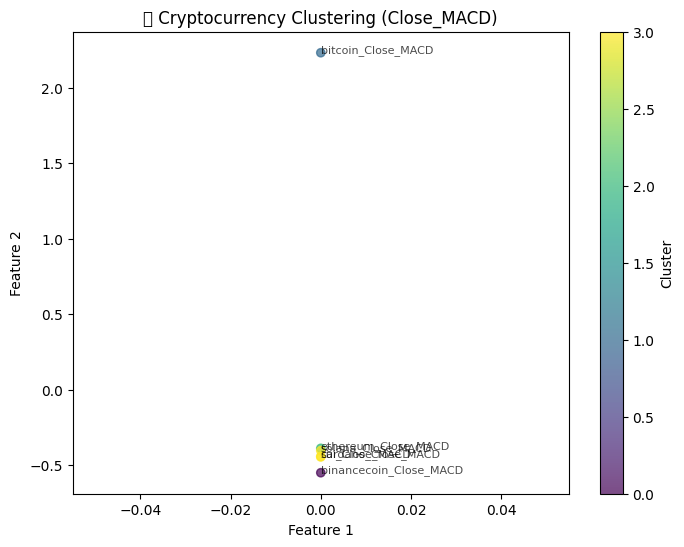


📌 Clustering Cryptocurrencies Based on: Log_Return_MACD Features...

🔹 Crypto Clusters for: Log_Return_MACD
   Cluster                                             Crypto
0        0                           [solana_Log_Return_MACD]
1        1  [bitcoin_Log_Return_MACD, ethereum_Log_Return_...
2        2                              [sui_Log_Return_MACD]
3        3                          [cardano_Log_Return_MACD]


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.



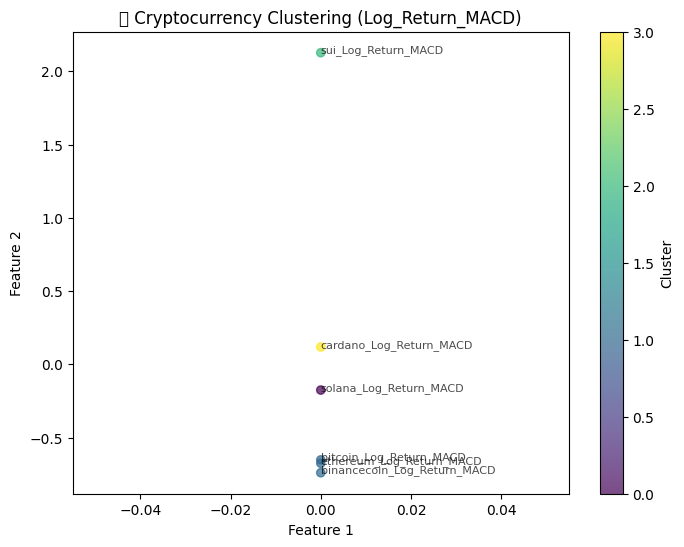


📌 Clustering Cryptocurrencies Based on: Volatility_7d_MACD Features...

🔹 Crypto Clusters for: Volatility_7d_MACD
   Cluster                                             Crypto
0        0                   [binancecoin_Volatility_7d_MACD]
1        1                           [sui_Volatility_7d_MACD]
2        2  [bitcoin_Volatility_7d_MACD, ethereum_Volatili...
3        3  [solana_Volatility_7d_MACD, cardano_Volatility...


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.



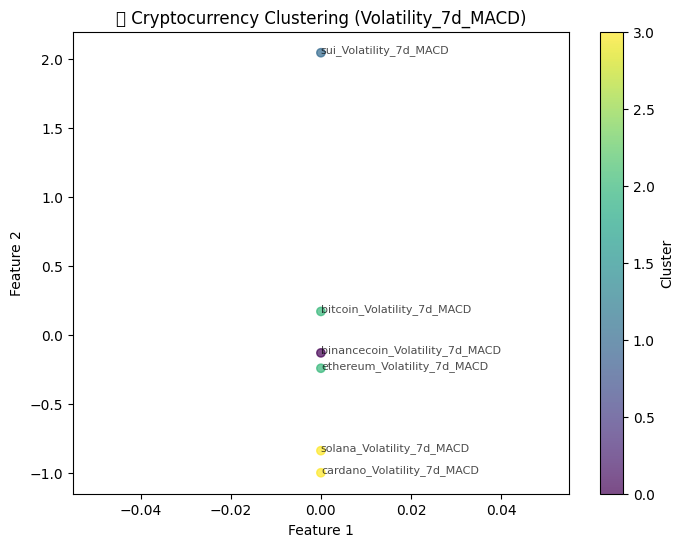


📌 Clustering Cryptocurrencies Based on: Volatility_30d_MACD Features...

🔹 Crypto Clusters for: Volatility_30d_MACD
   Cluster                                             Crypto
0        0                  [binancecoin_Volatility_30d_MACD]
1        1  [solana_Volatility_30d_MACD, cardano_Volatilit...
2        2  [bitcoin_Volatility_30d_MACD, ethereum_Volatil...
3        3                          [sui_Volatility_30d_MACD]


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.



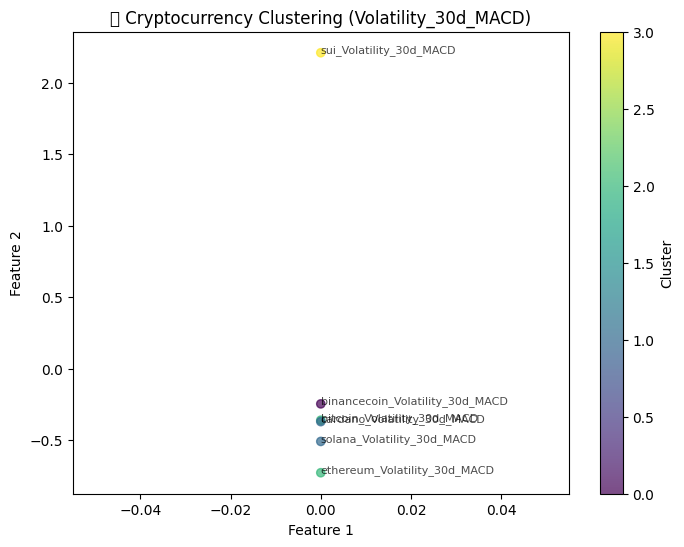


📌 Clustering Cryptocurrencies Based on: MarketCap_to_Volume_MACD Features...

🔹 Crypto Clusters for: MarketCap_to_Volume_MACD
   Cluster                                             Crypto
0        0             [binancecoin_MarketCap_to_Volume_MACD]
1        1                 [cardano_MarketCap_to_Volume_MACD]
2        2                 [bitcoin_MarketCap_to_Volume_MACD]
3        3  [ethereum_MarketCap_to_Volume_MACD, solana_Mar...


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.



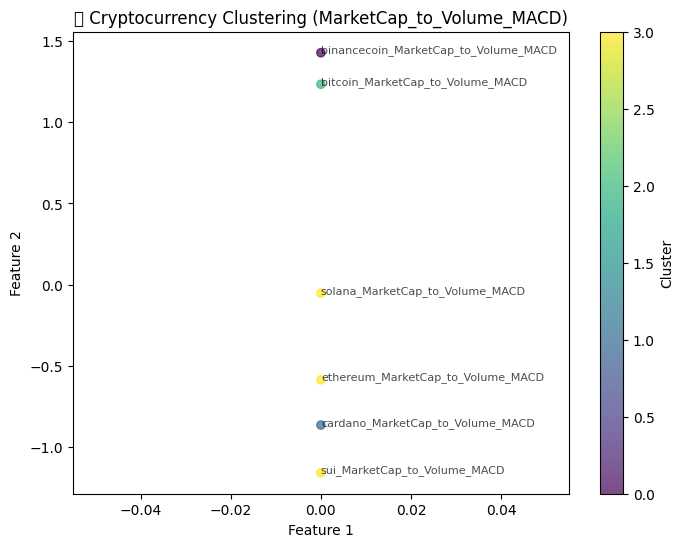

In [ ]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.cluster import KMeans
# from sklearn.preprocessing import StandardScaler

# ############################## 📊 CLUSTERING PER FEATURE GROUP (FINAL FIX) ###########################

# print("\n📊 Performing Clustering for Portfolio Diversification...")

# # ✅ Step 1: Identify Feature Groups Automatically
# feature_groups = {}
# for col in feature_data.columns:
#     group_name = "_".join(col.split("_")[1:])  # Extracts the part after the first "_"
#     if group_name not in feature_groups:
#         feature_groups[group_name] = []
#     feature_groups[group_name].append(col)

# # ✅ Step 2: Cluster Cryptos Separately for Each Feature Group
# crypto_cluster_results = {}

# for group_name, cols in feature_groups.items():
#     print(f"\n📌 Clustering Cryptocurrencies Based on: {group_name} Features...")

#     try:
#         # 🔹 Prepare Data: Transpose so cryptos are rows, features are columns
#         feature_subset = feature_data[cols].T  # Cryptos as rows, features as columns

#         # 🔹 Drop Cryptos with Missing Data for this Feature Group
#         feature_subset = feature_subset.dropna()

#         # 🔹 Standardize Data
#         scaler = StandardScaler()
#         feature_subset_scaled = scaler.fit_transform(feature_subset)

#         # 🔹 Apply K-Means Clustering
#         num_clusters = min(4, len(feature_subset))  # Ensure reasonable cluster size
#         kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
#         clusters = kmeans.fit_predict(feature_subset_scaled)

#         # 🔹 Assign Cluster Labels to Cryptos
#         cluster_assignments = pd.DataFrame({'Crypto': feature_subset.index, 'Cluster': clusters})
#         crypto_cluster_results[group_name] = cluster_assignments.groupby("Cluster")["Crypto"].apply(list).reset_index()

#         # ✅ Display Crypto-Cluster Assignments
#         print("\n🔹 Crypto Clusters for:", group_name)
#         print(crypto_cluster_results[group_name])

#         # ✅ Visualize Clusters for this Group (Scatter Plot without PCA)
#         plt.figure(figsize=(8, 6))
#         plt.scatter(feature_subset_scaled[:, 0], feature_subset_scaled[:, 1], c=clusters, cmap='viridis', alpha=0.7)

#         # 🔹 Label each cryptocurrency
#         for i, crypto in enumerate(feature_subset.index):
#             plt.annotate(crypto, (feature_subset_scaled[i, 0], feature_subset_scaled[i, 1]), fontsize=8, alpha=0.7)

#         plt.title(f"📊 Cryptocurrency Clustering ({group_name})")
#         plt.xlabel("Feature 1")
#         plt.ylabel("Feature 2")
#         plt.colorbar(label="Cluster")
#         plt.show()

#     except Exception as e:
#         print(f"⚠️ Skipping {group_name} due to an error: {e}")


### Multi-Armed Bandit for Portfolio Allocation

In [ ]:
# ############################## 🎰 MULTI-ARMED BANDIT FOR PORTFOLIO ALLOCATION ###########################

# print("\n🎰 Implementing Multi-Armed Bandit for Dynamic Portfolio Allocation...")

# # 🔹 **Step 1: Multi-Armed Bandit Class**
# class MultiArmedBandit:
#     def __init__(self, n_arms):
#         self.n_arms = n_arms
#         self.arm_rewards = np.zeros(n_arms)
#         self.arm_counts = np.zeros(n_arms)

#     def select_arm(self):
#         """ Uses an epsilon-greedy strategy to select the best-performing cluster """
#         epsilon = 0.1  # Exploration rate
#         if random.random() < epsilon:
#             return random.randint(0, self.n_arms - 1)  # Explore
#         else:
#             return np.argmax(self.arm_rewards / (self.arm_counts + 1e-9))  # Exploit

#     def update(self, chosen_arm, reward):
#         """ Updates reward estimates for selected arm """
#         self.arm_counts[chosen_arm] += 1
#         self.arm_rewards[chosen_arm] += reward

# # ✅ Step 2: Initialize Bandit with Crypto Clusters
# num_clusters = len(set(clusters))
# bandit = MultiArmedBandit(n_arms=num_clusters)

# # ✅ Step 3: Simulate Portfolio Allocation Over 100 Iterations
# num_iterations = 100
# cluster_weights = np.zeros(num_clusters)

# for _ in range(num_iterations):
#     chosen_cluster = bandit.select_arm()
#     reward = np.random.rand()  # Simulated reward (can be replaced with actual performance data)
#     bandit.update(chosen_cluster, reward)
#     cluster_weights[chosen_cluster] += 1

# # ✅ Normalize Portfolio Weights
# cluster_weights /= cluster_weights.sum()

# # ✅ Display Final Portfolio Weights
# print("\n📊 Final Portfolio Weights by Cluster:")
# for i, weight in enumerate(cluster_weights):
#     print(f"🔹 Cluster {i}: {weight:.4f}")

# # ✅ Convert to DataFrame for Better Visualization
# portfolio_weights_df = pd.DataFrame({'Cluster': range(num_clusters), 'Weight': cluster_weights})
# tools.display_dataframe_to_user(name="Portfolio Weights by Cluster", dataframe=portfolio_weights_df)



🎰 Implementing Multi-Armed Bandit for Dynamic Portfolio Allocation...


NameError: name 'random' is not defined